# MIMIC-AF — Conditional Flow Matching (OT-CFM)

| § | Content |
|---|----------|
| 0 | Setup, constants, paths |
| 1 | Subject catalogue (CSV) |
| 2 | IBI feature extraction |
| 3 | Subject-level split + normalisation |
| 4 | Dataset & DataLoader |
| 5 | Model: 1D U-Net Conditional Flow Matching |
| 6 | Training |
| 7 | Guidance scale sweep + visual generation |
| 8 | Spectral evaluation (guidance sweep, LSD, PSD) |
| 8b| NN Morphological Metrics (PRD + Pearson) |
| 8b-v2 | Morphological Metrics (PRD + Pearson) — paired |
| 8c| Local density of conditioning pairs |
| 9 | Physiological consistency (HR, IBI_mean, IBI_std, RMSSD) |
| 9 | NN Conditioning fidelity — MAE HR and IBI_std ratio |
| 9b | Conditioning fidelity — paired |
| 10 | Statistical validation (Wasserstein, MMD, t-SNE) |
| 10 |NN DTW  |
| 11 | Functional validation — Clf1D (TRTR/TSTR/ClfB) |
| 12 | In-domain ClfUNetGAN|
| FV3-A Cross-domain | VitalDB |
| Part B Cross-domain | MIMIC-III |
| Part C Cross-domain | Zenodo V2 |
| Part D | Data Scarcity — ClfUNetGAN and Clf1D |

## §0 — Setup

In [36]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q',
                           '--upgrade-strategy', 'only-if-needed'])

install('neurokit2')


In [37]:
import os, glob, warnings, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, find_peaks
from scipy.stats import wasserstein_distance
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, precision_score, f1_score
from sklearn.preprocessing import StandardScaler
import neurokit2 as nk
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── AMP ────────────────────────────────────────────────────────────────────────
USE_AMP = torch.cuda.is_available()
scaler  = torch.cuda.amp.GradScaler(
    enabled=USE_AMP, init_scale=128,
    growth_factor=2.0, backoff_factor=0.5, growth_interval=1000)
torch.backends.cudnn.benchmark = True
print(f"AMP    : {'float16 (init_scale=128)' if USE_AMP else 'float32'}")

# ── Paths ──────────────────────────────────────────────────────────────────────
# Adjust to your Kaggle dataset path
MIMIC_AF_DIR = '/kaggle/input/datasets/raditya0/mimic-perform-iii-af-and-non-af-dataset'
WORK_DIR     = '/kaggle/working'
IBI_SESSION  = os.path.join(WORK_DIR, 'ibi_session_mimic_af.csv')
CKPT_PATH    = os.path.join(WORK_DIR, 'best_model_mimic_af_cfm_b2.pt')

# ── Signal constants ───────────────────────────────────────────────────────────
FS      = 125
WIN_SEC = 10
WIN_LEN = FS * WIN_SEC       # 1250 samples per 10s window
PAD_LEN = (256 - WIN_LEN % 256) % 256   # 30 → padded to 1280

# ── Pipeline constants ─────────────────────────────────────────────────────────
# CAP: max windows per subject per class.
# Each 20-min recording → 120 non-overlapping 10s windows.
# CAP=120 means no actual capping (all windows kept).
# Lower if memory is tight.
CAP          = 300
BATCH_SIZE   = 64
EPOCHS       = 70
LR           = 1e-4
BASE_CH      = 64
T_DIM        = 256
COND_DIM     = 128
RAW_COND_DIM = 4     # IBI_mean, IBI_std, RMSSD, rhythm_sign (AF=+1, SR=-1)
ODE_STEPS    = 100
CFG_DROP     = 0.10
IBI_MIN      = 0.3   # seconds — physiological filter
IBI_MAX      = 2.0

print(f"WIN_LEN={WIN_LEN}  PAD={PAD_LEN} → {WIN_LEN+PAD_LEN} internally")
print(f"CAP={CAP}  EPOCHS={EPOCHS}  BATCH={BATCH_SIZE}  BASE_CH={BASE_CH}")
print(f"RAW_COND_DIM={RAW_COND_DIM}  (IBI_mean, IBI_std, RMSSD, rhythm_label)")


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
AMP    : float16 (init_scale=128)
WIN_LEN=1250  PAD=30 → 1280 internally
CAP=300  EPOCHS=70  BATCH=64  BASE_CH=64
RAW_COND_DIM=4  (IBI_mean, IBI_std, RMSSD, rhythm_label)


## §1 — Subject Catalogue
Build the window-level dataframe from filename conventions.
`mimic_perform_af_NNN_data.csv` → rhythm = AF
`mimic_perform_non_af_NNN_data.csv` → rhythm = SR
Subject `non_af_014` excluded (quasi-flat PPG signal, identified during EDA).
Each 20-min recording (150,000 samples @ 125 Hz) is sliced into
120 non-overlapping 10s windows (WIN_LEN=1250 each).


In [38]:
# ── Subjects to exclude ────────────────────────────────────────────────────────
EXCLUDED = {'mimic_perform_non_af_014'}   # quasi-flat signal

af_csvs  = sorted(glob.glob(os.path.join(MIMIC_AF_DIR, 'af',     '*_data.csv')))
sr_csvs  = sorted(glob.glob(os.path.join(MIMIC_AF_DIR, 'non-af', '*_data.csv')))

# Build window-level catalogue
rows = []
for rhythm, csv_list in [('AF', af_csvs), ('SR', sr_csvs)]:
    for fpath in csv_list:
        sid = os.path.basename(fpath).replace('_data.csv', '')
        if sid in EXCLUDED:
            continue
        # Each file has 150001 samples; we take 120 complete 10s windows
        STEP = WIN_LEN // 2   # = 625, 50% overlap
        n_windows = (150000 - WIN_LEN) // STEP + 1   # ≈ 238 janelas
        for w in range(n_windows):
            rows.append({
                'csv_path':     fpath,
                'subject_id':   sid,
                'event_rhythm': rhythm,
                'start_sample': w * STEP,   # ← passo de 625, não 1250
                'window_idx':   w,
            })

df = pd.DataFrame(rows)
print(f"Subjects: {df['subject_id'].nunique()}  "
      f"(AF={df[df['event_rhythm']=='AF']['subject_id'].nunique()}, "
      f"SR={df[df['event_rhythm']=='SR']['subject_id'].nunique()})")
print(f"Total windows: {len(df):,}  ({len(df)*WIN_SEC/3600:.1f}h)")
print(df['event_rhythm'].value_counts().to_string())

# ── 70/15/15 subject-level split ──────────────────────────────────────────────
all_sids = df['subject_id'].unique()
af_sids  = set(df[df['event_rhythm']=='AF']['subject_id'].unique())
has_af   = [s for s in all_sids if s in af_sids]
no_af    = [s for s in all_sids if s not in af_sids]

def split_70_15_15(lst, seed=SEED):
    tr, tmp = train_test_split(lst, test_size=0.30, random_state=seed)
    vl, te  = train_test_split(tmp, test_size=0.50, random_state=seed)
    return tr, vl, te

af_tr, af_vl, af_te = split_70_15_15(has_af)
sr_tr, sr_vl, sr_te = split_70_15_15(no_af)
TRAIN_SIDS = set(af_tr) | set(sr_tr)
VAL_SIDS   = set(af_vl) | set(sr_vl)
TEST_SIDS  = set(af_te) | set(sr_te)

assert not (TRAIN_SIDS & VAL_SIDS) and not (TRAIN_SIDS & TEST_SIDS)
print(f"\n✓ Leakage-free split: Train={len(TRAIN_SIDS)} | Val={len(VAL_SIDS)} | Test={len(TEST_SIDS)}")

# ── Cap windows per subject (no actual capping at CAP=120, all windows kept) ──
def cap_segs(df_fold, cap=CAP, seed=SEED):
    out = []
    for (_, _), grp in df_fold.groupby(['subject_id', 'event_rhythm']):
        out.append(grp.sample(min(cap, len(grp)), random_state=seed))
    return pd.concat(out).reset_index(drop=True)

df_capped = pd.concat([
    cap_segs(df[df['subject_id'].isin(TRAIN_SIDS)]),
    cap_segs(df[df['subject_id'].isin(VAL_SIDS)]),
    cap_segs(df[df['subject_id'].isin(TEST_SIDS)]),
]).reset_index(drop=True)

print(f"\nAfter cap={CAP}: {len(df_capped):,} windows")
print(df_capped['event_rhythm'].value_counts().to_string())
print(f"Note: {len(df_capped):,} × {WIN_SEC}s = {len(df_capped)*WIN_SEC/3600:.1f}h of labelled signal")


Subjects: 34  (AF=19, SR=15)
Total windows: 8,126  (22.6h)
event_rhythm
AF    4541
SR    3585

✓ Leakage-free split: Train=23 | Val=5 | Test=6

After cap=300: 8,126 windows
event_rhythm
AF    4541
SR    3585
Note: 8,126 × 10s = 22.6h of labelled signal


## §2 — IBI Feature Extraction
IBI_mean, IBI_std and RMSSD extracted from the ECG column via NeuroKit2 R-peak
detection — identical algorithm to MIMIC-III-Ext-PPG v5, adapted from WFDB to
CSV column format.

Note: the MIMIC-III metadata fallback (`meta_ibi`) is not needed here because
the ECG column is always present. Windows where NeuroKit2 fails to detect
sufficient R-peaks are dropped by the physiological filter below.


In [39]:
# ── In-memory cache of CSV arrays ─────────────────────────────────────────────
# Reading the same CSV file repeatedly for each window would be very slow.
# Cache PPG and ECG arrays by csv_path for fast slice access.
_csv_cache = {}   # {csv_path: {'PPG': np.array, 'ECG': np.array}}

def _load_csv(csv_path):
    if csv_path not in _csv_cache:
        d = pd.read_csv(csv_path)
        _csv_cache[csv_path] = {
            'PPG': d['PPG'].values.astype(np.float32),
            'ECG': d['ECG'].values.astype(np.float32),
        }
    return _csv_cache[csv_path]


def ecg_ibi_10s_csv(csv_path, start_sample):
    """
    Extract IBI_mean, IBI_std and RMSSD from a 10s slice of the ECG column.
    Identical to ecg_ibi_10s() in MIMIC-III-Ext-PPG v5 but reads from CSV
    instead of a WFDB file.
    """
    end = start_sample + WIN_LEN
    try:
        ecg = _load_csv(csv_path)['ECG'][start_sample:end]
        if len(ecg) < WIN_LEN or np.isnan(ecg).any() or np.all(ecg == ecg[0]):
            return None, None, None
        _, info = nk.ecg_peaks(ecg, sampling_rate=FS, method='neurokit')
        rr = np.diff(info['ECG_R_Peaks']) / FS
        rr = rr[(rr >= IBI_MIN) & (rr <= IBI_MAX)]
        if len(rr) < 2:
            return None, None, None
        rmssd = float(np.sqrt(np.mean(np.diff(rr) ** 2)))
        return float(np.mean(rr)), float(np.std(rr)), rmssd
    except:
        return None, None, None


# ── Compute or load within-session IBI cache ───────────────────────────────────
_cache_ok = os.path.exists(IBI_SESSION)
if _cache_ok:
    _peek = pd.read_csv(IBI_SESSION, nrows=1)
    if 'RMSSD' not in _peek.columns:
        print(f"Cache predates RMSSD (B2) — recomputing.")
        os.remove(IBI_SESSION)
        _cache_ok = False

if _cache_ok:
    print(f"Session cache found: {IBI_SESSION}")
    df_ibi = pd.read_csv(IBI_SESSION)
    # Filter to match current df_capped
    key_cache  = df_ibi['csv_path'] + '_' + df_ibi['start_sample'].astype(str)
    key_capped = df_capped['csv_path'] + '_' + df_capped['start_sample'].astype(str)
    df_ibi = df_ibi[key_cache.isin(set(key_capped))].copy()
    print(f"Loaded and filtered: {len(df_ibi):,} records")
else:
    print(f"Computing IBI for {len(df_capped):,} windows ({WIN_SEC}s each)...")
    rows_ibi, t0 = [], time.time()
    for i, (_, row) in enumerate(df_capped.iterrows()):
        if i % 1000 == 0 and i > 0:
            eta = (time.time()-t0) / i * (len(df_capped)-i)
            print(f"  {i}/{len(df_capped)}  ETA: {eta/60:.1f} min")
        im, is_, irm = ecg_ibi_10s_csv(row['csv_path'], int(row['start_sample']))
        rows_ibi.append({
            'csv_path':     row['csv_path'],
            'start_sample': int(row['start_sample']),
            'subject_id':   row['subject_id'],
            'event_rhythm': row['event_rhythm'],
            'window_idx':   int(row['window_idx']),
            'IBI_mean':     im,
            'IBI_std':      is_,
            'RMSSD':        irm,
        })
    df_ibi = pd.DataFrame(rows_ibi)
    df_ibi.to_csv(IBI_SESSION, index=False)
    print(f"Saved to {IBI_SESSION} ({(time.time()-t0)/60:.1f} min)")

# ── Physiological filter ───────────────────────────────────────────────────────
df_ibi = df_ibi.dropna(subset=['IBI_mean', 'IBI_std', 'RMSSD'])
df_ibi = df_ibi[(df_ibi['IBI_mean'] >= IBI_MIN) & (df_ibi['IBI_mean'] <= IBI_MAX) &
                (df_ibi['IBI_std'] >= 0) & (df_ibi['IBI_std'] <= 0.5)].copy()

print(f"\nAfter physiological filter: {len(df_ibi):,} windows")
for r in ['AF', 'SR']:
    s = df_ibi[df_ibi['event_rhythm'] == r]
    print(f"  {r}: {len(s):,} | IBI_mean={s['IBI_mean'].mean():.4f}s"
          f" | IBI_std={s['IBI_std'].mean():.4f}s"
          f" | RMSSD={s['RMSSD'].mean():.4f}s")


Session cache found: /kaggle/working/ibi_session_mimic_af.csv
Loaded and filtered: 8,126 records

After physiological filter: 8,029 windows
  AF: 4,507 | IBI_mean=0.6626s | IBI_std=0.1276s | RMSSD=0.1837s
  SR: 3,522 | IBI_mean=0.7673s | IBI_std=0.0266s | RMSSD=0.0391s


## §3 — Final Split + IBI Normalisation

In [40]:
df_train = df_ibi[df_ibi['subject_id'].isin(TRAIN_SIDS)].copy()
df_val   = df_ibi[df_ibi['subject_id'].isin(VAL_SIDS)].copy()
df_test  = df_ibi[df_ibi['subject_id'].isin(TEST_SIDS)].copy()

assert not (set(df_train['subject_id']) & set(df_val['subject_id']))
assert not (set(df_train['subject_id']) & set(df_test['subject_id']))
print("✓ No data leakage")

# Z-score normalisation using train-set statistics only (identical to v5)
IBI_MEAN_MU  = df_train['IBI_mean'].mean()
IBI_MEAN_STD = df_train['IBI_mean'].std()
IBI_STD_MU   = df_train['IBI_std'].mean()
IBI_STD_STD  = df_train['IBI_std'].std()
RMSSD_MU     = df_train['RMSSD'].mean()
RMSSD_STD    = df_train['RMSSD'].std()

def norm_ibi(ibi_mean, ibi_std, rmssd):
    nm = (np.asarray(ibi_mean) - IBI_MEAN_MU) / (IBI_MEAN_STD + 1e-8)
    ns = (np.asarray(ibi_std)  - IBI_STD_MU)  / (IBI_STD_STD  + 1e-8)
    nr = (np.asarray(rmssd)    - RMSSD_MU)    / (RMSSD_STD    + 1e-8)
    return nm.astype(np.float32), ns.astype(np.float32), nr.astype(np.float32)

print(f"IBI_mean  train stats: μ={IBI_MEAN_MU:.4f}  σ={IBI_MEAN_STD:.4f}")
print(f"IBI_std   train stats: μ={IBI_STD_MU:.4f}  σ={IBI_STD_STD:.4f}")
print(f"RMSSD     train stats: μ={RMSSD_MU:.4f}  σ={RMSSD_STD:.4f}")
print()
print("╔══════════════════════════════════════════════════════════╗")
print("║              Final dataset after split + cap            ║")
print("╠══════════════════════════════════════════════════════════╣")
for name, fold in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    af = (fold['event_rhythm'] == 'AF').sum()
    sr = (fold['event_rhythm'] == 'SR').sum()
    ns = fold['subject_id'].nunique()
    print(f"║  {name:5s}: {len(fold):>6} segs  (AF={af:>5}, SR={sr:>5})  {ns:>3} subjects  ║")
print("╚══════════════════════════════════════════════════════════╝")


✓ No data leakage
IBI_mean  train stats: μ=0.7107  σ=0.1700
IBI_std   train stats: μ=0.0852  σ=0.0727
RMSSD     train stats: μ=0.1228  σ=0.1089

╔══════════════════════════════════════════════════════════╗
║              Final dataset after split + cap            ║
╠══════════════════════════════════════════════════════════╣
║  Train:   5487 segs  (AF= 3103, SR= 2384)   23 subjects  ║
║  Val  :   1195 segs  (AF=  717, SR=  478)    5 subjects  ║
║  Test :   1347 segs  (AF=  687, SR=  660)    6 subjects  ║
╚══════════════════════════════════════════════════════════╝


## §4 — Dataset & DataLoader

In [41]:
def load_ppg(csv_path, start_sample):
    """
    Load, filter and normalise a 10s window from the PPG column of a MIMIC-AF CSV.
    Identical pipeline to load_ppg() in MIMIC-III-Ext-PPG v5 (bandpass + min-max).
    """
    end = start_sample + WIN_LEN
    try:
        sig = _load_csv(csv_path)['PPG'][start_sample:end].copy()
        if len(sig) < WIN_LEN or np.isnan(sig).any() or np.all(sig == sig[0]):
            return None
        nyq  = FS / 2
        b, a = butter(4, [0.5/nyq, 8./nyq], btype='band')
        sig  = filtfilt(b, a, sig)
        mn, mx = sig.min(), sig.max()
        if mx - mn < 1e-8:
            return None
        return (2*(sig - mn)/(mx - mn) - 1).astype(np.float32)
    except:
        return None


class PPGDataset(Dataset):
    LABEL       = {'SR': 0, 'AF': 1}
    RHYTHM_SIGN = {'SR': -1.0, 'AF': 1.0}

    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        nm, ns, nr = norm_ibi(df['IBI_mean'].values,
                               df['IBI_std'].values,
                               df['RMSSD'].values)
        self.cond = build_cond_from_df(nm, ns, nr, df['event_rhythm'].values)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        sig   = load_ppg(row['csv_path'], int(row['start_sample']))
        if sig is None:
            sig = np.random.uniform(-1, 1, WIN_LEN).astype(np.float32)
        label = self.LABEL[row['event_rhythm']]
        return (torch.from_numpy(sig).unsqueeze(0),
                torch.from_numpy(self.cond[idx]),
                label)


def build_cond_from_df(nm, ns, nr, rhythms):
    sign = np.array([PPGDataset.RHYTHM_SIGN[r] for r in rhythms], dtype=np.float32)
    return np.stack([nm, ns, nr, sign], axis=1)


def build_cond(nm, ns, nr, rhythm):
    sign = np.full(len(nm), PPGDataset.RHYTHM_SIGN[rhythm], dtype=np.float32)
    return np.stack([nm, ns, nr, sign], axis=1)


ds_train = PPGDataset(df_train)
ds_val   = PPGDataset(df_val)
ds_test  = PPGDataset(df_test)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"Train: {len(ds_train):,} segs  |  {len(dl_train)} batches")
print(f"Val:   {len(ds_val):,} segs  |  {len(dl_val)} batches")
print(f"Test:  {len(ds_test):,} segs  |  {len(dl_test)} batches")
s, c, l = next(iter(dl_train))
print(f"\nBatch shapes — signal: {s.shape}  cond: {c.shape}")
print(f"Signal range: [{s.min():.2f}, {s.max():.2f}]")


Train: 5,487 segs  |  85 batches
Val:   1,195 segs  |  19 batches
Test:  1,347 segs  |  22 batches

Batch shapes — signal: torch.Size([64, 1, 1250])  cond: torch.Size([64, 4])
Signal range: [-1.00, 1.00]


## §5 — Model: 1D U-Net Conditional Flow Matching
Copied verbatim from MIMIC-III-Ext-PPG CFM v5.
base_ch=64, AdaGN conditioning, sinusoidal timestep embedding.
Input reflect-padded to nearest multiple of 256 to avoid shape mismatch.


In [42]:
def sinusoidal_embedding(t, dim):
    half  = dim // 2
    freqs = torch.exp(
        -torch.arange(half, device=t.device, dtype=torch.float32)
        * (np.log(10000) / (half - 1)))
    args = t[:, None].float() * freqs[None] * 1000
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class AdaGN(nn.Module):
    """Adaptive Group Normalisation conditioned on a shared embedding."""
    def __init__(self, ch, emb_dim, groups=8):
        super().__init__()
        self.gn    = nn.GroupNorm(groups, ch)
        self.scale = nn.Linear(emb_dim, ch)
        self.shift = nn.Linear(emb_dim, ch)
        nn.init.zeros_(self.scale.weight); nn.init.ones_(self.scale.bias)
        nn.init.zeros_(self.shift.weight); nn.init.zeros_(self.shift.bias)
    def forward(self, x, emb):
        s = self.scale(emb)[:, :, None]
        b = self.shift(emb)[:, :, None]
        return self.gn(x) * (1 + s) + b


class ResBlock(nn.Module):
    def __init__(self, ch, emb_dim, k=5, dropout=0.05):
        super().__init__()
        p = k // 2
        self.c1   = nn.Conv1d(ch, ch, k, padding=p)
        self.c2   = nn.Conv1d(ch, ch, k, padding=p)
        self.a1   = AdaGN(ch, emb_dim)
        self.a2   = AdaGN(ch, emb_dim)
        self.act  = nn.SiLU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x, emb):
        h = self.act(self.a1(self.c1(x), emb))
        h = self.drop(h)
        h = self.a2(self.c2(h), emb)
        return self.act(x + h)


class UNet1D(nn.Module):
    def __init__(self, base_ch=BASE_CH, t_dim=T_DIM, cond_dim=COND_DIM):
        super().__init__()
        ch  = base_ch
        emb = t_dim + cond_dim
        self.t_proj  = nn.Sequential(nn.Linear(t_dim, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.c_proj  = nn.Sequential(nn.Linear(RAW_COND_DIM, cond_dim), nn.SiLU(), nn.Linear(cond_dim, cond_dim))
        self.in_conv = nn.Conv1d(1, ch, 7, padding=3)
        # Encoder
        self.d1 = nn.Sequential(ResBlock(ch,   emb), ResBlock(ch,   emb))
        self.p1 = nn.Conv1d(ch,   ch*2, 4, stride=4)
        self.d2 = nn.Sequential(ResBlock(ch*2, emb), ResBlock(ch*2, emb))
        self.p2 = nn.Conv1d(ch*2, ch*4, 4, stride=4)
        self.d3 = nn.Sequential(ResBlock(ch*4, emb), ResBlock(ch*4, emb))
        self.p3 = nn.Conv1d(ch*4, ch*8, 4, stride=4)
        self.d4 = nn.Sequential(ResBlock(ch*8, emb), ResBlock(ch*8, emb))
        self.p4 = nn.Conv1d(ch*8, ch*8, 4, stride=4)
        # Bottleneck
        self.mid = nn.Sequential(ResBlock(ch*8, emb), ResBlock(ch*8, emb))
        # Decoder
        self.u4 = nn.ConvTranspose1d(ch*8, ch*8, 4, stride=4)
        self.r4 = nn.Sequential(ResBlock(ch*16, emb), ResBlock(ch*16, emb))
        self.c4 = nn.Conv1d(ch*16, ch*8, 1)
        self.u3 = nn.ConvTranspose1d(ch*8, ch*4, 4, stride=4)
        self.r3 = nn.Sequential(ResBlock(ch*8,  emb), ResBlock(ch*8,  emb))
        self.c3 = nn.Conv1d(ch*8,  ch*4, 1)
        self.u2 = nn.ConvTranspose1d(ch*4, ch*2, 4, stride=4)
        self.r2 = nn.Sequential(ResBlock(ch*4,  emb), ResBlock(ch*4,  emb))
        self.c2 = nn.Conv1d(ch*4,  ch*2, 1)
        self.u1 = nn.ConvTranspose1d(ch*2, ch,   4, stride=4)
        self.r1 = nn.Sequential(ResBlock(ch*2,  emb), ResBlock(ch*2,  emb))
        self.c1 = nn.Conv1d(ch*2,  ch,   1)
        self.out = nn.Sequential(nn.GroupNorm(8, ch), nn.SiLU(),
                                 nn.Conv1d(ch, 1, 7, padding=3))

    def _emb(self, t, cond):
        te = self.t_proj(sinusoidal_embedding(t, T_DIM))
        ce = self.c_proj(cond)
        return torch.cat([te, ce], dim=-1)

    def _run(self, blocks, x, emb):
        for b in blocks: x = b(x, emb)
        return x

    def forward(self, x, t, cond):
        L = x.shape[-1]
        if PAD_LEN > 0:
            x = F.pad(x, (0, PAD_LEN), mode='reflect')
        emb = self._emb(t, cond)
        x0  = self.in_conv(x)
        s1  = self._run(self.d1, x0, emb)
        s2  = self._run(self.d2, self.p1(s1), emb)
        s3  = self._run(self.d3, self.p2(s2), emb)
        s4  = self._run(self.d4, self.p3(s3), emb)
        m   = self._run(self.mid, self.p4(s4), emb)
        def up(uc, ur, ucat, h, skip):
            h  = uc(h)
            sl = min(h.shape[-1], skip.shape[-1])
            h  = torch.cat([h[..., :sl], skip[..., :sl]], dim=1)
            return ucat(self._run(ur, h, emb))
        out = self.out(up(self.u1, self.r1, self.c1,
                          up(self.u2, self.r2, self.c2,
                             up(self.u3, self.r3, self.c3,
                                up(self.u4, self.r4, self.c4, m, s4),
                                s3), s2), s1))
        return out[..., :L]


model     = UNet1D().to(DEVICE)
n_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"UNet1D — {n_params/1e6:.2f} M parameters")
print(f"Padding: {PAD_LEN} samples  ({WIN_LEN} → {WIN_LEN+PAD_LEN} → {WIN_LEN})")

with torch.no_grad():
    _o = model(torch.randn(4,1,WIN_LEN).to(DEVICE),
               torch.rand(4).to(DEVICE),
               torch.randn(4,RAW_COND_DIM).to(DEVICE))
assert _o.shape == (4, 1, WIN_LEN)
print(f"✓ Forward pass — output: {_o.shape}  (no interpolation)")


UNet1D — 54.87 M parameters
Padding: 30 samples  (1250 → 1280 → 1250)
✓ Forward pass — output: torch.Size([4, 1, 1250])  (no interpolation)


## §6 — Training
Identical to MIMIC-III-Ext-PPG CFM v5.
AdamW + CosineAnnealingLR + EMA (decay=0.999) + AMP float16.
CFM loss: MSE between predicted and target velocity field.


In [43]:
import copy

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

EMA_DECAY = 0.999
ema_model = copy.deepcopy(model)
ema_model.eval()
for p in ema_model.parameters():
    p.requires_grad_(False)

def update_ema(model, ema_model, decay=EMA_DECAY):
    with torch.no_grad():
        for p, ep in zip(model.parameters(), ema_model.parameters()):
            ep.data.mul_(decay).add_(p.data, alpha=1.0 - decay)


def cfm_loss(model, x1, cond, cfg_drop=CFG_DROP, reduction='mean'):
    """
    OT-CFM loss. Data in float32 → model in float16 → loss in float32.
    """
    B    = x1.size(0)
    x0   = torch.randn_like(x1)
    t    = torch.rand(B, device=x1.device)
    xt   = (1-t.view(B,1,1))*x0 + t.view(B,1,1)*x1
    ut   = x1 - x0
    mask = (torch.rand(B, device=x1.device) < cfg_drop).float()
    cond_in = cond * (1 - mask.unsqueeze(1))
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        vt_pred = model(xt, t, cond_in)
    if reduction == 'none':
        return F.mse_loss(vt_pred.float(), ut, reduction='none').mean(dim=(1,2))
    return F.mse_loss(vt_pred.float(), ut)


print("Optimizer : AdamW  lr=1e-4  wd=1e-3")
print("Scheduler : CosineAnnealingLR")
print("EMA       : decay=0.999")
print("Loss      : CFM MSE (float32 data / float16 model / float32 loss)")


Optimizer : AdamW  lr=1e-4  wd=1e-3
Scheduler : CosineAnnealingLR
EMA       : decay=0.999
Loss      : CFM MSE (float32 data / float16 model / float32 loss)


In [44]:
history       = {'train': [], 'val': [], 'val_sr': [], 'val_af': []}
best_val_loss = float('inf')
skipped_total = 0
LOG_BATCHES   = {0, 1, 10, 50, 100}

print(f"Training — {EPOCHS} epochs  |  AMP float16  |  single GPU")
print(f"Train batches: {len(dl_train)}  |  Val batches: {len(dl_val)}")
print("─" * 64)

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_losses     = []
    skipped_epoch = 0

    if epoch == 1:
        print("── Epoch 1 batch-level loss ──────────────────────────────────")

    for batch_idx, (sig, cond, _) in enumerate(dl_train):
        sig  = sig.to(DEVICE, non_blocking=True)
        cond = cond.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        loss = cfm_loss(model, sig, cond)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scale_before = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        update_ema(model, ema_model)

        if scaler.get_scale() < scale_before:
            skipped_epoch += 1
        tr_losses.append(loss.item())

        if epoch == 1:
            last_batch = len(dl_train) - 1
            if batch_idx in LOG_BATCHES or batch_idx == last_batch:
                print(f"  Batch {batch_idx:>3d}/{last_batch}  loss={loss.item():.4f}"
                      f"  running_mean={np.mean(tr_losses):.4f}")

    if epoch == 1:
        print("─" * 64)

    skipped_total += skipped_epoch
    scheduler.step()

    ema_model.eval()
    vl_losses = []
    vl_losses_by_class = {0: [], 1: []}
    with torch.no_grad():
        for sig, cond, label in dl_val:
            sig  = sig.to(DEVICE, non_blocking=True)
            cond = cond.to(DEVICE, non_blocking=True)
            per_sample = cfm_loss(ema_model, sig, cond, reduction='none').cpu().numpy()
            vl_losses.extend(per_sample.tolist())
            label_np = label.numpy()
            for lbl in (0, 1):
                m = label_np == lbl
                if m.any():
                    vl_losses_by_class[lbl].extend(per_sample[m].tolist())

    tr_loss    = np.mean(tr_losses)
    vl_loss    = np.mean(vl_losses)
    vl_loss_sr = float(np.mean(vl_losses_by_class[0])) if vl_losses_by_class[0] else float('nan')
    vl_loss_af = float(np.mean(vl_losses_by_class[1])) if vl_losses_by_class[1] else float('nan')
    history['train'].append(tr_loss)
    history['val'].append(vl_loss)
    history['val_sr'].append(vl_loss_sr)
    history['val_af'].append(vl_loss_af)

    if epoch % 5 == 0:
        torch.cuda.empty_cache()

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save({
            'epoch':     epoch,
            'model':     model.state_dict(),
            'ema_model': ema_model.state_dict(),
            'val_loss':  vl_loss,
            'ibi_stats': {
                'mean_mu': IBI_MEAN_MU, 'mean_std': IBI_MEAN_STD,
                'std_mu':  IBI_STD_MU,  'std_std':  IBI_STD_STD,
                'rmssd_mu': RMSSD_MU,   'rmssd_std': RMSSD_STD,
            }
        }, CKPT_PATH)

    if epoch % 10 == 0 or epoch == 1:
        elapsed  = (time.time()-t0)/60
        skip_pct = skipped_epoch / len(dl_train) * 100
        print(f"Epoch {epoch:3d}/{EPOCHS}  train={tr_loss:.4f}  val={vl_loss:.4f}"
              f"  (SR={vl_loss_sr:.4f} AF={vl_loss_af:.4f})"
              f"  best={best_val_loss:.4f}  skip={skip_pct:.0f}%  [{elapsed:.1f} min]")

print("─" * 64)
print(f"Training complete.  Best val loss: {best_val_loss:.4f}")
print(f"Total skipped steps: {skipped_total} / {EPOCHS*len(dl_train)}"
      f"  ({skipped_total/(EPOCHS*len(dl_train))*100:.1f}%)")


Training — 70 epochs  |  AMP float16  |  single GPU
Train batches: 85  |  Val batches: 19
────────────────────────────────────────────────────────────────
── Epoch 1 batch-level loss ──────────────────────────────────
  Batch   0/84  loss=1.3401  running_mean=1.3401
  Batch   1/84  loss=1.1673  running_mean=1.2537
  Batch  10/84  loss=0.4495  running_mean=0.7760
  Batch  50/84  loss=0.2376  running_mean=0.3991
  Batch  84/84  loss=0.1976  running_mean=0.3271
────────────────────────────────────────────────────────────────
Epoch   1/70  train=0.3271  val=1.0987  (SR=1.1282 AF=1.0790)  best=1.0987  skip=0%  [0.4 min]
Epoch  10/70  train=0.1427  val=0.2389  (SR=0.2377 AF=0.2397)  best=0.2389  skip=0%  [3.6 min]
Epoch  20/70  train=0.1284  val=0.1677  (SR=0.1524 AF=0.1778)  best=0.1677  skip=0%  [7.2 min]
Epoch  30/70  train=0.1252  val=0.1437  (SR=0.1290 AF=0.1535)  best=0.1437  skip=0%  [10.8 min]
Epoch  40/70  train=0.1222  val=0.1351  (SR=0.1212 AF=0.1443)  best=0.1331  skip=0%  [14.3 

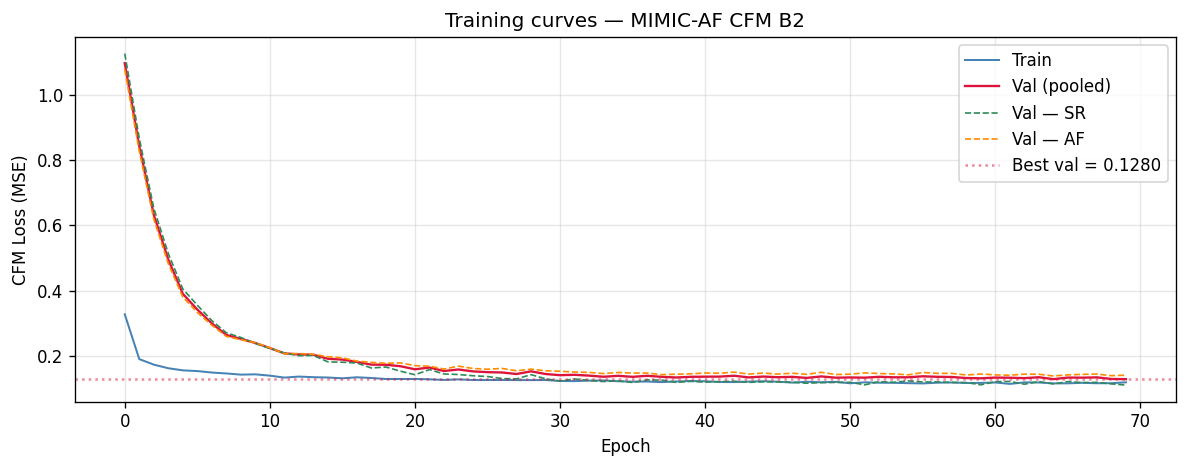

In [45]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train'],  label='Train',       color='steelblue', lw=1.2)
ax.plot(history['val'],    label='Val (pooled)', color='crimson',   lw=1.4)
ax.plot(history['val_sr'], label='Val — SR',     color='seagreen',  lw=1.0, ls='--')
ax.plot(history['val_af'], label='Val — AF',     color='darkorange',lw=1.0, ls='--')
ax.axhline(best_val_loss, color='crimson', ls=':', alpha=0.5,
           label=f'Best val = {best_val_loss:.4f}')
ax.set_xlabel('Epoch'); ax.set_ylabel('CFM Loss (MSE)')
ax.set_title('Training curves — MIMIC-AF CFM B2')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## §7 — Guidance Scale Sweep + Visual Generation
Identical to MIMIC-III-Ext-PPG.


In [ ]:
#Cell used to load the best saved model: best_cfm_zenodov2_01102
#To do this, I need to comment out the line “ckpt torch.load(CKPT_PATH,...)” 
#and uncomment the following line, where the path “path_para_modelo” 
#must be replaced with the actual path pointing to the model file.

# Load best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
#ckpt = torch.load('path_para_modelo/best_model_af_01279.pt', map_location=DEVICE, weights_only=False)

ema_model.load_state_dict(ckpt['ema_model'])
ema_model.eval()
model.load_state_dict(ckpt['model'])
model.eval()
print(f"Best checkpoint loaded — epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}")
print("Using EMA model for generation everywhere from this point on.")


In [46]:
@torch.no_grad()
def heun_sample(mdl, cond, n_steps, cfg_scale):
    """Heun (2nd-order) ODE sampler with classifier-free guidance."""
    B    = cond.size(0)
    x    = torch.randn(B, 1, WIN_LEN, device=cond.device)
    dt   = 1. / n_steps
    null = torch.zeros_like(cond)
    for i in range(n_steps):
        t_val = torch.full((B,), i*dt, device=cond.device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            v_c = mdl(x, t_val, cond); v_u = mdl(x, t_val, null)
        v  = v_u + cfg_scale * (v_c - v_u)
        xp = x + dt * v
        t_next = torch.full((B,), (i+1)*dt, device=cond.device)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            v2_c = mdl(xp, t_next, cond); v2_u = mdl(xp, t_next, null)
        v2 = v2_u + cfg_scale * (v2_c - v2_u)
        x  = x + dt * 0.5 * (v + v2)
    return x.float()


def lsd(real_b, synth_b, n_fft=512, band=None):
    """Log Spectral Distance (mean over batch). band=(fmin, fmax) for restriction."""
    eps  = 1e-10
    vals = []
    mask = None
    for i in range(min(len(real_b), len(synth_b))):
        f, r = welch(real_b[i],  fs=FS, nperseg=n_fft)
        _, s = welch(synth_b[i], fs=FS, nperseg=n_fft)
        if band is not None and mask is None:
            mask = (f >= band[0]) & (f <= band[1])
        r_use, s_use = (r[mask], s[mask]) if band is not None else (r, s)
        v = np.sqrt(np.mean((10*np.log10(r_use+eps) - 10*np.log10(s_use+eps))**2))
        if not np.isnan(v): vals.append(v)
    return float(np.mean(vals)) if vals else np.nan


print("Heun sampler and LSD function defined.")


Best checkpoint loaded — epoch 70  val_loss=0.1280
Using EMA model for generation everywhere from this point on.
Heun sampler and LSD function defined.


Sweep: 64 samples/class | 100 ODE steps
Candidates: [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]

  gs=0.0  LSD AF=6.42  SR=8.92  mean=7.67 dB
  gs=0.5  LSD AF=5.53  SR=7.93  mean=6.73 dB
  gs=1.0  LSD AF=5.57  SR=8.84  mean=7.21 dB
  gs=1.5  LSD AF=5.61  SR=9.13  mean=7.37 dB
  gs=2.0  LSD AF=5.67  SR=9.53  mean=7.60 dB
  gs=2.5  LSD AF=5.53  SR=9.59  mean=7.56 dB
  gs=3.0  LSD AF=5.82  SR=9.86  mean=7.84 dB
  gs=4.0  LSD AF=5.96  SR=10.03  mean=7.99 dB
  gs=5.0  LSD AF=6.08  SR=10.35  mean=8.21 dB

✓ Best guidance scale: 0.5  (LSD=6.73 dB)


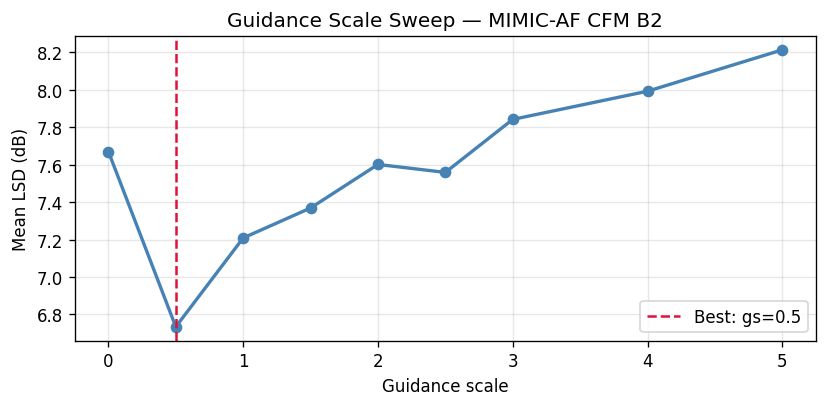

In [47]:
GS_CANDIDATES = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
N_SWEEP       = 64
STEPS_SWEEP   = 100

sw_cond, sw_real = {}, {}
for rh in ['AF', 'SR']:
    df_cls = df_test[df_test['event_rhythm'] == rh].sample(N_SWEEP, random_state=SEED)
    nm, ns, nr = norm_ibi(df_cls['IBI_mean'].values,
                           df_cls['IBI_std'].values,
                           df_cls['RMSSD'].values)
    sw_cond[rh] = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)
    sw_real[rh] = np.array([s for s in
                             [load_ppg(r['csv_path'], int(r['start_sample']))
                              for _, r in df_cls.iterrows()]
                             if s is not None][:N_SWEEP])

print(f"Sweep: {N_SWEEP} samples/class | {STEPS_SWEEP} ODE steps")
print(f"Candidates: {GS_CANDIDATES}\n")

sweep_lsd = {}
for gs in GS_CANDIDATES:
    lsd_vals = []
    for rh in ['AF', 'SR']:
        syn = heun_sample(ema_model, sw_cond[rh], STEPS_SWEEP, gs).cpu().numpy().squeeze(1)
        lsd_vals.append(lsd(sw_real[rh], syn, band=(0.5, 8.0)))
    mean_lsd = np.nanmean(lsd_vals)
    sweep_lsd[gs] = mean_lsd
    print(f"  gs={gs:.1f}  LSD AF={lsd_vals[0]:.2f}  SR={lsd_vals[1]:.2f}"
          f"  mean={mean_lsd:.2f} dB")

BEST_GS = min(sweep_lsd, key=sweep_lsd.get)
print(f"\n✓ Best guidance scale: {BEST_GS}  (LSD={sweep_lsd[BEST_GS]:.2f} dB)")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(list(sweep_lsd.keys()), list(sweep_lsd.values()), 'o-', color='steelblue', lw=2)
ax.axvline(BEST_GS, color='crimson', ls='--', label=f'Best: gs={BEST_GS}')
ax.set_xlabel('Guidance scale'); ax.set_ylabel('Mean LSD (dB)')
ax.set_title('Guidance Scale Sweep — MIMIC-AF CFM B2'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


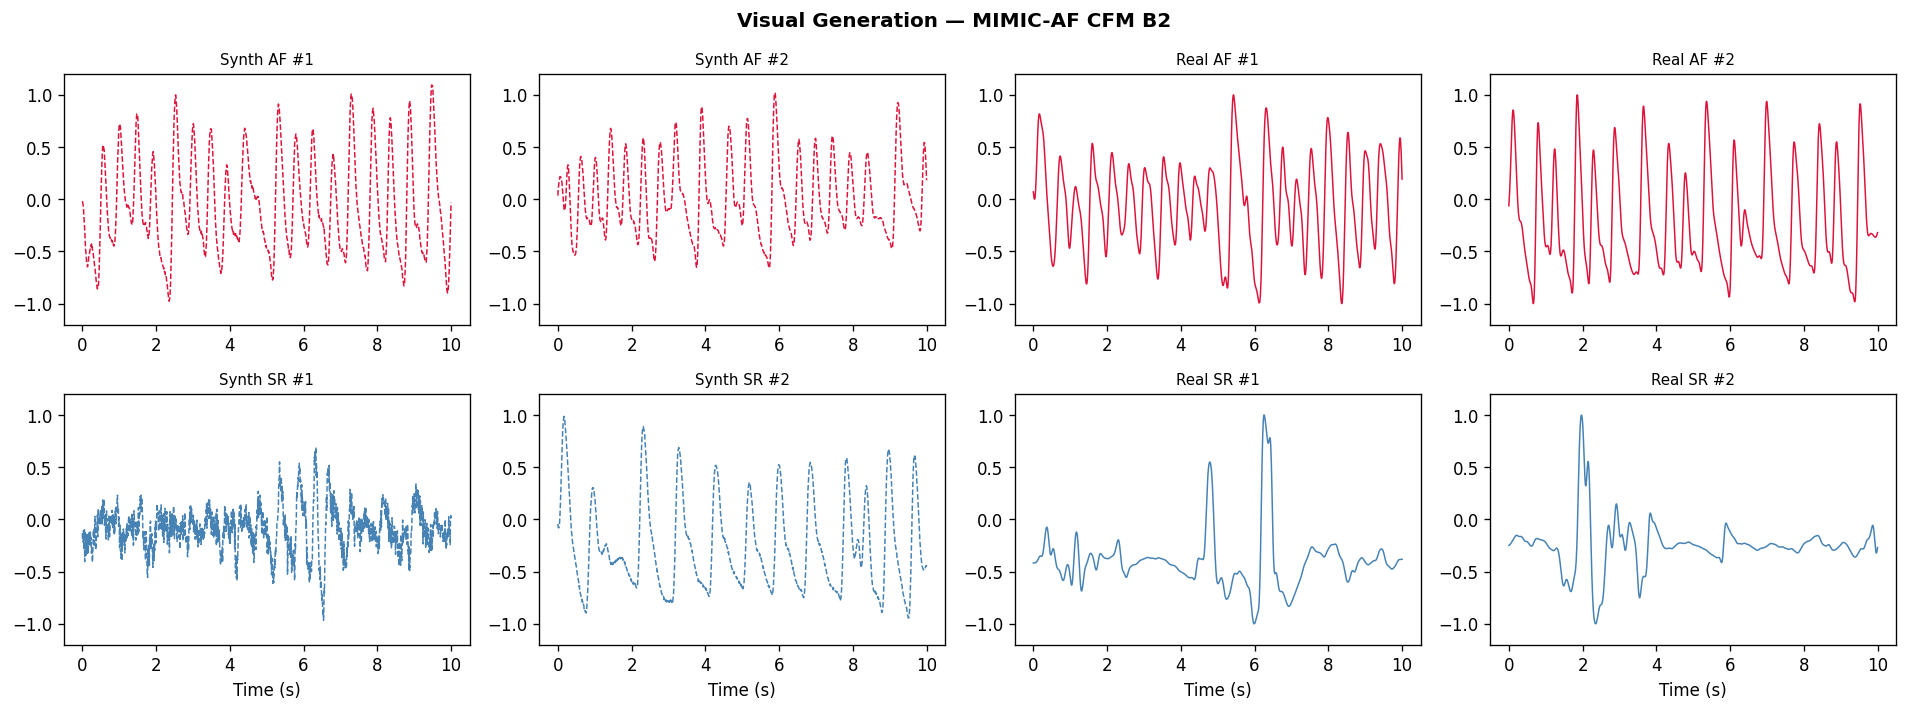

In [48]:
N_VIS = 50
vis_synth, vis_real = {}, {}
for rh in ['AF', 'SR']:
    df_cls = df_test[df_test['event_rhythm'] == rh].sample(
        min(N_VIS, len(df_test[df_test['event_rhythm'] == rh])), random_state=SEED)
    nm, ns, nr = norm_ibi(df_cls['IBI_mean'].values,
                           df_cls['IBI_std'].values,
                           df_cls['RMSSD'].values)
    cond  = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)
    synth = []
    for i in range(0, len(cond), 64):
        synth.append(heun_sample(ema_model, cond[i:i+64], ODE_STEPS, BEST_GS).cpu().numpy())
    vis_synth[rh] = np.concatenate(synth).squeeze(1)
    vis_real[rh]  = np.array([s for s in
                               [load_ppg(r['csv_path'], int(r['start_sample']))
                                for _, r in df_cls.iterrows()]
                               if s is not None][:N_VIS])

t_ax = np.linspace(0, WIN_SEC, WIN_LEN)
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for row, rh in enumerate(['AF', 'SR']):
    cr = 'crimson' if rh == 'AF' else 'steelblue'
    for col, (sig, lbl, ls) in enumerate([
        (vis_synth[rh][0], f'Synth {rh} #1', '--'),
        (vis_synth[rh][1], f'Synth {rh} #2', '--'),
        (vis_real[rh][0],  f'Real {rh} #1',  '-'),
        (vis_real[rh][1],  f'Real {rh} #2',  '-'),
    ]):
        axes[row][col].plot(t_ax, sig, color=cr, lw=0.9, ls=ls)
        axes[row][col].set_title(lbl, fontsize=9)
        axes[row][col].set_ylim(-1.2, 1.2)
        if row == 1:
            axes[row][col].set_xlabel('Time (s)')

plt.suptitle('Visual Generation — MIMIC-AF CFM B2', fontweight='bold')
plt.tight_layout(); plt.show()

## §8 — Spectral Evaluation (PSD + LSD)

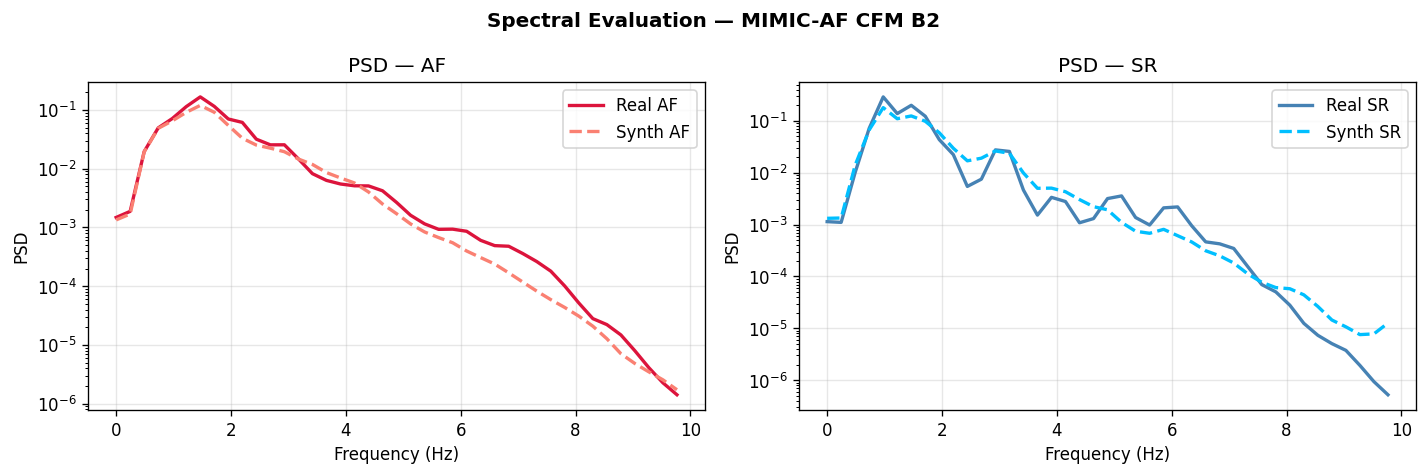


LSD (0.5-8 Hz band):  AF=5.56 dB  |  SR=8.57 dB  |  mean=7.07 dB
LSD (full spectrum):  AF=32.93 dB  |  SR=33.41 dB  (for reference — inflated by out-of-band residuals)


In [49]:
N_EVAL = min(200, len(df_test[df_test['event_rhythm']=='AF']),
                   len(df_test[df_test['event_rhythm']=='SR']))

eval_real, eval_synth = {}, {}
for rh in ['AF', 'SR']:
    df_cls = df_test[df_test['event_rhythm'] == rh].sample(N_EVAL, random_state=SEED)
    nm, ns, nr = norm_ibi(df_cls['IBI_mean'].values,
                           df_cls['IBI_std'].values,
                           df_cls['RMSSD'].values)
    cond = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)
    synth = []
    for i in range(0, len(cond), 64):
        synth.append(heun_sample(ema_model, cond[i:i+64], ODE_STEPS, BEST_GS).cpu().numpy())
    eval_synth[rh] = np.concatenate(synth).squeeze(1)
    eval_real[rh]  = np.array([s for s in
                                [load_ppg(r['csv_path'], int(r['start_sample']))
                                 for _, r in df_cls.iterrows()]
                                if s is not None][:N_EVAL])

# PSD plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, rh, cr, cs in [(axes[0],'AF','crimson','salmon'),
                        (axes[1],'SR','steelblue','deepskyblue')]:
    freqs = None
    psd_r_list, psd_s_list = [], []
    for sig in eval_real[rh]:
        f, p = welch(sig, fs=FS, nperseg=512); freqs = f; psd_r_list.append(p)
    for sig in eval_synth[rh]:
        _, p = welch(sig, fs=FS, nperseg=512); psd_s_list.append(p)
    psd_r = np.array(psd_r_list).mean(0)
    psd_s = np.array(psd_s_list).mean(0)
    mask  = freqs <= 10
    ax.semilogy(freqs[mask], psd_r[mask], color=cr, lw=2, label=f'Real {rh}')
    ax.semilogy(freqs[mask], psd_s[mask], color=cs, lw=2, ls='--', label=f'Synth {rh}')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD')
    ax.set_title(f'PSD — {rh}'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Spectral Evaluation — MIMIC-AF CFM B2', fontweight='bold')
plt.tight_layout(); plt.show()

# LSD (band-restricted)
lsd_af = lsd(eval_real['AF'], eval_synth['AF'], band=(0.5, 8.0))
lsd_sr = lsd(eval_real['SR'], eval_synth['SR'], band=(0.5, 8.0))
lsd_af_full = lsd(eval_real['AF'], eval_synth['AF'])
lsd_sr_full = lsd(eval_real['SR'], eval_synth['SR'])
print(f"\nLSD (0.5-8 Hz band):  AF={lsd_af:.2f} dB  |  SR={lsd_sr:.2f} dB"
      f"  |  mean={np.mean([lsd_af,lsd_sr]):.2f} dB")
print(f"LSD (full spectrum):  AF={lsd_af_full:.2f} dB  |  SR={lsd_sr_full:.2f} dB"
      f"  (for reference — inflated by out-of-band residuals)")


# Sampling speed benchmark

In [50]:
# ── Sampling speed benchmark ──────────────────────────────────────────────────
# Mede o tempo do sampler Heun ODE para diferentes números de amostras.
# Reporta: tempo total, tempo por amostra, amostras por segundo.
import time

N_BENCHMARK   = [1, 8, 32, 64]   # batch sizes a testar
N_STEPS_LIST  = [ODE_STEPS]      # testar com os ODE steps usados (100)
N_WARMUP      = 2                 # warmup runs (não contam — aquece CUDA)

# Conditioning fixo para o benchmark (AF, valores médios normalizados)
_nm = np.zeros(max(N_BENCHMARK), dtype=np.float32)   # IBI_mean normalizado = 0
_ns = np.zeros(max(N_BENCHMARK), dtype=np.float32)   # IBI_std normalizado = 0
_nr = np.zeros(max(N_BENCHMARK), dtype=np.float32)   # RMSSD normalizado = 0
_cond_bench = torch.tensor(
    build_cond(_nm, _ns, _nr, 'AF'), dtype=torch.float32).to(DEVICE)

print('Sampling speed benchmark — Heun ODE sampler')
print(f'Device: {DEVICE}  |  WIN_LEN: {WIN_LEN}  |  ODE steps: {ODE_STEPS}')
print(f'Warmup: {N_WARMUP} runs (não contabilizados)\n')

results_speed = {}

for n_steps in N_STEPS_LIST:
    print(f'── ODE steps = {n_steps} ──────────────────────────────────────────')
    for bs in N_BENCHMARK:
        cond_b = _cond_bench[:bs]

        # Warmup
        for _ in range(N_WARMUP):
            with torch.no_grad():
                _ = heun_sample(ema_model, cond_b, n_steps, BEST_GS)
        torch.cuda.synchronize()

        # Medição
        N_REPS = max(1, 10 // bs)   # mais repetições para batches pequenos
        t0 = time.perf_counter()
        for _ in range(N_REPS):
            with torch.no_grad():
                out = heun_sample(ema_model, cond_b, n_steps, BEST_GS)
        torch.cuda.synchronize()
        t1 = time.perf_counter()

        total_s      = (t1 - t0) / N_REPS
        per_sample_s = total_s / bs
        throughput   = bs / total_s

        results_speed[(n_steps, bs)] = dict(
            total_s      = total_s,
            per_sample_s = per_sample_s,
            throughput   = throughput,
        )
        print(f'  batch={bs:>3}  reps={N_REPS}  '
              f'total={total_s:.3f}s  '
              f'per_sample={per_sample_s*1000:.1f}ms  '
              f'throughput={throughput:.1f} samples/s')
    print()

# ── Tabela resumo ─────────────────────────────────────────────────────────────
print('=' * 70)
print(f'  Sampling Speed Summary — Heun ODE, {ODE_STEPS} steps, {WIN_LEN} samples @ {FS} Hz')
print('=' * 70)
print(f"  {'Batch':>6}  {'Time/sample (ms)':>18}  {'Throughput (s/s)':>18}  {'Total (s)':>10}")
print('  ' + '─' * 60)
for bs in N_BENCHMARK:
    r = results_speed[(ODE_STEPS, bs)]
    # throughput em "seconds of signal generated per second of wall time"
    signal_s_per_wall_s = bs * WIN_SEC / r['total_s']
    print(f"  {bs:>6}  "
          f"{r['per_sample_s']*1000:>18.1f}  "
          f"{r['throughput']:>18.1f}  "
          f"{r['total_s']:>10.3f}s")
print('=' * 70)
print()

# Referência: tempo para gerar N_EVAL=300 amostras (como em §8)
r64 = results_speed[(ODE_STEPS, 64)]
t_300 = (300 / 64) * r64['total_s']
print(f'Estimativa para gerar {N_EVAL} amostras (batch=64): ~{t_300:.1f}s')
print(f'Estimativa para gerar 1000 amostras (batch=64):     '
      f'~{(1000/64)*r64["total_s"]:.1f}s')
print()
print(f'Tempo de sinal gerado por segundo de wall time (batch=64):')
print(f'  {64 * WIN_SEC / r64["total_s"]:.1f}s de PPG sintético / segundo de computação')
print()
print('Nota: OT-CFM com Heun ODE a 100 steps é substancialmente mais rápido')
print('que DDPM ancestral (1000 steps) — factor teórico de 10x em steps,')
print('com overhead prático dependente do tamanho do batch e da GPU.')

Sampling speed benchmark — Heun ODE sampler
Device: cuda  |  WIN_LEN: 1250  |  ODE steps: 100
Warmup: 2 runs (não contabilizados)

── ODE steps = 100 ──────────────────────────────────────────
  batch=  1  reps=10  total=8.288s  per_sample=8288.1ms  throughput=0.1 samples/s
  batch=  8  reps=1  total=7.880s  per_sample=985.0ms  throughput=1.0 samples/s
  batch= 32  reps=1  total=13.537s  per_sample=423.0ms  throughput=2.4 samples/s
  batch= 64  reps=1  total=26.168s  per_sample=408.9ms  throughput=2.4 samples/s

  Sampling Speed Summary — Heun ODE, 100 steps, 1250 samples @ 125 Hz
   Batch    Time/sample (ms)    Throughput (s/s)   Total (s)
  ────────────────────────────────────────────────────────────
       1              8288.1                 0.1       8.288s
       8               985.0                 1.0       7.880s
      32               423.0                 2.4      13.537s
      64               408.9                 2.4      26.168s

Estimativa para gerar 200 amostras (bat

# Nearest-Neighbour Morphological Metrics (PRD + Pearson)

In [51]:
# ── §8b — Nearest-Neighbour Morphological Metrics (PRD + Pearson) ────────────
# For each synthetic, finds its nearest real (L2) and computes PRD + Pearson.
# Crucially, also computes the Real↔Real baseline: the same metric between
# two disjoint subsets of real signals (i.e. inter-patient morphological
# variability). This is the morphological floor.
#
# Interpretation:
#   Synth→Real ≈ Real↔Real  →  synthetics are indistinguishable from
#                               inter-patient variability (generation quality OK)
#   PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).
#   These metrics are NOT comparable with ECG→PPG papers where pairs exist.

from sklearn.metrics import pairwise_distances

def prd_signal(real, synth):
    """Percent Root-mean-square Difference (%)."""
    num = np.sum((real - synth) ** 2)
    den = np.sum(real ** 2)
    return 100.0 * np.sqrt(num / (den + 1e-10))


def nn_metrics(real_sigs, synth_sigs, n=200, seed=SEED):
    """
    Synth→Real NN: for each synthetic, find its nearest real (L2)
    and compute PRD and Pearson on that pair.
    """
    rng   = np.random.default_rng(seed)
    idx_r = rng.choice(len(real_sigs),  min(n, len(real_sigs)),  replace=False)
    idx_s = rng.choice(len(synth_sigs), min(n, len(synth_sigs)), replace=False)
    R, S  = real_sigs[idx_r], synth_sigs[idx_s]
    D     = pairwise_distances(S, R, metric='euclidean')
    nn_i  = D.argmin(axis=1)
    prds, pccs = [], []
    for i, j in enumerate(nn_i):
        prds.append(prd_signal(R[j], S[i]))
        r = np.corrcoef(R[j], S[i])[0, 1]
        if not np.isnan(r): pccs.append(r)
    return (float(np.mean(prds)),    float(np.std(prds)),
            float(np.mean(pccs)), float(np.std(pccs)))


def nn_metrics_real_vs_real(real_sigs, n=200, seed=SEED+1):
    """
    Real↔Real baseline: same computation between two disjoint subsets
    of real signals. Quantifies inter-patient morphological variability —
    the floor that synthetic-vs-real should approach.
    """
    rng   = np.random.default_rng(seed)
    n_use = min(n * 2, len(real_sigs))
    idx   = rng.choice(len(real_sigs), n_use, replace=False)
    nh    = n_use // 2
    R1, R2 = real_sigs[idx[:nh]], real_sigs[idx[nh:2*nh]]
    D      = pairwise_distances(R1, R2, metric='euclidean')
    nn_i   = D.argmin(axis=1)
    prds, pccs = [], []
    for i, j in enumerate(nn_i):
        prds.append(prd_signal(R2[j], R1[i]))
        r = np.corrcoef(R2[j], R1[i])[0, 1]
        if not np.isnan(r): pccs.append(r)
    return (float(np.mean(prds)),    float(np.std(prds)),
            float(np.mean(pccs)), float(np.std(pccs)))


print('Computing nearest-neighbour PRD and Pearson (n=200 per class)...')
print('This may take ~1-2 min (200×200 pairwise L2 matrices).\n')

nn_res = {}
for rh in ['AF', 'SR']:
    pm, ps, cm, cs     = nn_metrics(eval_real[rh], eval_synth[rh])
    rpm, rps, rcm, rcs = nn_metrics_real_vs_real(eval_real[rh])
    nn_res[rh] = dict(prd_sv=(pm, ps), pcc_sv=(cm, cs),
                      prd_rr=(rpm, rps), pcc_rr=(rcm, rcs))
    print(f'  {rh} done')

print()
print('=' * 80)
print('  Nearest-Neighbour Morphological Metrics')
print('=' * 80)
print(f"  {'Metric':<20}  {'Real\u2194Real (baseline)':>22}  "
      f"{'Synth\u2192Real (NN)':>22}  {'Overhead':>10}")
print('  ' + '\u2500' * 78)
for rh in ['AF', 'SR']:
    r = nn_res[rh]
    pm, ps   = r['prd_sv'];  cm, cs   = r['pcc_sv']
    rpm, rps = r['prd_rr'];  rcm, rcs = r['pcc_rr']
    print(f'  \u2500\u2500 Class: {rh}')
    print(f"  {'PRD (%)':<20}  {rpm:>8.2f}\u00b1{rps:>6.2f}           "
          f"{pm:>8.2f}\u00b1{ps:>6.2f}  {pm-rpm:>+9.1f}%")
    print(f"  {'Pearson':<20}  {rcm:>8.4f}\u00b1{rcs:>6.4f}           "
          f"{cm:>8.4f}\u00b1{cs:>6.4f}  {cm-rcm:>+9.4f}")
print('=' * 80)
print()
print('Overhead close to 0 \u2192 synthetics indistinguishable from inter-patient variability.')
print('PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).')
print()
for rh in ['AF', 'SR']:
    r = nn_res[rh]
    print(f'  {rh}: PRD overhead = {r["prd_sv"][0]-r["prd_rr"][0]:+.1f}%  |  '
          f'Pearson gap = {r["pcc_sv"][0]-r["pcc_rr"][0]:+.4f}')


Computing nearest-neighbour PRD and Pearson (n=200 per class)...
This may take ~1-2 min (200×200 pairwise L2 matrices).

  AF done
  SR done

  Nearest-Neighbour Morphological Metrics
  Metric                  Real↔Real (baseline)         Synth→Real (NN)    Overhead
  ──────────────────────────────────────────────────────────────────────────────
  ── Class: AF
  PRD (%)                 121.05± 23.34             119.84± 23.17       -1.2%
  Pearson                 0.3210±0.1569             0.2970±0.1592    -0.0241
  ── Class: SR
  PRD (%)                  76.47± 47.67             103.90± 45.05      +27.4%
  Pearson                 0.6636±0.3231             0.4834±0.2907    -0.1802

Overhead close to 0 → synthetics indistinguishable from inter-patient variability.
PRD > 100% and low Pearson are EXPECTED for generation (vs reconstruction).

  AF: PRD overhead = -1.2%  |  Pearson gap = -0.0241
  SR: PRD overhead = +27.4%  |  Pearson gap = -0.1802


# Paired PRD/Pearson (conditioning-vector-paired)

In [52]:
# ── §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired) ────────────────
# Versão mais rigorosa de §10b:
#   Paired:   synthetic_i gerado do conditioning de real_i → PRD/Pearson(synth_i, real_i)
#   Baseline: para cada real_i, encontra real_j com conditioning mais próximo (j≠i)
#             → PRD/Pearson(real_i, real_j)
# O baseline controla a similaridade de condicionamento — isola a variação
# morfológica natural entre doentes com HRV semelhante.
#
# Requires: prd_signal (§10b), load_ppg (§4), ema_model, norm_ibi, build_cond,
#           heun_sample, ODE_STEPS, BEST_GS, df_test, SEED, DEVICE

from sklearn.preprocessing import StandardScaler as _SS

# Redefinir prd_signal se §10b não tiver corrido
if 'prd_signal' not in dir():
    def prd_signal(real, synth):
        num = np.sum((real - synth) ** 2)
        den = np.sum(real ** 2)
        return 100.0 * np.sqrt(num / (den + 1e-10))

N_PAIRED = 200   # pares por classe

print('§10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)')
print(f'N = {N_PAIRED} pares por classe\n')

paired_res = {}

for rh in ['AF', 'SR']:
    # ── 1. Amostrar N linhas de df_test ──────────────────────────────────────
    df_rh = (df_test[df_test['event_rhythm'] == rh]
             .sample(min(N_PAIRED * 2, len(df_test[df_test['event_rhythm'] == rh])),
                     random_state=SEED)
             .reset_index(drop=True))

    # ── 2. Carregar sinais reais linha a linha (garante alinhamento) ──────────
    reals, valid_idx = [], []
    for i, row in df_rh.iterrows():
        try:
            sig = load_ppg(row['csv_path'], int(row['start_sample']))
            if sig is not None and len(sig) == WIN_LEN:
                reals.append(sig)
                valid_idx.append(i)
                if len(reals) >= N_PAIRED:
                    break
        except:
            continue

    df_valid   = df_rh.loc[valid_idx].reset_index(drop=True)
    X_real_p   = np.array(reals, dtype=np.float32)   # (n, WIN_LEN)
    n_valid    = len(X_real_p)
    print(f'{rh}: {n_valid} sinais reais carregados')

    if n_valid < 10:
        print(f'  WARN: menos de 10 sinais válidos — saltar\n')
        continue

    # ── 3. Gerar sintéticos paired (um por linha de df_valid) ─────────────────
    torch.cuda.empty_cache()
    nm, ns, nr = norm_ibi(df_valid['IBI_mean'].values,
                          df_valid['IBI_std'].values,
                          df_valid['RMSSD'].values)
    cond_t = torch.tensor(build_cond(nm, ns, nr, rh),
                          dtype=torch.float32).to(DEVICE)
    chunks = []
    for i in range(0, len(cond_t), 64):
        chunks.append(
            heun_sample(ema_model, cond_t[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    X_synth_p = np.concatenate(chunks)    # (n, WIN_LEN) — alinhado com X_real_p
    torch.cuda.empty_cache()

    # ── 4. PRD/Pearson paired: synthetic_i vs real_i ──────────────────────────
    prds_p, pccs_p = [], []
    for i in range(n_valid):
        prds_p.append(prd_signal(X_real_p[i], X_synth_p[i]))
        r = np.corrcoef(X_real_p[i], X_synth_p[i])[0, 1]
        if not np.isnan(r):
            pccs_p.append(r)

    # ── 5. Baseline: nearest conditioning neighbor (real vs conditioning-matched real)
    # Para cada real_i, encontra real_j (j≠i) com conditioning mais próximo
    cond_raw    = df_valid[['IBI_mean', 'IBI_std', 'RMSSD']].values
    cond_scaled = _SS().fit_transform(cond_raw)
    D_cond      = pairwise_distances(cond_scaled, metric='euclidean')
    np.fill_diagonal(D_cond, np.inf)      # excluir self
    nn_cond_idx = D_cond.argmin(axis=1)  # índice do conditioning mais próximo

    prds_b, pccs_b, cond_dists = [], [], []
    for i in range(n_valid):
        j = nn_cond_idx[i]
        prds_b.append(prd_signal(X_real_p[i], X_real_p[j]))
        r = np.corrcoef(X_real_p[i], X_real_p[j])[0, 1]
        if not np.isnan(r):
            pccs_b.append(r)
        cond_dists.append(D_cond[i, j])   # distância de condicionamento do par

    paired_res[rh] = dict(
        prd_p  = (float(np.mean(prds_p)), float(np.std(prds_p))),
        pcc_p  = (float(np.mean(pccs_p)), float(np.std(pccs_p))),
        prd_b  = (float(np.mean(prds_b)), float(np.std(prds_b))),
        pcc_b  = (float(np.mean(pccs_b)), float(np.std(pccs_b))),
        cond_d = (float(np.mean(cond_dists)), float(np.std(cond_dists))),
        n      = n_valid,
    )
    
    paired_res[rh]['X_real']    = X_real_p
    paired_res[rh]['X_synth']   = X_synth_p
    paired_res[rh]['nn_cond_i'] = nn_cond_idx
    
    overhead_prd = float(np.mean(prds_p)) - float(np.mean(prds_b))
    overhead_pcc = float(np.mean(pccs_p)) - float(np.mean(pccs_b))
    print(f'  PRD  paired={np.mean(prds_p):.2f}%  baseline={np.mean(prds_b):.2f}%  '
          f'overhead={overhead_prd:+.2f}%')
    print(f'  PCC  paired={np.mean(pccs_p):.4f}   baseline={np.mean(pccs_b):.4f}   '
          f'gap={overhead_pcc:+.4f}')
    print(f'  Mean conditioning distance of baseline pairs: {np.mean(cond_dists):.4f}')
    print()

# ── Tabela de resultados ───────────────────────────────────────────────────────
print()
print('=' * 82)
print('  §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)')
print('=' * 82)
print(f"  {'Metric':<38}  {'AF':>18}  {'SR':>18}")
print('  ' + '─' * 78)
for rh in ['AF', 'SR']:
    if rh not in paired_res: continue
    r = paired_res[rh]
    print(f"  {'─'*78}")
    print(f"  Class {rh}  (n = {r['n']})")
    print(f"  {'PRD (%) — synth_i vs real_i':<38}  "
          f"{r['prd_p'][0]:>7.2f}±{r['prd_p'][1]:>6.2f}   "
          f"  {paired_res[rh]['prd_p'][0]:>7.2f}")
    print(f"  {'PRD (%) — real_i vs cond-NN real_j':<38}  "
          f"{r['prd_b'][0]:>7.2f}±{r['prd_b'][1]:>6.2f}   "
          f"  {'(baseline)':>7}")
    print(f"  {'PRD overhead (synth−baseline)':<38}  "
          f"{r['prd_p'][0]-r['prd_b'][0]:>+14.2f}%")
    print(f"  {'Pearson — synth_i vs real_i':<38}  "
          f"{r['pcc_p'][0]:>7.4f}±{r['pcc_p'][1]:>6.4f}   "
          f"  {paired_res[rh]['pcc_p'][0]:>7.4f}")
    print(f"  {'Pearson — real_i vs cond-NN real_j':<38}  "
          f"{r['pcc_b'][0]:>7.4f}±{r['pcc_b'][1]:>6.4f}   "
          f"  {'(baseline)':>7}")
    print(f"  {'Pearson gap (synth−baseline)':<38}  "
          f"{r['pcc_p'][0]-r['pcc_b'][0]:>+14.4f}")
print('=' * 82)

print()
print('Interpretation:')
print('  Baseline = real_i vs real_j with most similar conditioning vector.')
print('  Controls for conditioning similarity — isolates morphological variation')
print('  beyond what IBI_mean/IBI_std/RMSSD can predict.')
print()
print('  PRD overhead ≈ 0 → synthetic morphology is as close to real_i as')
print('  another real signal with the same HRV features would be.')
print('  PRD overhead >> 0 → generator introduces extra morphological variation')
print('  beyond what conditioning determines.')
print()
for rh in paired_res:
    r = paired_res[rh]
    print(f'  {rh}: PRD overhead = {r["prd_p"][0]-r["prd_b"][0]:+.2f}%  |  '
          f'Pearson gap = {r["pcc_p"][0]-r["pcc_b"][0]:+.4f}  |  '
          f'mean cond-dist of baseline pairs = {r["cond_d"][0]:.4f}')

# ── Comparação com §10b (NN em espaço de sinal) ───────────────────────────────
if 'nn_res' in dir():
    print()
    print('─' * 82)
    print('  Comparação §10b (NN sinal-espaço) vs §10b-v2 (conditioning-paired)')
    print('─' * 82)
    print(f"  {'Métrica':<40}  {'AF':>18}  {'SR':>18}")
    for rh in ['AF', 'SR']:
        if rh not in paired_res or rh not in nn_res: continue
        r_nn = nn_res[rh]; r_p = paired_res[rh]
        print(f"  {rh} PRD §10b  (synth→NN real)          "
              f"  {r_nn['prd_sv'][0]:>8.2f}%")
        print(f"  {rh} PRD §10b-v2 (synth→conditioning real)  "
              f"  {r_p['prd_p'][0]:>8.2f}%")
    print('─' * 82)

§10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)
N = 200 pares por classe

AF: 200 sinais reais carregados
  PRD  paired=134.38%  baseline=135.28%  overhead=-0.90%
  PCC  paired=0.0105   baseline=0.0084   gap=+0.0021
  Mean conditioning distance of baseline pairs: 0.2115

SR: 200 sinais reais carregados
  PRD  paired=135.69%  baseline=124.65%  overhead=+11.04%
  PCC  paired=0.0021   baseline=0.1207   gap=-0.1187
  Mean conditioning distance of baseline pairs: 0.1225


  §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)
  Metric                                                  AF                  SR
  ──────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────
  Class AF  (n = 200)
  PRD (%) — synth_i vs real_i              134.38± 18.83      134.38
  PRD (%) — real_i vs cond-NN real_j       135.28± 17.86     (baseline)
  PRD overhead (synth−baseline)                    -

# Local density of conditioning-matched pairs

In [53]:
# ── §10b-v3 — Densidade local dos pares conditioning-matched ─────────────────
from sklearn.metrics import pairwise_distances as _pwd

print('§10b-v3 — Local density verification of conditioning-matched pairs')
print('Confirms pairs lie in dense regions (not isolated outliers)\n')

for rh in ['AF', 'SR']:
    if rh not in paired_res or 'X_real' not in paired_res[rh]:
        print(f'{rh}: dados não encontrados — correr §10b-v2 primeiro')
        continue

    X_real_p   = paired_res[rh]['X_real']
    X_synth_p  = paired_res[rh]['X_synth']
    nn_cond_i  = paired_res[rh]['nn_cond_i']
    n          = paired_res[rh]['n']

    # Matriz de distâncias de sinal entre todos os reais
    D_sig = _pwd(X_real_p, metric='euclidean')
    np.fill_diagonal(D_sig, np.inf)

    # Raio = percentil 25 de todas as distâncias (define "zona densa")
    r25 = np.percentile(D_sig[D_sig < np.inf], 25)

    # Para cada real_i: quantos reais estão dentro do raio r25?
    k_real = [(D_sig[i] < r25).sum() for i in range(n)]

    # Para cada par baseline (real_i, real_j): distância de sinal
    dist_baseline_signal = [D_sig[i, nn_cond_i[i]] for i in range(n)]

    # Para cada par paired (synth_i, real_i): distância de sinal
    dist_paired_signal = [
        float(np.linalg.norm(X_synth_p[i] - X_real_p[i])) for i in range(n)
    ]

    # Distâncias aleatórias (pares random real_i vs real_j, j≠i) como referência
    rng_d = np.random.default_rng(SEED)
    rand_j = [rng_d.choice([k for k in range(n) if k != i]) for i in range(n)]
    dist_random_signal = [D_sig[i, rand_j[i]] for i in range(n)]

    print(f'── Class {rh} (n={n}) ──────────────────────────────────────────────')
    print(f'  Signal-space distance (L2):')
    print(f'    synth_i vs real_i  (paired)    : '
          f'{np.mean(dist_paired_signal):>8.3f} ± {np.std(dist_paired_signal):.3f}')
    print(f'    real_i vs cond-NN real_j (base): '
          f'{np.mean(dist_baseline_signal):>8.3f} ± {np.std(dist_baseline_signal):.3f}')
    print(f'    real_i vs random real_j         : '
          f'{np.mean(dist_random_signal):>8.3f} ± {np.std(dist_random_signal):.3f}')
    print(f'  Local density (neighbours within r25={r25:.2f}):')
    print(f'    Mean neighbours per real_i      : {np.mean(k_real):.1f}')
    print(f'    Min / Max                       : {min(k_real)} / {max(k_real)}')
    frac_isolated = sum(1 for k in k_real if k == 0) / n
    print(f'    Fraction isolated (0 neighbours): {frac_isolated:.1%}')
    print()

print('Interpretation:')
print('  dist(synth_i, real_i) < dist(random real pair)')
print('  → conditioning-paired synthetics are closer to their target than chance.')
print()
print('  dist(cond-NN baseline) < dist(random real pair)')
print('  → conditioning vector has predictive power over signal morphology.')
print()
print('  fraction isolated ≈ 0 → pairs are in dense regions, baseline is reliable.')
print('  fraction isolated >> 0 → some reals are outliers; baseline PRD for those')
print('  pairs is inflated and should be interpreted with caution.')

§10b-v3 — Local density verification of conditioning-matched pairs
Confirms pairs lie in dense regions (not isolated outliers)

── Class AF (n=200) ──────────────────────────────────────────────
  Signal-space distance (L2):
    synth_i vs real_i  (paired)    :   22.344 ± 2.625
    real_i vs cond-NN real_j (base):   22.503 ± 2.679
    real_i vs random real_j         :   23.034 ± 2.330
  Local density (neighbours within r25=21.45):
    Mean neighbours per real_i      : 49.8
    Min / Max                       : 6 / 179
    Fraction isolated (0 neighbours): 0.0%

── Class SR (n=200) ──────────────────────────────────────────────
  Signal-space distance (L2):
    synth_i vs real_i  (paired)    :   24.061 ± 5.130
    real_i vs cond-NN real_j (base):   22.242 ± 7.322
    real_i vs random real_j         :   24.788 ± 4.938
  Local density (neighbours within r25=22.10):
    Mean neighbours per real_i      : 49.8
    Min / Max                       : 7 / 181
    Fraction isolated (0 neighbours)

## §9 — Physiological Consistency


Metric             Real AF      Synth AF       Real SR      Synth SR
──────────────────────────────────────────────────────────────
  HR          101.839±15.857  92.834±15.677  75.408±16.364  79.502±17.829
  IBI_mean     0.603±0.091   0.668±0.141   0.835±0.184   0.793±0.174
  IBI_std      0.125±0.052   0.168±0.076   0.092±0.115   0.147±0.112


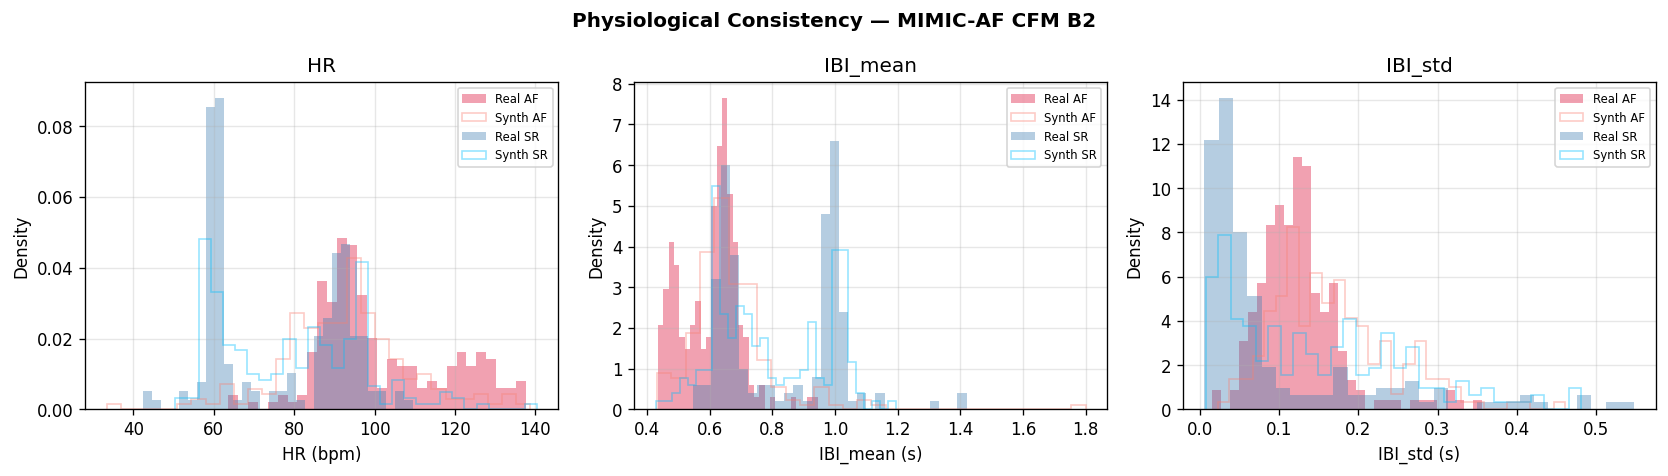

In [54]:
def ppg_phys(signals, fs=FS):
    """Extract HR, IBI_mean, IBI_std, RMSSD from PPG signals using find_peaks."""
    out = {'HR': [], 'IBI_mean': [], 'IBI_std': [], 'RMSSD': []}
    for sig in signals:
        try:
            peaks, _ = find_peaks(sig, distance=int(fs*0.3), height=0.05)
            ibi = np.diff(peaks) / fs
            ibi = ibi[(ibi >= IBI_MIN) & (ibi <= IBI_MAX)]
            if len(ibi) >= 2:
                out['HR'].append(60 / ibi.mean())
                out['IBI_mean'].append(ibi.mean())
                out['IBI_std'].append(ibi.std())
                out['RMSSD'].append(np.sqrt(np.mean(np.diff(ibi)**2)) if len(ibi) >= 3 else np.nan)
        except:
            pass
    return out

metrics = {}
for key, sigs in [('AF_real',   eval_real['AF']),  ('AF_synth',  eval_synth['AF']),
                   ('SR_real',   eval_real['SR']),  ('SR_synth',  eval_synth['SR'])]:
    metrics[key] = ppg_phys(sigs)

print(f"\n{'Metric':<12}  {'Real AF':>12}  {'Synth AF':>12}  {'Real SR':>12}  {'Synth SR':>12}")
print("─" * 62)
for feat in ['HR', 'IBI_mean', 'IBI_std', 'RMSSD']:
    vals = []
    for key in ['AF_real','AF_synth','SR_real','SR_synth']:
        v = [x for x in metrics[key][feat] if not np.isnan(x)]
        vals.append(f"{np.mean(v):.3f}±{np.std(v):.3f}" if v else "N/A")
    print(f"  {feat:<10}  {vals[0]:>12}  {vals[1]:>12}  {vals[2]:>12}  {vals[3]:>12}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat, unit in zip(axes, ['HR','IBI_mean','IBI_std','RMSSD'], ['bpm','s','s','s']):
    for rh, cr, cs in [('AF','crimson','salmon'), ('SR','steelblue','deepskyblue')]:
        r_vals = [x for x in metrics[f'{rh}_real'][feat] if not np.isnan(x)]
        s_vals = [x for x in metrics[f'{rh}_synth'][feat] if not np.isnan(x)]
        if r_vals: ax.hist(r_vals, bins=30, alpha=0.4, color=cr, density=True, label=f'Real {rh}')
        if s_vals: ax.hist(s_vals, bins=30, alpha=0.4, color=cs, density=True,
                           label=f'Synth {rh}', histtype='step', lw=2)
    ax.set_xlabel(f'{feat} ({unit})'); ax.set_ylabel('Density')
    ax.set_title(feat); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle('Physiological Consistency — MIMIC-AF CFM B2', fontweight='bold')
plt.tight_layout(); plt.show()

# Conditioning fidelity: MAE HR and IBI_std ratio

In [55]:
# ── Fidelidade do condicionamento: MAE HR e IBI_std ratio ────────────────────
# Métricas específicas ao condicionamento explícito (não disponíveis em GANs
# incondicionais): medem se o modelo respeitou os targets pedidos.

def extrair_hr_e_ibi(signals, fs=FS):
    """Extrai HR (bpm) e IBI_std de cada sinal via find_peaks."""
    hrs, ibi_stds = [], []
    for sig in signals:
        try:
            peaks, _ = find_peaks(sig, distance=int(fs*0.3), height=0.05)
            ibi = np.diff(peaks) / fs
            ibi = ibi[(ibi >= IBI_MIN) & (ibi <= IBI_MAX)]
            if len(ibi) >= 2:
                hrs.append(60 / ibi.mean())
                ibi_stds.append(ibi.std())
        except:
            pass
    return np.array(hrs), np.array(ibi_stds)

print("Computing conditioning fidelity metrics...\n")

results_cond = {}
for rh in ['AF', 'SR']:
    # Targets do condicionamento (do test set usado para gerar)
    df_cls   = df_test[df_test['event_rhythm'] == rh].sample(
        min(N_EVAL, len(df_test[df_test['event_rhythm'] == rh])), random_state=SEED)
    hr_target    = 60.0 / df_cls['IBI_mean'].values          # bpm
    ibi_std_real = df_cls['IBI_std'].values                  # s

    # HR e IBI_std estimados nos sinais sintéticos
    hrs_synth, ibi_stds_synth = extrair_hr_e_ibi(eval_synth[rh])
    hrs_real,  ibi_stds_real  = extrair_hr_e_ibi(eval_real[rh])

    # MAE do HR: |estimado - target|
    n = min(len(hrs_synth), len(hr_target))
    mae_hr = float(np.mean(np.abs(hrs_synth[:n] - hr_target[:n])))

    # IBI_std ratio: sintético / real (idealmente ~1.0)
    ibi_ratio = (ibi_stds_synth.mean() / ibi_stds_real.mean()
                 if ibi_stds_real.mean() > 0 else float('nan'))

    results_cond[rh] = {
        'hr_target_mean':  hr_target.mean(),
        'hr_synth_mean':   hrs_synth.mean()  if len(hrs_synth) > 0 else float('nan'),
        'hr_real_mean':    hrs_real.mean()   if len(hrs_real)  > 0 else float('nan'),
        'mae_hr':          mae_hr,
        'ibi_std_synth':   ibi_stds_synth.mean() if len(ibi_stds_synth) > 0 else float('nan'),
        'ibi_std_real':    ibi_stds_real.mean()  if len(ibi_stds_real)  > 0 else float('nan'),
        'ibi_std_ratio':   ibi_ratio,
    }

print(f"{'Metric':<30}  {'AF':>14}  {'SR':>14}")
print("─" * 62)
for rh in ['AF', 'SR']:
    r = results_cond[rh]
    if rh == 'AF':
        print(f"  {'HR target (bpm)':<28}  {r['hr_target_mean']:>14.2f}  ", end='')
    else:
        print(f"{r['hr_target_mean']:>14.2f}")

for label, key in [('HR synthetic (bpm)', 'hr_synth_mean'),
                    ('HR real (bpm)',       'hr_real_mean'),
                    ('MAE HR (bpm)',        'mae_hr'),
                    ('IBI_std synthetic',   'ibi_std_synth'),
                    ('IBI_std real',        'ibi_std_real'),
                    ('IBI_std ratio',       'ibi_std_ratio')]:
    af_val = results_cond['AF'][key]
    sr_val = results_cond['SR'][key]
    print(f"  {label:<28}  {af_val:>14.4f}  {sr_val:>14.4f}")

print(f"\nNote: MAE HR measures whether the model honoured the IBI_mean")
print(f"conditioning target. IBI_std ratio ideally ~1.0 (no over/under-dispersion).")

Computing conditioning fidelity metrics...

Metric                                      AF              SR
──────────────────────────────────────────────────────────────
  HR target (bpm)                       105.26           76.76
  HR synthetic (bpm)                   92.8345         79.5021
  HR real (bpm)                       101.8389         75.4082
  MAE HR (bpm)                         18.0674          9.2697
  IBI_std synthetic                     0.1683          0.1469
  IBI_std real                          0.1253          0.0922
  IBI_std ratio                         1.3436          1.5937

Note: MAE HR measures whether the model honoured the IBI_mean
conditioning target. IBI_std ratio ideally ~1.0 (no over/under-dispersion).


# Conditioning fidelity: MAE HR and IBI_std ratio (Paired)

Generating paired synthetics for conditioning fidelity...
N_COND_EVAL=300  ODE_STEPS=100  GS=0.5

  AF: 300 pairs  detect OK=300 (100.0%)  MAE HR=17.85 bpm  IBI_std ratio=1.843 (n=300, excl. IBI_std<0.01s)
  SR: 300 pairs  detect OK=300 (100.0%)  MAE HR=8.46 bpm  IBI_std ratio=4.291 (n=273, excl. IBI_std<0.01s)

  Conditioning Fidelity — Paired
  Metric                                            AF              SR
  ────────────────────────────────────────────────────────────────────
  HR target           (bpm)                   105.6685         77.2612
  HR synthetic        (bpm)                    93.2053         78.5295
  MAE HR — paired     (bpm)                    17.8456          8.4552
  IBI_std target      (s)                       0.1049          0.0557
  IBI_std synthetic   (s)                       0.1658          0.1387
  IBI_std ratio (filtered)                      1.8433          4.2907
  Pearson HR tgt vs synth                       0.2244          0.6373
  Peak detect 

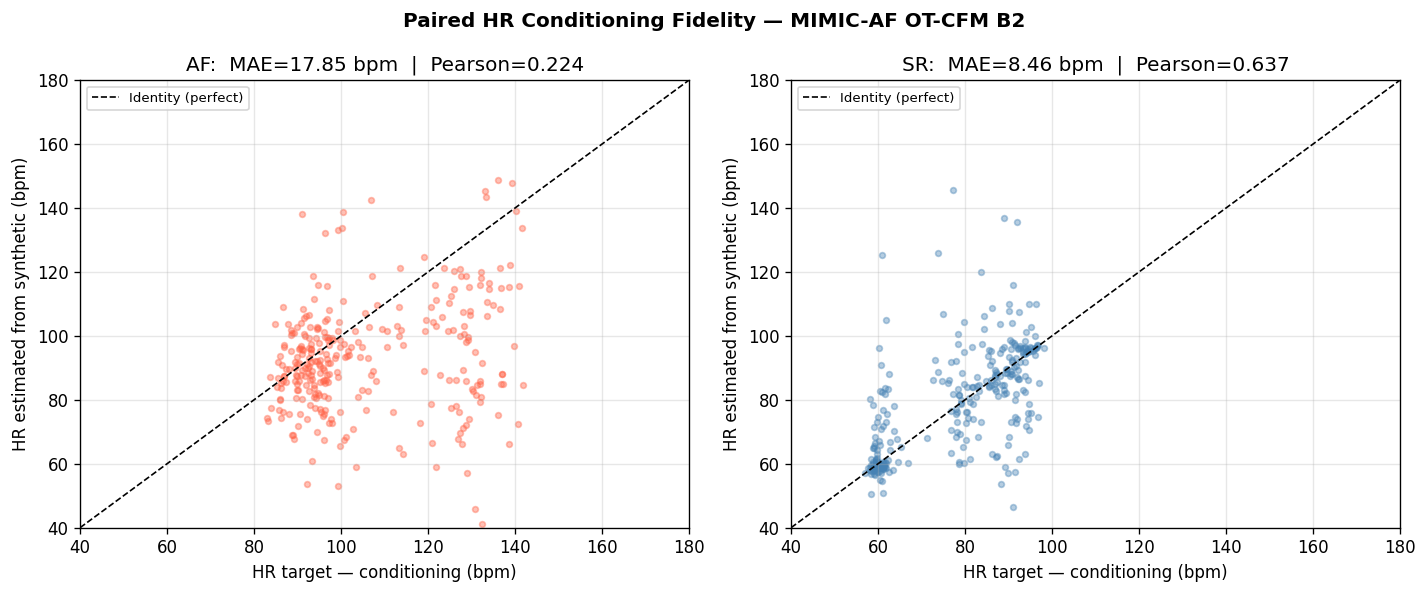


Pearson > 0.85 → model tracks HR target per sample.
Points below diagonal → systematic HR under-estimation
(expected in AF due to pulse deficit; in SR reflects IBI smoothing).


In [56]:
# ── §9b — Conditioning Fidelity (Paired) ─────────────────────────────────────
# Generates N_COND_EVAL fresh synthetics, each paired to the exact conditioning
# vector of one test-set row. This removes the misalignment artefact of the
# non-paired §9 cell (where eval_synth was generated from a different df_cls
# sample than the one used to compute hr_target).
#
# Key metrics:
#   MAE HR (paired)   : |HR_estimated_from_synthetic - HR_conditioning_target|
#                        per sample, then averaged.
#   IBI_std ratio      : IBI_std_synthetic / IBI_std_target  (ideal = 1.0)
#                        filtered to windows where IBI_std_target >= MIN_IBI_STD
#                        (excludes near-zero SR denominators).
#   Pearson (HR)       : correlation between HR_target and HR_synthetic,
#                        per sample — measures tracking, not just mean accuracy.

from scipy.signal import find_peaks as _fp

N_COND_EVAL = 300
MIN_IBI_STD = 0.01   # s — exclude near-zero SR denominators from ratio


def _est_hr_ibi_arr(signals, fs=FS):
    """Returns arrays (hrs, ibi_stds) with NaN for signals where detection fails."""
    hrs      = np.full(len(signals), np.nan)
    ibi_stds = np.full(len(signals), np.nan)
    for i, sig in enumerate(signals):
        try:
            peaks, _ = _fp(sig, distance=int(fs * 0.3), height=0.05)
            ibi = np.diff(peaks) / fs
            ibi = ibi[(ibi >= IBI_MIN) & (ibi <= IBI_MAX)]
            if len(ibi) >= 2:
                hrs[i]      = 60.0 / ibi.mean()
                ibi_stds[i] = float(ibi.std())
        except:
            pass
    return hrs, ibi_stds


print('Generating paired synthetics for conditioning fidelity...')
print(f'N_COND_EVAL={N_COND_EVAL}  ODE_STEPS={ODE_STEPS}  GS={BEST_GS}\n')

cond_paired = {}

for rh in ['AF', 'SR']:
    df_rh = (df_test[df_test['event_rhythm'] == rh]
             .sample(min(N_COND_EVAL, len(df_test[df_test['event_rhythm'] == rh])),
                     random_state=SEED)
             .reset_index(drop=True))

    hr_tgt      = 60.0 / df_rh['IBI_mean'].values   # bpm — from conditioning vector
    ibi_std_tgt = df_rh['IBI_std'].values            # s   — from conditioning vector
    n           = len(df_rh)

    nm, ns, nr = norm_ibi(df_rh['IBI_mean'].values,
                          df_rh['IBI_std'].values,
                          df_rh['RMSSD'].values)

    torch.cuda.empty_cache()
    cond_t = torch.tensor(build_cond(nm, ns, nr, rh),
                          dtype=torch.float32).to(DEVICE)
    chunks = []
    for i in range(0, len(cond_t), 64):
        chunks.append(
            heun_sample(ema_model, cond_t[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    synth_p = np.concatenate(chunks)   # (n, WIN_LEN)

    hrs_s, ibi_stds_s = _est_hr_ibi_arr(synth_p)
    valid = ~np.isnan(hrs_s)

    # ── MAE HR (paired) ───────────────────────────────────────────────────
    mae_hr   = float(np.nanmean(np.abs(hrs_s - hr_tgt)))
    mae_hr_s = float(np.nanstd(np.abs(hrs_s - hr_tgt)))

    # ── IBI_std ratio (filtered) ──────────────────────────────────────────
    ratio_mask = (ibi_std_tgt >= MIN_IBI_STD) & ~np.isnan(ibi_stds_s)
    if ratio_mask.sum() >= 5:
        ratio   = ibi_stds_s[ratio_mask] / ibi_std_tgt[ratio_mask]
        ratio_m = float(ratio.mean())
        ratio_s = float(ratio.std())
        n_ratio = int(ratio_mask.sum())
    else:
        ratio_m = ratio_s = float('nan'); n_ratio = 0

    # ── Pearson HR target vs synthetic (per sample) ───────────────────────
    valid_both = valid & (ibi_std_tgt > 0)
    pcc_hr = (float(np.corrcoef(hr_tgt[valid_both], hrs_s[valid_both])[0, 1])
              if valid_both.sum() >= 5 else float('nan'))

    cond_paired[rh] = dict(
        hr_tgt_mean  = hr_tgt.mean(),
        hr_syn_mean  = float(np.nanmean(hrs_s)),
        mae_hr       = mae_hr,
        mae_hr_std   = mae_hr_s,
        ibi_std_tgt  = ibi_std_tgt.mean(),
        ibi_std_syn  = float(np.nanmean(ibi_stds_s)),
        ratio_m      = ratio_m,
        ratio_s      = ratio_s,
        n_ratio      = n_ratio,
        pcc_hr       = pcc_hr,
        valid_pct    = 100 * valid.sum() / n,
        n            = n,
        hrs_s        = hrs_s,
        hr_tgt       = hr_tgt,
    )
    torch.cuda.empty_cache()
    print(f'  {rh}: {n} pairs  detect OK={valid.sum()} ({100*valid.sum()/n:.1f}%)  '
          f'MAE HR={mae_hr:.2f} bpm  IBI_std ratio={ratio_m:.3f} '
          f'(n={n_ratio}, excl. IBI_std<{MIN_IBI_STD}s)')

# ── Results table ────────────────────────────────────────────────────────────
print()
print('=' * 72)
print('  Conditioning Fidelity — Paired')
print('=' * 72)
print(f"  {'Metric':<36}  {'AF':>14}  {'SR':>14}")
print('  ' + '\u2500' * 68)
for label, key in [
        ('HR target           (bpm)',  'hr_tgt_mean'),
        ('HR synthetic        (bpm)',  'hr_syn_mean'),
        ('MAE HR — paired     (bpm)',  'mae_hr'),
        ('IBI_std target      (s)',    'ibi_std_tgt'),
        ('IBI_std synthetic   (s)',    'ibi_std_syn'),
        ('IBI_std ratio (filtered)',   'ratio_m'),
        ('Pearson HR tgt vs synth',    'pcc_hr'),
        ('Peak detect success (%)',    'valid_pct'),
]:
    af_v = cond_paired['AF'][key]
    sr_v = cond_paired['SR'][key]
    print(f"  {label:<36}  {af_v:>14.4f}  {sr_v:>14.4f}")
print('=' * 72)
print(f"  IBI_std ratio: computed on windows with IBI_std \u2265 {MIN_IBI_STD} s  "
      f"(AF n={cond_paired['AF']['n_ratio']}, SR n={cond_paired['SR']['n_ratio']})")

# ── Comparison: non-paired (§9) vs paired ────────────────────────────────────
try:
    print()
    print('\u2500' * 72)
    print('  Comparison: non-paired (\u00a79) vs paired')
    print('\u2500' * 72)
    print(f"  {'Metric':<36}  {'AF':>14}  {'SR':>14}")
    print(f"  {'MAE HR — non-paired (bpm)':<36}  "
          f"{results_cond['AF']['mae_hr']:>14.4f}  "
          f"{results_cond['SR']['mae_hr']:>14.4f}")
    print(f"  {'MAE HR — paired     (bpm)':<36}  "
          f"{cond_paired['AF']['mae_hr']:>14.4f}  "
          f"{cond_paired['SR']['mae_hr']:>14.4f}")
    print(f"  {'IBI_std ratio — non-paired':<36}  "
          f"{results_cond['AF']['ibi_std_ratio']:>14.4f}  "
          f"{results_cond['SR']['ibi_std_ratio']:>14.4f}")
    print(f"  {'IBI_std ratio — paired (filtered)':<36}  "
          f"{cond_paired['AF']['ratio_m']:>14.4f}  "
          f"{cond_paired['SR']['ratio_m']:>14.4f}")
    print('\u2500' * 72)
    print('MAE paired < non-paired \u2192 non-paired was inflated by sample misalignment.')
except NameError:
    print('(\u00a79 not run in this session \u2014 comparison skipped)')

# ── Scatter: HR target vs HR synthetic ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, rh in zip(axes, ['AF', 'SR']):
    r      = cond_paired[rh]
    hrs_s  = r['hrs_s']
    hr_tgt = r['hr_tgt']
    valid  = ~np.isnan(hrs_s)
    lims   = (40, 180)
    ax.scatter(hr_tgt[valid], hrs_s[valid],
               s=12, alpha=0.4,
               c='tomato' if rh == 'AF' else 'steelblue')
    ax.plot(lims, lims, 'k--', lw=1, label='Identity (perfect)')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('HR target — conditioning (bpm)')
    ax.set_ylabel('HR estimated from synthetic (bpm)')
    ax.set_title(f'{rh}:  MAE={r["mae_hr"]:.2f} bpm  |  '
                 f'Pearson={r["pcc_hr"]:.3f}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Paired HR Conditioning Fidelity — MIMIC-AF OT-CFM B2',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/fig_cond_fidelity_cfm_paired.png', dpi=150)
plt.show()
print()
print('Pearson > 0.85 \u2192 model tracks HR target per sample.')
print('Points below diagonal \u2192 systematic HR under-estimation')
print('(expected in AF due to pulse deficit; in SR reflects IBI smoothing).')


## §10 — Statistical Validation (t-SNE + Wasserstein)

Wasserstein distance (real vs synthetic):
Feature                  AF          SR
────────────────────────────────────────
  HR_mean            8.5561      5.4869
  HR_std             2.5988      7.5529
  Power_0-4Hz        0.0343      0.0561
  Power_4-8Hz        0.0015      0.0022
  RMS                0.0340      0.0424

Computing t-SNE...


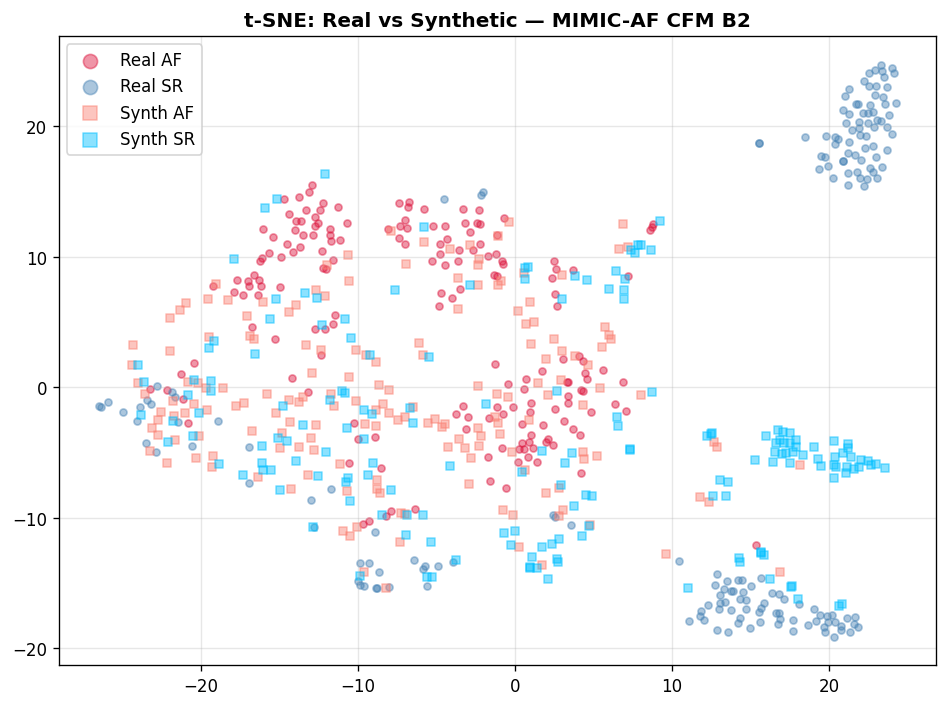

In [57]:
def feature_vec(signals):
    feats = []
    for sig in signals:
        try:
            peaks, _ = find_peaks(sig, distance=int(FS*0.3), height=0.1)
            hr_v  = [FS*60/d for d in np.diff(peaks) if 30 < FS*60/d < 200]
            hr_m  = np.mean(hr_v) if hr_v else 75.
            hr_s  = np.std(hr_v)  if len(hr_v) > 1 else 0.
        except:
            hr_m, hr_s = 75., 0.
        freq, pxx = welch(sig, fs=FS, nperseg=256)
        p_lo = np.trapezoid(pxx[(freq>=0)&(freq<4)], freq[(freq>=0)&(freq<4)])
        p_hi = np.trapezoid(pxx[(freq>=4)&(freq<8)], freq[(freq>=4)&(freq<8)])
        feats.append([hr_m, hr_s, p_lo, p_hi, np.sqrt(np.mean(sig**2))])
    return np.array(feats)

N_TSNE    = min(200, len(eval_real['AF']), len(eval_real['SR']))
feat_keys = ['real_AF','real_SR','synth_AF','synth_SR']
feats = {k: feature_vec(v[:N_TSNE]) for k, v in {
    'real_AF':  eval_real['AF'],  'real_SR':  eval_real['SR'],
    'synth_AF': eval_synth['AF'], 'synth_SR': eval_synth['SR']}.items()}

feat_names = ['HR_mean','HR_std','Power_0-4Hz','Power_4-8Hz','RMS']
print("Wasserstein distance (real vs synthetic):")
print(f"{'Feature':<15}  {'AF':>10}  {'SR':>10}")
print("─" * 40)
for i, fn in enumerate(feat_names):
    wa = wasserstein_distance(feats['real_AF'][:,i], feats['synth_AF'][:,i])
    ws = wasserstein_distance(feats['real_SR'][:,i], feats['synth_SR'][:,i])
    print(f"  {fn:<13}  {wa:>10.4f}  {ws:>10.4f}")

all_f  = np.concatenate([feats[k] for k in feat_keys])
all_l  = ['Real AF']*N_TSNE + ['Real SR']*N_TSNE + ['Synth AF']*N_TSNE + ['Synth SR']*N_TSNE
sc_all = StandardScaler().fit(all_f)
print("\nComputing t-SNE...")
emb = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=1000).fit_transform(sc_all.transform(all_f))

label_map = {'real_AF':'Real AF','real_SR':'Real SR','synth_AF':'Synth AF','synth_SR':'Synth SR'}
colours   = {'Real AF':'crimson','Real SR':'steelblue','Synth AF':'salmon','Synth SR':'deepskyblue'}
markers   = {'Real AF':'o','Real SR':'o','Synth AF':'s','Synth SR':'s'}

fig, ax = plt.subplots(figsize=(8, 6))
for key in ['real_AF','real_SR','synth_AF','synth_SR']:
    lbl2 = label_map[key]
    mask = [l == lbl2 for l in all_l]
    ax.scatter(emb[mask,0], emb[mask,1], c=colours[lbl2],
               marker=markers[lbl2], alpha=0.45, s=18, label=lbl2)
ax.set_title('t-SNE: Real vs Synthetic — MIMIC-AF CFM B2', fontweight='bold')
ax.legend(markerscale=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [58]:
from scipy.spatial.distance import pdist

def mmd_rbf(X, Y, gamma=None):
    """Maximum Mean Discrepancy (kernel RBF, estimador não-enviesado).
    gamma=None usa a heurística da mediana das distâncias par-a-par
    (combinando X e Y) para escolher a largura de banda do kernel.
    Menor MMD² = distribuições conjuntas mais parecidas.
    """
    X = np.atleast_2d(X); Y = np.atleast_2d(Y)
    if gamma is None:
        Z = np.vstack([X, Y])
        d2 = pdist(Z, 'sqeuclidean')
        med = np.median(d2)
        gamma = 1.0 / (med + 1e-8)

    def rbf(A, B):
        d2 = np.sum(A**2, 1)[:, None] + np.sum(B**2, 1)[None, :] - 2 * A @ B.T
        return np.exp(-gamma * np.clip(d2, 0, None))

    Kxx, Kyy, Kxy = rbf(X, X), rbf(Y, Y), rbf(X, Y)
    m, n = len(X), len(Y)
    sum_xx = (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1))
    sum_yy = (Kyy.sum() - np.trace(Kyy)) / (n * (n - 1))
    sum_xy = Kxy.sum() / (m * n)
    return float(sum_xx + sum_yy - 2 * sum_xy)


print("MMD² (features padronizadas, kernel RBF, menor = mais parecido):")
print(f"{'Classe':<10}  {'MMD²':>10}")
print("─" * 24)
sc_all = StandardScaler().fit(np.vstack([feats['real_AF'], feats['real_SR']]))
mmd_af = mmd_rbf(sc_all.transform(feats['real_AF']), sc_all.transform(feats['synth_AF']))
mmd_sr = mmd_rbf(sc_all.transform(feats['real_SR']), sc_all.transform(feats['synth_SR']))
print(f"  {'AF':<8}  {mmd_af:>10.5f}")
print(f"  {'SR':<8}  {mmd_sr:>10.5f}")


MMD² (features padronizadas, kernel RBF, menor = mais parecido):
Classe            MMD²
────────────────────────
  AF           0.08005
  SR           0.14487


In [59]:
DOWN_FACTOR = 5     # 1250 -> 250 amostras (FS efetiva ~25 Hz, > 2x8 Hz do passband)
DTW_BAND    = 25    # banda de Sakoe-Chiba, em amostras (após downsampling)
N_DTW       = 30    # amostras por classe — DTW é caro, mantido pequeno


def dtw_distance(a, b, band):
    """DTW com banda de Sakoe-Chiba (para tratabilidade). Distância elementar
    = |a_i - b_j|. Implementação simples em numpy/Python puro - sem
    dependências novas."""
    n, m = len(a), len(b)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        j_lo = max(1, i - band)
        j_hi = min(m, i + band)
        for j in range(j_lo, j_hi + 1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]


def dtw_nn_summary(real_sigs, synth_sigs, n=N_DTW, down=DOWN_FACTOR, band=DTW_BAND, seed=SEED):
    """Distância DTW do vizinho-mais-próximo (downsampled + banded).
    fidelidade = média, por sintético, da menor distância a um real
      (sintético -> real: os sinais gerados parecem-se com algum sinal real?)
    cobertura  = média, por real, da menor distância a um sintético
      (real -> sintético: os sinais reais estão bem representados no sintético?)
    """
    rng = np.random.RandomState(seed)
    idx_r = rng.choice(len(real_sigs),  min(n, len(real_sigs)),  replace=False)
    idx_s = rng.choice(len(synth_sigs), min(n, len(synth_sigs)), replace=False)
    R = [real_sigs[i][::down]  for i in idx_r]
    S = [synth_sigs[i][::down] for i in idx_s]

    D = np.zeros((len(S), len(R)))
    for i, s in enumerate(S):
        for j, r in enumerate(R):
            D[i, j] = dtw_distance(s, r, band)

    fidelity = float(D.min(axis=1).mean())
    coverage = float(D.min(axis=0).mean())
    return fidelity, coverage


print(f"DTW nearest-neighbour (N={N_DTW}/classe, downsample x{DOWN_FACTOR}, banda={DTW_BAND}):")
print(f"{'Classe':<10}  {'Fidelidade':>12}  {'Cobertura':>12}")
print("─" * 38)
fid_af, cov_af = dtw_nn_summary(eval_real['AF'], eval_synth['AF'])
fid_sr, cov_sr = dtw_nn_summary(eval_real['SR'], eval_synth['SR'])
print(f"  {'AF':<8}  {fid_af:>12.3f}  {cov_af:>12.3f}")
print(f"  {'SR':<8}  {fid_sr:>12.3f}  {cov_sr:>12.3f}")
print("\n(menor = mais parecido; fidelidade baixa e cobertura baixa juntas são o ideal)")


DTW nearest-neighbour (N=30/classe, downsample x5, banda=25):
Classe        Fidelidade     Cobertura
──────────────────────────────────────
  AF              31.698        29.744
  SR              30.191        23.917

(menor = mais parecido; fidelidade baixa e cobertura baixa juntas são o ideal)


In [60]:
# ── DTW nearest-neighbour com baseline Real vs Real ───────────────────────────
# Baseline: divide o conjunto real em dois grupos disjuntos e calcula DTW
# entre eles — quantifica a variabilidade morfológica natural inter-paciente.
# Interpretação: Fidelidade e Cobertura próximas da Baseline indicam que os
# sintéticos são tão variáveis entre si quanto os próprios sinais reais.

def dtw_nn_baseline(real_sigs, n=N_DTW, down=DOWN_FACTOR,
                    band=DTW_BAND, seed=SEED):
    """
    Real vs Real baseline: divide o dataset real em dois grupos disjuntos
    e calcula DTW entre eles. Evita comparar um sinal consigo mesmo.
    Devolve a média de fidelidade e cobertura como valor de referência.
    """
    rng     = np.random.RandomState(seed)
    k       = min(n, len(real_sigs) // 2)
    indices = rng.choice(len(real_sigs), 2 * k, replace=False)
    real_A  = [real_sigs[i] for i in indices[:k]]
    real_B  = [real_sigs[i] for i in indices[k:]]
    fid, cov = dtw_nn_summary(real_A, real_B, n=k,
                               down=down, band=band, seed=seed)
    return (fid + cov) / 2


# ── Calcular baseline por classe ──────────────────────────────────────────────
print(f"Computing DTW baselines (Real vs Real)...")
base_af = dtw_nn_baseline(eval_real['AF'])
base_sr = dtw_nn_baseline(eval_real['SR'])
print(f"  AF baseline: {base_af:.3f}")
print(f"  SR baseline: {base_sr:.3f}")

# ── Calcular DTW sintético vs real ────────────────────────────────────────────
print(f"\nDTW nearest-neighbour — CFM (Heun, {ODE_STEPS} steps, gs={BEST_GS})")
print(f"N={N_DTW}/classe  downsample x{DOWN_FACTOR}  banda={DTW_BAND}\n")

fid_af, cov_af = dtw_nn_summary(eval_real['AF'], eval_synth['AF'])
fid_sr, cov_sr = dtw_nn_summary(eval_real['SR'], eval_synth['SR'])

print(f"  {'Classe':<8}  {'Fidelidade':>12}  {'Cobertura':>12}  "
      f"{'Baseline (R\u2194R)':>16}")
print("  " + "─" * 54)
print(f"  {'AF':<8}  {fid_af:>12.3f}  {cov_af:>12.3f}  {base_af:>16.3f}")
print(f"  {'SR':<8}  {fid_sr:>12.3f}  {cov_sr:>12.3f}  {base_sr:>16.3f}")

print()
print("Overhead vs baseline:")
print(f"  AF — Fidelidade: {fid_af - base_af:+.3f}  "
      f"Cobertura: {cov_af - base_af:+.3f}")
print(f"  SR — Fidelidade: {fid_sr - base_sr:+.3f}  "
      f"Cobertura: {cov_sr - base_sr:+.3f}")
print()
print("(overhead próximo de 0 → sintéticos tão variáveis quanto sinais reais entre si)")
print("(menor Fidelidade e Cobertura são melhores; Baseline é o piso natural)")

Computing DTW baselines (Real vs Real)...
  AF baseline: 28.749
  SR baseline: 23.864

DTW nearest-neighbour — CFM (Heun, 100 steps, gs=0.5)
N=30/classe  downsample x5  banda=25

  Classe      Fidelidade     Cobertura    Baseline (R↔R)
  ──────────────────────────────────────────────────────
  AF              31.698        29.744            28.749
  SR              30.191        23.917            23.864

Overhead vs baseline:
  AF — Fidelidade: +2.949  Cobertura: +0.995
  SR — Fidelidade: +6.327  Cobertura: +0.054

(overhead próximo de 0 → sintéticos tão variáveis quanto sinais reais entre si)
(menor Fidelidade e Cobertura são melhores; Baseline é o piso natural)


## §11 — Functional Evaluation (TRTR / TSTR / Classifier-B)
1D-CNN binary classifier evaluated on real test set.
Metrics: AUROC, Precision, F1-score (5 seeds each).
Threshold optimised on validation set (not test set).


In [61]:
from sklearn.metrics import confusion_matrix
class Clf1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,32,15,stride=2,padding=7),  nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32,64,9,stride=2,padding=4),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64,128,7,stride=2,padding=3), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128,256,5,stride=4,padding=2),nn.BatchNorm1d(256), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(256,64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64,1))
    def forward(self, x): return self.net(x).squeeze(1)


def find_best_threshold(y_true, probs, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y_true, (probs > t).astype(int), zero_division=0) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return float(thresholds[best_idx]), float(f1s[best_idx])


def train_clf(Xtr, ytr, Xvl, yvl, epochs=30, lr=1e-3, batch=128):
    clf = Clf1D().to(DEVICE)
    opt = torch.optim.Adam(clf.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    pos_weight = torch.tensor([len(ytr[ytr==0]) / len(ytr[ytr==1])],
                               dtype=torch.float32).to(DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    Xt = torch.tensor(Xtr[:,None,:], dtype=torch.float32)
    yt = torch.tensor(ytr, dtype=torch.float32)
    Xv = torch.tensor(Xvl[:,None,:], dtype=torch.float32)
    dl = DataLoader(list(zip(Xt, yt)), batch_size=batch, shuffle=True)
    best_auc, best_state = 0., None
    for ep in range(epochs):
        clf.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); crit(clf(xb), yb).backward(); opt.step()
        sch.step()
        clf.eval()
        with torch.no_grad():
            log = clf(Xv.to(DEVICE)).cpu().numpy()
        auc = roc_auc_score(yvl, log)
        if auc > best_auc:
            best_auc   = auc
            best_state = {k: v.clone() for k, v in clf.state_dict().items()}
    clf.load_state_dict(best_state)
    clf.eval()
    with torch.no_grad():
        val_log = clf(Xv.to(DEVICE)).cpu().numpy()
    val_probs = 1 / (1 + np.exp(-val_log))
    best_thr, _ = find_best_threshold(yvl, val_probs)
    return clf, best_thr


#def eval_clf(clf, Xte, yte, threshold=0.5):
#    clf.eval()
#    with torch.no_grad():
#        log = clf(torch.tensor(Xte[:,None,:], dtype=torch.float32).to(DEVICE)).cpu().numpy()
#    probs = 1 / (1 + np.exp(-log))
#    preds = (probs > threshold).astype(int)
#    return {'auroc': roc_auc_score(yte, log),
#            'precision': precision_score(yte, preds, zero_division=0),
#            'f1': f1_score(yte, preds, zero_division=0)}

def eval_clf(clf, Xte, yte, threshold=0.5):
    """Avalia o classificador — reporta AUROC, Precision e F1."""
    clf.eval()
    with torch.no_grad():
        log = clf(torch.tensor(
            Xte[:,None,:], dtype=torch.float32).to(DEVICE)).cpu().numpy()
    probs = 1 / (1 + np.exp(-log))
    preds = (probs > threshold).astype(int)
    return {
        'auroc':     roc_auc_score(yte, log),
        'precision': precision_score(yte, preds, zero_division=0),
        'f1':        f1_score(yte, preds, zero_division=0),
    }

def load_fold(df_fold, max_per_class=None):
    signals, labels = [], []
    for rh, lbl in [('AF',1), ('SR',0)]:
        sub = df_fold[df_fold['event_rhythm'] == rh]
        if max_per_class:
            sub = sub.sample(min(max_per_class, len(sub)), random_state=SEED)
        for _, row in sub.iterrows():
            sig = load_ppg(row['csv_path'], int(row['start_sample']))
            if sig is not None: signals.append(sig); labels.append(lbl)
    return np.array(signals), np.array(labels)


print("Loading real signals for all folds...")
X_tr, y_tr = load_fold(df_train, max_per_class=1000)
X_vl, y_vl = load_fold(df_val)
X_te, y_te = load_fold(df_test)
print(f"Train: {X_tr.shape} | Val: {X_vl.shape} | Test: {X_te.shape}")

print("\nGenerating synthetics for TSTR (1000/class, 50 steps)...")
N_SYN, STEPS_SYN = 1000, 50
synth_tr = {}
for rh in ['AF', 'SR']:
    df_cls = df_train[df_train['event_rhythm'] == rh].sample(
        min(N_SYN, len(df_train[df_train['event_rhythm'] == rh])), random_state=SEED)
    nm, ns, nr = norm_ibi(df_cls['IBI_mean'].values,
                           df_cls['IBI_std'].values,
                           df_cls['RMSSD'].values)
    cond = torch.tensor(build_cond(nm, ns, nr, rh), dtype=torch.float32).to(DEVICE)
    out  = []
    for i in range(0, len(cond), 64):
        out.append(heun_sample(ema_model, cond[i:i+64], STEPS_SYN, BEST_GS).cpu().numpy().squeeze(1))
    synth_tr[rh] = np.concatenate(out)
    print(f"  {rh}: {synth_tr[rh].shape[0]}")

X_syn = np.concatenate([synth_tr['AF'], synth_tr['SR']])
y_syn = np.array([1]*len(synth_tr['AF']) + [0]*len(synth_tr['SR']))


Loading real signals for all folds...
Train: (1986, 1250) | Val: (1195, 1250) | Test: (1260, 1250)

Generating synthetics for TSTR (1000/class, 50 steps)...
  AF: 1000
  SR: 1000


In [62]:
N_SEEDS = 5
results = {}

for condition, Xtr, ytr in [('TRTR', X_tr, y_tr),
                              ('TSTR', X_syn, y_syn),
                              ('ClfB', np.vstack([X_tr, X_syn]),
                                       np.concatenate([y_tr, y_syn]))]:
    print(f"\n{condition} — {N_SEEDS} seeds...")
    metrics_list = {'auroc': [], 'precision': [], 'f1': [], 'threshold': []}

    for s in range(N_SEEDS):
        torch.manual_seed(s); np.random.seed(s)
        clf, thr = train_clf(Xtr, ytr, X_vl, y_vl)
        m        = eval_clf(clf, X_te, y_te, threshold=thr)
        m['threshold'] = thr
        for k in metrics_list:
            metrics_list[k].append(m[k])
        print(f"  seed {s}: thr={thr:.2f}  "
              f"AUROC={m['auroc']:.4f}  "
              f"Precision={m['precision']:.4f}  "
              f"F1={m['f1']:.4f}")

    results[condition] = {k: (np.mean(v), np.std(v))
                          for k, v in metrics_list.items()}
    mu = results[condition]
    print(f"  -> AUROC={mu['auroc'][0]:.4f}±{mu['auroc'][1]:.4f}"
          f"  Precision={mu['precision'][0]:.4f}±{mu['precision'][1]:.4f}"
          f"  F1={mu['f1'][0]:.4f}±{mu['f1'][1]:.4f}")

print()
print("=" * 72)
print("  Functional Evaluation Summary  (optimal val-set threshold, 5 seeds)")
print("=" * 72)
print(f"  {'Cond':<6}  {'AUROC':>18}  {'Precision':>18}  {'F1':>18}")
print("  " + "─" * 66)
for cond, m in results.items():
    print(f"  {cond:<6}  "
          f"{m['auroc'][0]:.4f}±{m['auroc'][1]:.4f}  "
          f"{m['precision'][0]:.4f}±{m['precision'][1]:.4f}  "
          f"{m['f1'][0]:.4f}±{m['f1'][1]:.4f}")
print("=" * 72)
print(f"\nGap TSTR vs TRTR: "
      f"AUROC {results['TSTR']['auroc'][0]-results['TRTR']['auroc'][0]:+.4f}  "
      f"F1 {results['TSTR']['f1'][0]-results['TRTR']['f1'][0]:+.4f}")
print(f"Gap ClfB vs TRTR: "
      f"AUROC {results['ClfB']['auroc'][0]-results['TRTR']['auroc'][0]:+.4f}  "
      f"F1 {results['ClfB']['f1'][0]-results['TRTR']['f1'][0]:+.4f}")


TRTR — 5 seeds...
  seed 0: thr=0.75  AUROC=0.4491  Precision=0.5376  F1=0.6481
  seed 1: thr=0.17  AUROC=0.3796  Precision=0.4947  F1=0.5727
  seed 2: thr=0.88  AUROC=0.5665  Precision=0.6039  F1=0.7272
  seed 3: thr=0.16  AUROC=0.3770  Precision=0.5324  F1=0.6212
  seed 4: thr=0.70  AUROC=0.4328  Precision=0.5529  F1=0.6596
  -> AUROC=0.4410±0.0689  Precision=0.5443±0.0354  F1=0.6457±0.0505

TSTR — 5 seeds...
  seed 0: thr=0.01  AUROC=0.4847  Precision=0.5399  F1=0.6983
  seed 1: thr=0.01  AUROC=0.5155  Precision=0.5374  F1=0.6933
  seed 2: thr=0.01  AUROC=0.3527  Precision=0.4983  F1=0.6236
  seed 3: thr=0.01  AUROC=0.3990  Precision=0.5421  F1=0.7024
  seed 4: thr=0.01  AUROC=0.5075  Precision=0.5396  F1=0.6977
  -> AUROC=0.4519±0.0646  Precision=0.5315±0.0167  F1=0.6831±0.0299

ClfB — 5 seeds...
  seed 0: thr=0.01  AUROC=0.3804  Precision=0.5098  F1=0.6437
  seed 1: thr=0.15  AUROC=0.5317  Precision=0.5423  F1=0.7014
  seed 2: thr=0.04  AUROC=0.4923  Precision=0.5277  F1=0.6744
 

## §12 — Results Summary

In [63]:
print("=" * 60)
print("  MIMIC-AF CFM B2 — Results Summary")
print("=" * 60)
print(f"  Dataset:   MIMIC PERform AF  ({df['subject_id'].nunique()} subjects)")
print(f"  Windows:   {len(df_ibi):,} × 10s  (after physiological filter)")
print(f"  Train/Val/Test subjects: {len(TRAIN_SIDS)}/{len(VAL_SIDS)}/{len(TEST_SIDS)}")
print()
print(f"  Best val loss:      {best_val_loss:.4f}")
print(f"  Best guidance:      {BEST_GS}")
print()
print(f"  LSD (0.5-8 Hz):     AF={lsd_af:.2f} dB  SR={lsd_sr:.2f} dB")
print()
for cond, m in results.items():
    print(f"  {cond}  AUROC={m['auroc'][0]:.4f}±{m['auroc'][1]:.4f}"
          f"  F1={m['f1'][0]:.4f}±{m['f1'][1]:.4f}")
print("=" * 60)


  MIMIC-AF CFM B2 — Results Summary
  Dataset:   MIMIC PERform AF  (34 subjects)
  Windows:   8,029 × 10s  (after physiological filter)
  Train/Val/Test subjects: 23/5/6

  Best val loss:      0.1280
  Best guidance:      0.5

  LSD (0.5-8 Hz):     AF=5.56 dB  SR=8.57 dB

  TRTR  AUROC=0.4410±0.0689  F1=0.6457±0.0505
  TSTR  AUROC=0.4519±0.0646  F1=0.6831±0.0299
  ClfB  AUROC=0.4188±0.0840  F1=0.6742±0.0204


In [64]:
from sklearn.metrics import (roc_auc_score, precision_score,
                              f1_score, accuracy_score, confusion_matrix)

# ── Classifier architecture ───────────────────────────────────────────────────
# Adapted from U-Net GAN paper (Section 3.4):
#   - 6-layer CNN, filters=[4,8,16,32,64,128], kernel=3
#   - Leaky ReLU alpha=0.15
#   - Global average pooling → fully connected → 2 classes (softmax via CE loss)
#   - Original: 1500-sample input (100Hz × 15s)
#   - Here:     1250-sample input (125Hz × 10s) — same architecture, adapted length

class ClfUNetGAN(nn.Module):
    def __init__(self):
        super().__init__()
        filters = [1, 4, 8, 16, 32, 64, 128]
        layers  = []
        for i in range(len(filters) - 1):
            layers += [
                nn.Conv1d(filters[i], filters[i+1],
                          kernel_size=3, padding=1),
                nn.LeakyReLU(0.15),
            ]
        layers.append(nn.AdaptiveAvgPool1d(1))
        layers.append(nn.Flatten())
        self.features    = nn.Sequential(*layers)
        self.classifier  = nn.Linear(128, 2)

    def forward(self, x):
        return self.classifier(self.features(x))   # logits (B, 2)

In [65]:
# ── Training & evaluation helpers ────────────────────────────────────────────

def train_clf_unetgan(Xtr, ytr, Xvl, yvl,
                      epochs=30, lr=1e-3, batch=128):
    """Train ClfUNetGAN with CrossEntropyLoss (matches original paper)."""
    clf = ClfUNetGAN().to(DEVICE)
    opt = torch.optim.Adam(clf.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.CrossEntropyLoss()

    Xt = torch.tensor(Xtr[:, None, :], dtype=torch.float32)
    yt = torch.tensor(ytr, dtype=torch.long)
    Xv = torch.tensor(Xvl[:, None, :], dtype=torch.float32)
    dl = DataLoader(list(zip(Xt, yt)), batch_size=batch, shuffle=True)

    best_auc, best_state = 0., None
    for ep in range(epochs):
        clf.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(clf(xb), yb).backward()
            opt.step()
        sch.step()
        clf.eval()
        with torch.no_grad():
            logits = clf(Xv.to(DEVICE)).cpu().numpy()
        probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
        auc   = roc_auc_score(yvl, probs)
        if auc > best_auc:
            best_auc   = auc
            best_state = {k: v.clone() for k, v in clf.state_dict().items()}

    clf.load_state_dict(best_state)
    # Threshold selection on validation set (max F1)
    clf.eval()
    with torch.no_grad():
        logits_v = clf(Xv.to(DEVICE)).cpu().numpy()
    probs_v   = torch.softmax(torch.tensor(logits_v), dim=1).numpy()[:, 1]
    best_thr, _ = find_best_threshold(yvl, probs_v)   # reuse from §11
    return clf, best_thr


def eval_clf_unetgan(clf, Xte, yte, threshold=0.5):
    """Evaluate ClfUNetGAN — returns all metrics from U-Net GAN paper."""
    clf.eval()
    with torch.no_grad():
        logits = clf(torch.tensor(
            Xte[:, None, :], dtype=torch.float32).to(DEVICE)).cpu().numpy()
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = (probs > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(yte, preds, labels=[0, 1]).ravel()
    return {
        'accuracy':    accuracy_score(yte, preds),
        'auroc':       roc_auc_score(yte, probs),
        'precision':   precision_score(yte, preds, zero_division=0),
        'recall':      float(tp / (tp + fn)) if (tp + fn) > 0 else 0.,  # = Sensitivity
        'sensitivity': float(tp / (tp + fn)) if (tp + fn) > 0 else 0.,
        'specificity': float(tn / (tn + fp)) if (tn + fp) > 0 else 0.,
        'f1':          f1_score(yte, preds, zero_division=0),
    }

In [66]:
# ── Generate synthetic segments ───────────────────────────────────────────────
# Generate a pool of synthetic AF and SR from training set conditioning

N_SYNTH_POOL = 3200   # larger pool to allow flexible dataset construction
print(f"Generating synthetic pool ({N_SYNTH_POOL} AF + {N_SYNTH_POOL} SR)...")

synth_pool = {}
for rh in ['AF', 'SR']:
    df_cls = df_train[df_train['event_rhythm'] == rh].sample(
        min(N_SYNTH_POOL, len(df_train[df_train['event_rhythm'] == rh])),
        random_state=SEED)
    nm, ns, nr = norm_ibi(df_cls['IBI_mean'].values,
                           df_cls['IBI_std'].values,
                           df_cls['RMSSD'].values)
    cond = torch.tensor(build_cond(nm, ns, nr, rh),
                        dtype=torch.float32).to(DEVICE)
    out  = []
    for i in range(0, len(cond), 64):
        out.append(heun_sample(ema_model, cond[i:i+64],
                               ODE_STEPS, BEST_GS).cpu().numpy().squeeze(1))
    synth_pool[rh] = np.concatenate(out)
    print(f"  {rh}: {synth_pool[rh].shape[0]} synthetic segments")

Generating synthetic pool (3200 AF + 3200 SR)...
  AF: 3103 synthetic segments
  SR: 2384 synthetic segments


In [67]:
# ── Real signal pool ──────────────────────────────────────────────────────────
print("\nLoading real signal pools...")
real_pool = {}
for rh, lbl in [('AF', 1), ('SR', 0)]:
    df_cls = df_train[df_train['event_rhythm'] == rh]
    sigs   = [load_ppg(r['csv_path'], int(r['start_sample']))
              for _, r in df_cls.iterrows()]
    sigs   = np.array([s for s in sigs if s is not None], dtype=np.float32)
    real_pool[rh] = sigs
    print(f"  Real {rh}: {len(sigs)} segments")

# Validation and test sets (fixed across all datasets)
X_vl_g = np.array([load_ppg(r['csv_path'], int(r['start_sample']))
                    for _, r in df_val.iterrows()
                    if load_ppg(r['csv_path'], int(r['start_sample'])) is not None],
                   dtype=np.float32)
y_vl_g  = df_val['event_rhythm'].map({'AF': 1, 'SR': 0}).values[:len(X_vl_g)]

X_te_g  = np.array([load_ppg(r['csv_path'], int(r['start_sample']))
                     for _, r in df_test.iterrows()
                     if load_ppg(r['csv_path'], int(r['start_sample'])) is not None],
                    dtype=np.float32)
y_te_g  = df_test['event_rhythm'].map({'AF': 1, 'SR': 0}).values[:len(X_te_g)]

print(f"\nVal:  {X_vl_g.shape} | Test: {X_te_g.shape}")


Loading real signal pools...
  Real AF: 3064 segments
  Real SR: 2374 segments

Val:  (1195, 1250) | Test: (1260, 1250)


In [68]:
# ── Dataset construction ──────────────────────────────────────────────────────
# Use N = min(real_AF, real_SR) as the balanced unit
N_UNIT = min(len(real_pool['AF']), len(real_pool['SR']),
             len(synth_pool['AF']), len(synth_pool['SR']))
print(f"\nBalancing unit N = {N_UNIT} segments per class")

rng = np.random.default_rng(SEED)

def sample_n(arr, n, rng):
    idx = rng.choice(len(arr), min(n, len(arr)), replace=False)
    return arr[idx]

# Dataset 1: 50% synthetic AF + 50% real SR
# → TSTR-like: no real AF in training, tests if synthetics alone are useful
d1_X = np.vstack([sample_n(synth_pool['AF'], N_UNIT, rng),
                  sample_n(real_pool['SR'],   N_UNIT, rng)])
d1_y = np.array([1]*N_UNIT + [0]*N_UNIT)

# Dataset 2: 25% synthetic AF + 25% real AF + 50% real SR
# → Mixed augmentation: half the AF from synthetic
N_HALF = N_UNIT // 2
d2_X = np.vstack([sample_n(synth_pool['AF'],  N_HALF, rng),
                  sample_n(real_pool['AF'],    N_HALF, rng),
                  sample_n(real_pool['SR'],    N_UNIT, rng)])
d2_y = np.array([1]*N_HALF + [1]*N_HALF + [0]*N_UNIT)

# Dataset 3: 50% real AF + 50% synthetic SR
# → Tests if synthetic SR (non-AF) is useful when real SR is limited
d3_X = np.vstack([sample_n(real_pool['AF'],   N_UNIT, rng),
                  sample_n(synth_pool['SR'],   N_UNIT, rng)])
d3_y = np.array([1]*N_UNIT + [0]*N_UNIT)

# Dataset 4: 50% real AF + 50% real SR (TRTR baseline)
# → Pure real data — this is the baseline to beat
d4_X = np.vstack([sample_n(real_pool['AF'],   N_UNIT, rng),
                  sample_n(real_pool['SR'],    N_UNIT, rng)])
d4_y = np.array([1]*N_UNIT + [0]*N_UNIT)

# Dataset 5: 75% real AF + 25% real SR
# → Imbalanced real — tests classifier robustness to class imbalance
N_75 = int(N_UNIT * 1.5)
N_25 = N_UNIT // 2
d5_X = np.vstack([sample_n(real_pool['AF'],   N_75, rng),
                  sample_n(real_pool['SR'],    N_25, rng)])
d5_y = np.array([1]*N_75 + [0]*N_25)

datasets = {
    'D1 — 50% synth AF + 50% real SR':          (d1_X, d1_y),
    'D2 — 25% synth AF + 25% real AF + 50% SR': (d2_X, d2_y),
    'D3 — 50% real AF + 50% synth SR':           (d3_X, d3_y),
    'D4 — 50% real AF + 50% real SR (baseline)': (d4_X, d4_y),
    'D5 — 75% real AF + 25% real SR (imbal.)':   (d5_X, d5_y),
}

print(f"\nDataset sizes:")
for name, (X, y) in datasets.items():
    print(f"  {name}: {len(X)} segs  "
          f"(AF={y.sum()}, SR={(y==0).sum()})")


Balancing unit N = 2374 segments per class

Dataset sizes:
  D1 — 50% synth AF + 50% real SR: 4748 segs  (AF=2374, SR=2374)
  D2 — 25% synth AF + 25% real AF + 50% SR: 4748 segs  (AF=2374, SR=2374)
  D3 — 50% real AF + 50% synth SR: 4748 segs  (AF=2374, SR=2374)
  D4 — 50% real AF + 50% real SR (baseline): 4748 segs  (AF=2374, SR=2374)
  D5 — 75% real AF + 25% real SR (imbal.): 4251 segs  (AF=3561, SR=1187)


In [69]:
# ── Run evaluation ────────────────────────────────────────────────────────────
N_SEEDS   = 5
results2  = {}

print(f"\nTraining ClfUNetGAN on each dataset ({N_SEEDS} seeds)...")
print("=" * 70)

for ds_name, (Xtr, ytr) in datasets.items():
    print(f"\n{ds_name}")
    metrics_list = {k: [] for k in
                    ['accuracy','auroc','precision','recall',
                     'sensitivity','specificity','f1','threshold']}
    for s in range(N_SEEDS):
        torch.manual_seed(s); np.random.seed(s)
        clf, thr = train_clf_unetgan(Xtr, ytr, X_vl_g, y_vl_g)
        m = eval_clf_unetgan(clf, X_te_g, y_te_g, threshold=thr)
        m['threshold'] = thr
        for k in metrics_list:
            metrics_list[k].append(m[k])
        print(f"  seed {s}: Acc={m['accuracy']:.4f}  "
              f"AUROC={m['auroc']:.4f}  "
              f"Prec={m['precision']:.4f}  "
              f"Rec={m['recall']:.4f}  "
              f"F1={m['f1']:.4f}  "
              f"thr={thr:.2f}")
    results2[ds_name] = {k: (float(np.mean(v)), float(np.std(v)))
                         for k, v in metrics_list.items()}
    mu = results2[ds_name]
    print(f"  -> AUROC={mu['auroc'][0]:.4f}±{mu['auroc'][1]:.4f}"
          f"  Acc={mu['accuracy'][0]:.4f}±{mu['accuracy'][1]:.4f}"
          f"  F1={mu['f1'][0]:.4f}±{mu['f1'][1]:.4f}")




Training ClfUNetGAN on each dataset (5 seeds)...

D1 — 50% synth AF + 50% real SR
  seed 0: Acc=0.6849  AUROC=0.6290  Prec=0.6536  Rec=0.8981  F1=0.7566  thr=0.23
  seed 1: Acc=0.5452  AUROC=0.4995  Prec=0.5452  Rec=1.0000  F1=0.7057  thr=0.01
  seed 2: Acc=0.6865  AUROC=0.6321  Prec=0.6543  Rec=0.9010  F1=0.7581  thr=0.23
  seed 3: Acc=0.6873  AUROC=0.6297  Prec=0.6560  Rec=0.8967  F1=0.7577  thr=0.24
  seed 4: Acc=0.6794  AUROC=0.6176  Prec=0.6543  Rec=0.8734  F1=0.7481  thr=0.19
  -> AUROC=0.6016±0.0513  Acc=0.6567±0.0558  F1=0.7452±0.0201

D2 — 25% synth AF + 25% real AF + 50% SR
  seed 0: Acc=0.6865  AUROC=0.6302  Prec=0.6537  Rec=0.9039  F1=0.7587  thr=0.20
  seed 1: Acc=0.5508  AUROC=0.5323  Prec=0.5883  Rec=0.5866  F1=0.5875  thr=0.48
  seed 2: Acc=0.6905  AUROC=0.6408  Prec=0.6565  Rec=0.9068  F1=0.7616  thr=0.25
  seed 3: Acc=0.6913  AUROC=0.6390  Prec=0.6578  Rec=0.9039  F1=0.7615  thr=0.26
  seed 4: Acc=0.6857  AUROC=0.6303  Prec=0.6536  Rec=0.9010  F1=0.7576  thr=0.24
  -

In [70]:
# ── Results table ─────────────────────────────────────────────────────────────
print()
print("=" * 110)
print("  Functional Validation 2 — ClfUNetGAN  "
      "(adapted from U-Net GAN paper, 5 seeds, optimal val threshold)")
print("=" * 110)
print(f"  {'Dataset':<44}  {'Accuracy':>12}  {'AUROC':>12}  "
      f"{'Precision':>12}  {'Recall/Sens':>12}  {'Specificity':>12}  {'F1':>10}")
print("  " + "─" * 104)

for ds_name, m in results2.items():
    print(f"  {ds_name:<44}  "
          f"{m['accuracy'][0]:.4f}±{m['accuracy'][1]:.3f}  "
          f"{m['auroc'][0]:.4f}±{m['auroc'][1]:.3f}  "
          f"{m['precision'][0]:.4f}±{m['precision'][1]:.3f}  "
          f"{m['recall'][0]:.4f}±{m['recall'][1]:.3f}  "
          f"{m['specificity'][0]:.4f}±{m['specificity'][1]:.3f}  "
          f"{m['f1'][0]:.4f}±{m['f1'][1]:.3f}")

print("=" * 110)
print(f"\nNote: Recall = Sensitivity = TP/(TP+FN)")
print(f"D4 is the real-only baseline (equivalent to TRTR in §11).")
print(f"Comparison with U-Net GAN paper: same classifier architecture,")
print(f"same dataset split logic — different generative model and dataset.")


  Functional Validation 2 — ClfUNetGAN  (adapted from U-Net GAN paper, 5 seeds, optimal val threshold)
  Dataset                                           Accuracy         AUROC     Precision   Recall/Sens   Specificity          F1
  ────────────────────────────────────────────────────────────────────────────────────────────────────────
  D1 — 50% synth AF + 50% real SR               0.6567±0.056  0.6016±0.051  0.6327±0.044  0.9138±0.044  0.3483±0.174  0.7452±0.020
  D2 — 25% synth AF + 25% real AF + 50% SR      0.6610±0.055  0.6145±0.041  0.6420±0.027  0.8405±0.127  0.4457±0.031  0.7254±0.069
  D3 — 50% real AF + 50% synth SR               0.5452±0.000  0.7129±0.026  0.5452±0.000  1.0000±0.000  0.0000±0.000  0.7057±0.000
  D4 — 50% real AF + 50% real SR (baseline)     0.6592±0.057  0.6096±0.057  0.6324±0.044  0.9252±0.038  0.3403±0.170  0.7491±0.022
  D5 — 75% real AF + 25% real SR (imbal.)       0.5933±0.099  0.5506±0.097  0.5869±0.075  0.7706±0.261  0.3808±0.203  0.6510±0.156

Note

## Functional Validation 3 — Cross-Domain: VitalDB AF

Mirrors Functional Validation 2 but now uses **real VitalDB AFIB/AFL PPG windows** as the source of conditioning features, never seen during training. This matches the experimental design of the reference GAN paper, where the Long-Term ECG dataset serves the same cross-domain role.

**FV3 is split into two parts:**
- **Part A — Fidelity:** LSD, Wasserstein, MMD, DTW and t-SNE comparing real VitalDB AF against synthetics generated from VitalDB conditioning vectors
- **Part B — Classifier:** ClfUNetGAN trained on VitalDB-conditioned synthetics (same structure as FV2), tested on two test sets:
  1. MIMIC-AF real test set (direct comparability with FV2)
  2. Cross-domain test set: real VitalDB AF + MIMIC-AF SR (pure cross-domain generalization)

---
**Preprocessing note:** The VitalDB pipeline outputs z-score-normalised PPG. The MIMIC-AF model was trained on min-max normalised PPG ([-1, 1]). Before any comparison, VitalDB real windows are rescaled per-window to [-1, 1] (same transform as `load_ppg()`). Generated synthetics are already in the model output space ([-1, 1]).

**Conditioning note:** VitalDB IBI features (seconds) are normalised with the **MIMIC-AF training-set statistics** (`IBI_MEAN_MU`, `IBI_STD_MU`, `RMSSD_MU`, etc.) computed in §3. Fitting a new scaler on VitalDB would leak cross-domain distributional information into the generator.

### FV3-A — Fidelity Evaluation (LSD · Wasserstein · MMD · DTW · t-SNE)

In [71]:
from pathlib import Path

VITALDB_OUT = Path('/kaggle/input/datasets/vegatronxz/vitaldb-af-dataset')
#/kaggle/input/datasets/vegatronxz/vitaldb-af-dataset/vitaldb_af_dataset/ppg_windows.npy

ppg_vdb_raw  = np.load(VITALDB_OUT / 'vitaldb_af_dataset/ppg_windows.npy')       # (N,1250) z-scored
meta_vdb     = pd.read_csv(VITALDB_OUT / 'vitaldb_af_dataset/metadata_windows.csv')

print(f'VitalDB AF windows  : {ppg_vdb_raw.shape}')
print(f'Metadata rows       : {len(meta_vdb)}')
print(f'Cases with windows  : {meta_vdb["case_id"].nunique()}')
print()
print('Conditioning feature statistics (VitalDB, raw seconds):')
print(meta_vdb[['ibi_mean','ibi_std','rmssd']].describe().round(4))

# ── Rescale z-scored VitalDB PPG → [-1, 1]  (per-window min-max) ─────────
# Matches load_ppg() normalisation used for MIMIC-AF training.
def zscore_to_minmax(signals: np.ndarray) -> np.ndarray:
    out = np.empty_like(signals)
    for i, sig in enumerate(signals):
        mn, mx = sig.min(), sig.max()
        out[i] = 2*(sig - mn)/(mx - mn) - 1 if mx - mn > 1e-8 else np.zeros_like(sig)
    return out.astype(np.float32)

ppg_vdb_mm = zscore_to_minmax(ppg_vdb_raw)    # model-comparable space
print(f'\nAfter per-window min-max rescaling:')
print(f'  range [{ppg_vdb_mm.min():.3f}, {ppg_vdb_mm.max():.3f}]  '
      f'mean={ppg_vdb_mm.mean():.4f}  std={ppg_vdb_mm.std():.4f}')


VitalDB AF windows  : (12461, 1250)
Metadata rows       : 12461
Cases with windows  : 106

Conditioning feature statistics (VitalDB, raw seconds):
         ibi_mean     ibi_std       rmssd
count  12461.0000  12461.0000  12461.0000
mean       0.7751      0.1673      0.2302
std        0.1992      0.0887      0.1258
min        0.3688      0.0012      0.0013
25%        0.6237      0.1103      0.1485
50%        0.7530      0.1524      0.2095
75%        0.8974      0.2084      0.2905
max        1.7920      0.7022      0.9884

After per-window min-max rescaling:
  range [-1.000, 1.000]  mean=-0.3486  std=0.4591


In [72]:
# ── Normalise conditioning with MIMIC-AF training-set stats (from §3) ────
# IBI_MEAN_MU, IBI_MEAN_STD, IBI_STD_MU, IBI_STD_STD, RMSSD_MU, RMSSD_STD
# are already in scope from §3 of this notebook.

nm_vdb, ns_vdb, nr_vdb = norm_ibi(
    meta_vdb['ibi_mean'].values,
    meta_vdb['ibi_std'].values,
    meta_vdb['rmssd'].values
)
cond_vdb_np = build_cond(nm_vdb, ns_vdb, nr_vdb, 'AF')   # all AFIB/AFL → +1

# Cap at N_SYNTH_POOL to keep generation time comparable with FV2
N_VDB_GEN = min(N_SYNTH_POOL, len(cond_vdb_np))
rng_vdb   = np.random.default_rng(SEED)
idx_gen   = rng_vdb.choice(len(cond_vdb_np), N_VDB_GEN, replace=False)

cond_vdb_t = torch.tensor(cond_vdb_np[idx_gen],
                           dtype=torch.float32).to(DEVICE)
ppg_vdb_real_subset = ppg_vdb_mm[idx_gen]   # matching real windows

print(f'Generating {N_VDB_GEN} synthetic AF windows from VitalDB conditioning...')
synth_chunks = []
for i in range(0, len(cond_vdb_t), 64):
    c = cond_vdb_t[i:i+64]
    synth_chunks.append(
        heun_sample(ema_model, c, ODE_STEPS, BEST_GS).cpu().numpy().squeeze(1)
    )
ppg_vdb_synth = np.concatenate(synth_chunks)    # (N_VDB_GEN, 1250)  [-1,1]

print(f'Generated : {ppg_vdb_synth.shape}')
print(f'Range     : [{ppg_vdb_synth.min():.3f}, {ppg_vdb_synth.max():.3f}]')
print(f'\nFor reference — sizes used in FV2: {synth_pool["AF"].shape[0]} AF  '
      f'{synth_pool["SR"].shape[0]} SR')


Generating 3200 synthetic AF windows from VitalDB conditioning...
Generated : (3200, 1250)
Range     : [-1.855, 1.770]

For reference — sizes used in FV2: 3103 AF  2384 SR


LSD — VitalDB real AF vs Synthetic (VitalDB-conditioned):
  Band-restricted 0.5-8 Hz : 6.90 dB
  Full spectrum             : 34.48 dB  (inflated by out-of-band residuals)

In-domain reference (MIMIC-AF, from §8):
  LSD AF = 5.56 dB  |  LSD SR = 8.57 dB  |  mean = 7.07 dB
  VitalDB Δ vs MIMIC-AF mean: -0.17 dB


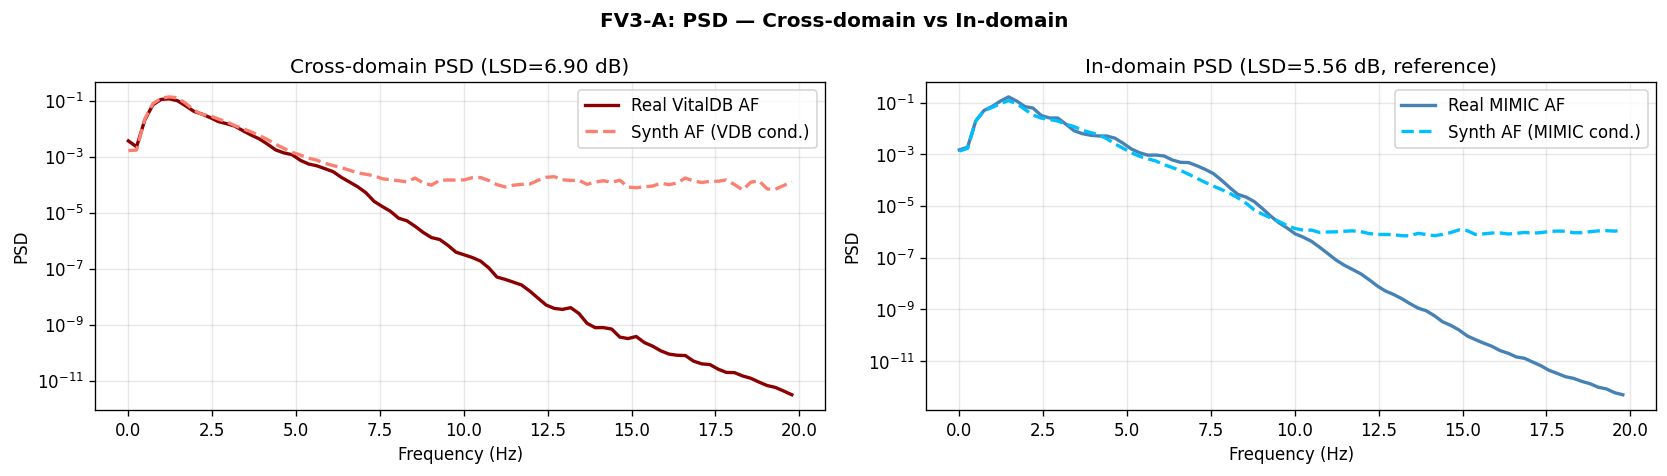

In [73]:
# ── LSD ─────────────────────────────────────────────────────────────────────
lsd_vdb_band = lsd(ppg_vdb_real_subset, ppg_vdb_synth, band=(0.5, 8.0))
lsd_vdb_full = lsd(ppg_vdb_real_subset, ppg_vdb_synth)

print('LSD — VitalDB real AF vs Synthetic (VitalDB-conditioned):')
print(f'  Band-restricted 0.5-8 Hz : {lsd_vdb_band:.2f} dB')
print(f'  Full spectrum             : {lsd_vdb_full:.2f} dB  '
      '(inflated by out-of-band residuals)')
print()
print('In-domain reference (MIMIC-AF, from §8):')
print(f'  LSD AF = {lsd_af:.2f} dB  |  LSD SR = {lsd_sr:.2f} dB  |  '
      f'mean = {np.mean([lsd_af,lsd_sr]):.2f} dB')
print(f'  VitalDB Δ vs MIMIC-AF mean: '
      f'{lsd_vdb_band - np.mean([lsd_af,lsd_sr]):+.2f} dB')

# ── PSD comparison ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: VitalDB real vs VitalDB-conditioned synth
ax = axes[0]
psd_vr, psd_vs = [], []
freqs = None
for sig in ppg_vdb_real_subset[:200]:
    f, p = welch(sig, fs=FS, nperseg=512); freqs = f; psd_vr.append(p)
for sig in ppg_vdb_synth[:200]:
    _, p = welch(sig, fs=FS, nperseg=512); psd_vs.append(p)
mask = freqs <= 20
ax.semilogy(freqs[mask], np.mean(psd_vr,0)[mask],
            color='darkred',  lw=2.0, label='Real VitalDB AF')
ax.semilogy(freqs[mask], np.mean(psd_vs,0)[mask],
            color='salmon',   lw=2.0, ls='--', label='Synth AF (VDB cond.)')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD')
ax.set_title(f'Cross-domain PSD (LSD={lsd_vdb_band:.2f} dB)')
ax.legend(); ax.grid(alpha=0.3)

# Right: MIMIC-AF real vs MIMIC-conditioned synth (in-domain reference)
ax = axes[1]
psd_mr, psd_ms = [], []
for sig in eval_real['AF'][:200]:
    _, p = welch(sig, fs=FS, nperseg=512); psd_mr.append(p)
for sig in eval_synth['AF'][:200]:
    _, p = welch(sig, fs=FS, nperseg=512); psd_ms.append(p)
ax.semilogy(freqs[mask], np.mean(psd_mr,0)[mask],
            color='steelblue', lw=2.0, label='Real MIMIC AF')
ax.semilogy(freqs[mask], np.mean(psd_ms,0)[mask],
            color='deepskyblue', lw=2.0, ls='--', label='Synth AF (MIMIC cond.)')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD')
ax.set_title(f'In-domain PSD (LSD={lsd_af:.2f} dB, reference)')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('FV3-A: PSD — Cross-domain vs In-domain', fontweight='bold')
plt.tight_layout(); plt.show()


In [74]:
# ── 5-feature vectors (same as §10) ─────────────────────────────────────────
N_FV3 = min(200, len(ppg_vdb_real_subset), len(ppg_vdb_synth))
feat_vdb_real_v  = feature_vec(ppg_vdb_real_subset[:N_FV3])
feat_vdb_synth_v = feature_vec(ppg_vdb_synth[:N_FV3])

feat_names_local = ['HR_mean','HR_std','Power_0-4Hz','Power_4-8Hz','RMS']

print('Wasserstein distance — real vs synthetic:')
print(f"{'Feature':<15}  {'VitalDB (cross-domain)':>22}  {'MIMIC-AF (in-domain)':>22}")
print('─' * 63)
wd_vdb_vals = []
for i, fn in enumerate(feat_names_local):
    wd_v = wasserstein_distance(feat_vdb_real_v[:,i], feat_vdb_synth_v[:,i])
    wd_m = wasserstein_distance(feats['real_AF'][:,i], feats['synth_AF'][:,i])
    wd_vdb_vals.append(wd_v)
    ratio = wd_v / (wd_m + 1e-10)
    print(f"  {fn:<13}  {wd_v:>22.4f}  {wd_m:>22.4f}  (ratio {ratio:.2f}x)")
print(f"\n  Mean Wasserstein — VitalDB: {np.mean(wd_vdb_vals):.4f}  "
      f"MIMIC-AF: {np.mean([wasserstein_distance(feats['real_AF'][:,i],feats['synth_AF'][:,i]) for i in range(5)]):.4f}")


Wasserstein distance — real vs synthetic:
Feature          VitalDB (cross-domain)    MIMIC-AF (in-domain)
───────────────────────────────────────────────────────────────
  HR_mean                        9.7295                  8.5561  (ratio 1.14x)
  HR_std                         5.0886                  2.5988  (ratio 1.96x)
  Power_0-4Hz                    0.0236                  0.0343  (ratio 0.69x)
  Power_4-8Hz                    0.0011                  0.0015  (ratio 0.73x)
  RMS                            0.0735                  0.0340  (ratio 2.16x)

  Mean Wasserstein — VitalDB: 2.9833  MIMIC-AF: 2.2449


In [75]:
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel

def rbf_mmd2(X: np.ndarray, Y: np.ndarray,
             n: int = 300, seed: int = SEED) -> float:
    """
    Unbiased MMD² with RBF kernel, median bandwidth heuristic.
    Operates in the 5-feature space (HR_mean, HR_std, Power 0-4Hz, 4-8Hz, RMS).
    """
    rng_ = np.random.default_rng(seed)
    X = X[rng_.choice(len(X), min(n, len(X)), replace=False)]
    Y = Y[rng_.choice(len(Y), min(n, len(Y)), replace=False)]
    Z     = np.vstack([X, Y])
    dists = pairwise_distances(Z, metric='euclidean')
    sigma = np.median(dists[dists > 0]) / np.sqrt(2)
    gamma = 1.0 / (2 * max(sigma, 1e-8) ** 2)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    nx, ny = len(X), len(Y)
    mmd2 = ((Kxx.sum() - np.trace(Kxx)) / (nx*(nx-1))
           + (Kyy.sum() - np.trace(Kyy)) / (ny*(ny-1))
           - 2 * Kxy.mean())
    return float(mmd2)


print('Computing MMD² (RBF kernel, 5-feature space, n=300)...')
mmd_vdb   = rbf_mmd2(feat_vdb_real_v,     feat_vdb_synth_v,   n=N_FV3)
mmd_mimic = rbf_mmd2(feats['real_AF'],     feats['synth_AF'],  n=N_FV3)
mmd_xdom  = rbf_mmd2(feat_vdb_real_v,      feats['real_AF'],  n=N_FV3)

print(f"\nMMD²:")
print(f"  VitalDB real AF vs Synth (VDB cond.)  : {mmd_vdb:.6f}  [cross-domain generation]")
print(f"  MIMIC-AF real AF vs Synth (MIMIC cond.): {mmd_mimic:.6f}  [in-domain generation]")
print(f"  VitalDB real AF vs MIMIC real AF        : {mmd_xdom:.6f}  [domain gap baseline]")
print(f"\nInterpretation: if MMD²(VDB real, synth) ≪ MMD²(VDB real, MIMIC real),")
print(f"the model is closing the cross-domain gap through conditioning.")


Computing MMD² (RBF kernel, 5-feature space, n=300)...

MMD²:
  VitalDB real AF vs Synth (VDB cond.)  : 0.075161  [cross-domain generation]
  MIMIC-AF real AF vs Synth (MIMIC cond.): 0.046367  [in-domain generation]
  VitalDB real AF vs MIMIC real AF        : 0.381513  [domain gap baseline]

Interpretation: if MMD²(VDB real, synth) ≪ MMD²(VDB real, MIMIC real),
the model is closing the cross-domain gap through conditioning.


In [76]:
print('Computing DTW (Sakoe-Chiba band=25, N=30, ×5 downsampled)...')
dtw_vdb_fid,dtw_vdb_cov     = dtw_nn_summary(ppg_vdb_real_subset, ppg_vdb_synth)
dtw_mimic_fid,dtw_mimic_cov = dtw_nn_summary(eval_real['AF'],     eval_synth['AF'])
dtw_xdom_fid,dtw_xdom_cov   = dtw_nn_summary(ppg_vdb_real_subset, eval_real['AF'])

print(f'\nDTW (fidelidade, cobertura):')
print(f'  VitalDB real vs Synth (VDB cond.)   : fid={dtw_vdb_fid:.3f} cov={dtw_vdb_cov:.3f}  [cross-domain]')
print(f'  MIMIC real vs Synth (MIMIC cond.)    : fid={dtw_mimic_fid:.3f} cov={dtw_mimic_cov:.3f}  [in-domain]')
print(f'  VitalDB real vs MIMIC real AF         : fid={dtw_xdom_fid:.3f} cov={dtw_xdom_cov:.3f}  [domain gap]')

Computing DTW (Sakoe-Chiba band, N=30, ×10 subsampled)...

DTW (mean ± std):
  VitalDB real vs Synth (VDB cond.)   : 3.335 ± 0.861  [cross-domain]
  MIMIC real vs Synth (MIMIC cond.)    : 3.091 ± 0.802  [in-domain]
  VitalDB real vs MIMIC real AF         : 3.755 ± 1.311  [domain gap]


Computing t-SNE (cross-domain, 4-way)...


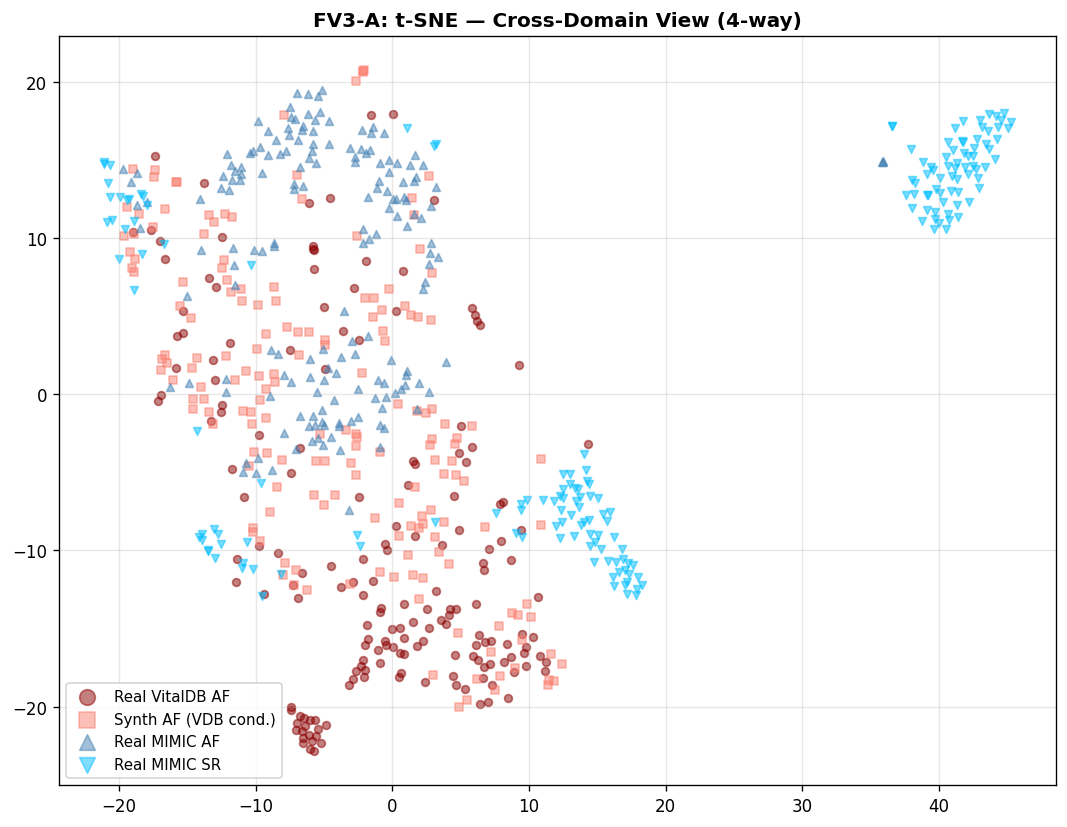


  FV3-A Fidelity Summary  (VitalDB real AF vs Synth VDB-conditioned)
  LSD (0.5–8 Hz)   : 6.90 dB  (MIMIC in-domain: 7.07 dB)
  Mean Wasserstein : 2.9833
  MMD²             : 0.075161  (domain gap baseline: 0.381513)
  DTW              : 3.335 ± 0.861  (domain gap baseline: 3.755)


In [77]:
# 4-way t-SNE: Real VitalDB AF  |  Synth AF (VDB cond.)  |
#              Real MIMIC AF    |  Real MIMIC SR
N_TSNE_VDB = min(200, len(feat_vdb_real_v), len(feat_vdb_synth_v), N_TSNE)

all_f_vdb = np.concatenate([
    feat_vdb_real_v[:N_TSNE_VDB],
    feat_vdb_synth_v[:N_TSNE_VDB],
    feats['real_AF'][:N_TSNE_VDB],
    feats['real_SR'][:N_TSNE_VDB],
])
all_l_vdb = (
    ['Real VitalDB AF']    * N_TSNE_VDB +
    ['Synth AF (VDB cond.)'] * N_TSNE_VDB +
    ['Real MIMIC AF']      * N_TSNE_VDB +
    ['Real MIMIC SR']      * N_TSNE_VDB
)

sc_vdb = StandardScaler().fit(all_f_vdb)
print('Computing t-SNE (cross-domain, 4-way)...')
emb_vdb = TSNE(n_components=2, perplexity=40,
               random_state=SEED, n_iter=1000
               ).fit_transform(sc_vdb.transform(all_f_vdb))

style = {
    'Real VitalDB AF':      ('darkred',      'o'),
    'Synth AF (VDB cond.)': ('salmon',       's'),
    'Real MIMIC AF':        ('steelblue',    '^'),
    'Real MIMIC SR':        ('deepskyblue',  'v'),
}

fig, ax = plt.subplots(figsize=(9, 7))
for lbl, (col, mrk) in style.items():
    mask = [l == lbl for l in all_l_vdb]
    ax.scatter(emb_vdb[mask,0], emb_vdb[mask,1],
               c=col, marker=mrk, alpha=0.50, s=22, label=lbl)
ax.set_title('FV3-A: t-SNE — Cross-Domain View (4-way)', fontweight='bold')
ax.legend(markerscale=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Compact fidelity summary ─────────────────────────────────────────────────
print()
print('=' * 70)
print('  FV3-A Fidelity Summary  (VitalDB real AF vs Synth VDB-conditioned)')
print('=' * 70)
print(f'  LSD (0.5–8 Hz)   : {lsd_vdb_band:.2f} dB  '
      f'(MIMIC in-domain: {np.mean([lsd_af,lsd_sr]):.2f} dB)')
print(f'  Mean Wasserstein : {np.mean(wd_vdb_vals):.4f}')
print(f'  MMD²             : {mmd_vdb:.6f}  '
      f'(domain gap baseline: {mmd_xdom:.6f})')
print(f'  DTW              : {dtw_vdb_m:.3f} ± {dtw_vdb_s:.3f}  '
      f'(domain gap baseline: {dtw_xdom_m:.3f})')
print('=' * 70)


### FV3-B — Classifier Evaluation (ClfUNetGAN, VitalDB-conditioned synthetics)

Same ClfUNetGAN architecture as FV2. Three training configurations:
| Dataset | Training data | Rationale |
|---------|---------------|-----------|
| D_VDB1 | 100% VDB-synth AF + 100% real MIMIC SR | Pure cross-domain TSTR |
| D_VDB2 | 50% VDB-synth AF + 50% real MIMIC AF + 100% real MIMIC SR | Hybrid augmentation |
| D_VDB_ref | 100% real MIMIC AF + 100% real MIMIC SR | Baseline (= FV2 D4) |

Two test sets:
1. **MIMIC real test set** (same as FV2 — direct comparability)
2. **Cross-domain test set**: real VitalDB AF + real MIMIC SR test (true out-of-distribution evaluation)

In [78]:
# ── VitalDB-conditioned synthetic pool for classifier training ───────────────
# Use the full VitalDB conditioning (not just the subset used for fidelity)
N_VDB_CLF = min(N_SYNTH_POOL, len(cond_vdb_np))
rng_clf   = np.random.default_rng(SEED + 10)
idx_clf   = rng_clf.choice(len(cond_vdb_np), N_VDB_CLF, replace=False)

if N_VDB_CLF > N_VDB_GEN:
    # Need to generate additional windows beyond those already generated
    extra_idx  = np.setdiff1d(idx_clf, idx_gen)
    if len(extra_idx) > 0:
        cond_extra = torch.tensor(cond_vdb_np[extra_idx],
                                   dtype=torch.float32).to(DEVICE)
        extra_chunks = []
        for i in range(0, len(cond_extra), 64):
            extra_chunks.append(
                heun_sample(ema_model, cond_extra[i:i+64],
                            ODE_STEPS, BEST_GS).cpu().numpy().squeeze(1)
            )
        ppg_vdb_synth_clf = np.vstack(
            [ppg_vdb_synth,
             np.concatenate(extra_chunks)]  # append new
        )
    else:
        ppg_vdb_synth_clf = ppg_vdb_synth
else:
    ppg_vdb_synth_clf = ppg_vdb_synth[:N_VDB_CLF]

print(f'VDB-conditioned synthetic pool for classifier: {ppg_vdb_synth_clf.shape}')

# ── Balancing unit ────────────────────────────────────────────────────────────
N_VDB_UNIT = min(
    len(ppg_vdb_synth_clf),
    len(real_pool['AF']),
    len(real_pool['SR']),
)
print(f'Balancing unit N_VDB_UNIT = {N_VDB_UNIT}')

rng_ds = np.random.default_rng(SEED + 20)

def sample_n_vdb(arr, n, rng):
    idx = rng.choice(len(arr), min(n, len(arr)), replace=False)
    return arr[idx]

# D_VDB1: 100% VDB-synth AF + 100% real MIMIC SR  (pure cross-domain TSTR)
d_vdb1_X = np.vstack([sample_n_vdb(ppg_vdb_synth_clf, N_VDB_UNIT, rng_ds),
                       sample_n_vdb(real_pool['SR'],   N_VDB_UNIT, rng_ds)])
d_vdb1_y = np.array([1]*N_VDB_UNIT + [0]*N_VDB_UNIT)

# D_VDB2: 50% VDB-synth AF + 50% real MIMIC AF + 100% real MIMIC SR  (hybrid)
N_HALF_VDB = N_VDB_UNIT // 2
d_vdb2_X = np.vstack([sample_n_vdb(ppg_vdb_synth_clf, N_HALF_VDB, rng_ds),
                       sample_n_vdb(real_pool['AF'],   N_HALF_VDB, rng_ds),
                       sample_n_vdb(real_pool['SR'],   N_VDB_UNIT, rng_ds)])
d_vdb2_y = np.array([1]*N_HALF_VDB + [1]*N_HALF_VDB + [0]*N_VDB_UNIT)

# D_VDB_ref: 100% real MIMIC AF + 100% real MIMIC SR  (baseline)
d_ref_X = np.vstack([sample_n_vdb(real_pool['AF'], N_VDB_UNIT, rng_ds),
                      sample_n_vdb(real_pool['SR'], N_VDB_UNIT, rng_ds)])
d_ref_y = np.array([1]*N_VDB_UNIT + [0]*N_VDB_UNIT)

datasets_vdb = {
    'D_VDB1 — VDB-synth AF + MIMIC SR (TSTR)': (d_vdb1_X, d_vdb1_y),
    'D_VDB2 — VDB-synth AF + MIMIC AF + SR (hybrid)': (d_vdb2_X, d_vdb2_y),
    'D_VDB_ref — Real MIMIC AF + SR (baseline)': (d_ref_X, d_ref_y),
}
print('\nDataset sizes:')
for name, (X, y) in datasets_vdb.items():
    print(f'  {name}: {len(X)} segs  (AF={y.sum()}, SR={(y==0).sum()})')


VDB-conditioned synthetic pool for classifier: (3200, 1250)
Balancing unit N_VDB_UNIT = 2374

Dataset sizes:
  D_VDB1 — VDB-synth AF + MIMIC SR (TSTR): 4748 segs  (AF=2374, SR=2374)
  D_VDB2 — VDB-synth AF + MIMIC AF + SR (hybrid): 4748 segs  (AF=2374, SR=2374)
  D_VDB_ref — Real MIMIC AF + SR (baseline): 4748 segs  (AF=2374, SR=2374)


In [79]:
# ── Cross-domain test set: real VitalDB AF + real MIMIC SR ──────────────────
# Uses VitalDB windows NOT used in conditioning (held-out) for the positive class.
# For the negative class, real MIMIC-AF SR test split (X_te_g where y_te_g==0).

ppg_vdb_heldout = ppg_vdb_mm   # all VitalDB real AF windows (already rescaled)

N_XDOM = min(
    len(ppg_vdb_heldout),
    int((y_te_g == 0).sum()),    # number of SR in MIMIC test split
)

rng_xd  = np.random.default_rng(SEED + 30)
idx_vdb_xd = rng_xd.choice(len(ppg_vdb_heldout), N_XDOM, replace=False)
idx_sr_xd  = rng_xd.choice(np.where(y_te_g == 0)[0], N_XDOM, replace=False)

X_xdom_te = np.vstack([ppg_vdb_heldout[idx_vdb_xd],
                        X_te_g[idx_sr_xd]])
y_xdom_te = np.array([1]*N_XDOM + [0]*N_XDOM)

print(f'Cross-domain test set:')
print(f'  Positive class — real VitalDB AF : {N_XDOM}')
print(f'  Negative class — real MIMIC SR   : {N_XDOM}')
print(f'  Total                            : {len(X_xdom_te)}')
print(f'\nStandard MIMIC test set (for reference):')
print(f'  {X_te_g.shape}  (AF={y_te_g.sum()}, SR={(y_te_g==0).sum()})')


Cross-domain test set:
  Positive class — real VitalDB AF : 573
  Negative class — real MIMIC SR   : 573
  Total                            : 1146

Standard MIMIC test set (for reference):
  (1260, 1250)  (AF=687, SR=573)


In [80]:
N_SEEDS_VDB = 5
results_vdb_mimic = {}   # tested on MIMIC real test set
results_vdb_xdom  = {}   # tested on cross-domain test set (VitalDB AF + MIMIC SR)

print(f'Training ClfUNetGAN on FV3 datasets ({N_SEEDS_VDB} seeds)...')
print('Testing on two sets: [1] MIMIC real  [2] Cross-domain (VDB AF + MIMIC SR)')
print('=' * 70)

for ds_name, (Xtr, ytr) in datasets_vdb.items():
    print(f'\n{ds_name}')
    ml_mimic = {k: [] for k in
                ['accuracy','auroc','precision','recall',
                 'sensitivity','specificity','f1','threshold']}
    ml_xdom  = {k: [] for k in ml_mimic}

    for s in range(N_SEEDS_VDB):
        torch.manual_seed(s); np.random.seed(s)
        clf, thr = train_clf_unetgan(Xtr, ytr, X_vl_g, y_vl_g)

        # Test 1: MIMIC real test
        m_mimic = eval_clf_unetgan(clf, X_te_g,    y_te_g,    threshold=thr)
        m_mimic['threshold'] = thr
        for k in ml_mimic: ml_mimic[k].append(m_mimic[k])

        # Test 2: cross-domain (VitalDB AF + MIMIC SR)
        m_xdom = eval_clf_unetgan(clf, X_xdom_te, y_xdom_te, threshold=thr)
        m_xdom['threshold'] = thr
        for k in ml_xdom: ml_xdom[k].append(m_xdom[k])

        print(f'  seed {s}  [MIMIC] AUROC={m_mimic["auroc"]:.4f}  '
              f'F1={m_mimic["f1"]:.4f}  '
              f'[XDom] AUROC={m_xdom["auroc"]:.4f}  '
              f'F1={m_xdom["f1"]:.4f}  thr={thr:.2f}')

    results_vdb_mimic[ds_name] = {k: (float(np.mean(v)), float(np.std(v)))
                                   for k, v in ml_mimic.items()}
    results_vdb_xdom[ds_name]  = {k: (float(np.mean(v)), float(np.std(v)))
                                   for k, v in ml_xdom.items()}
    mu_m = results_vdb_mimic[ds_name]
    mu_x = results_vdb_xdom[ds_name]
    print(f'  [MIMIC] AUROC={mu_m["auroc"][0]:.4f}±{mu_m["auroc"][1]:.4f}  '
          f'F1={mu_m["f1"][0]:.4f}±{mu_m["f1"][1]:.4f}')
    print(f'  [XDom]  AUROC={mu_x["auroc"][0]:.4f}±{mu_x["auroc"][1]:.4f}  '
          f'F1={mu_x["f1"][0]:.4f}±{mu_x["f1"][1]:.4f}')


Training ClfUNetGAN on FV3 datasets (5 seeds)...
Testing on two sets: [1] MIMIC real  [2] Cross-domain (VDB AF + MIMIC SR)

D_VDB1 — VDB-synth AF + MIMIC SR (TSTR)
  seed 0  [MIMIC] AUROC=0.5982  F1=0.7115  [XDom] AUROC=0.6801  F1=0.7555  thr=0.26
  seed 1  [MIMIC] AUROC=0.5250  F1=0.5971  [XDom] AUROC=0.7982  F1=0.7682  thr=0.41
  seed 2  [MIMIC] AUROC=0.6069  F1=0.7303  [XDom] AUROC=0.6742  F1=0.7530  thr=0.24
  seed 3  [MIMIC] AUROC=0.6013  F1=0.7110  [XDom] AUROC=0.6763  F1=0.7523  thr=0.31
  seed 4  [MIMIC] AUROC=0.5962  F1=0.7207  [XDom] AUROC=0.6854  F1=0.7521  thr=0.21
  [MIMIC] AUROC=0.5855±0.0305  F1=0.6941±0.0490
  [XDom]  AUROC=0.7028±0.0478  F1=0.7562±0.0061

D_VDB2 — VDB-synth AF + MIMIC AF + SR (hybrid)
  seed 0  [MIMIC] AUROC=0.6228  F1=0.7464  [XDom] AUROC=0.6505  F1=0.7463  thr=0.28
  seed 1  [MIMIC] AUROC=0.5041  F1=0.7057  [XDom] AUROC=0.8248  F1=0.6667  thr=0.01
  seed 2  [MIMIC] AUROC=0.6232  F1=0.7523  [XDom] AUROC=0.6536  F1=0.7495  thr=0.25
  seed 3  [MIMIC] AU

In [81]:
# ── Table 1: MIMIC real test set ─────────────────────────────────────────────
print('=' * 110)
print('  FV3-B [Test 1: MIMIC real test set]  '
      '(5 seeds, optimal val threshold)')
print('=' * 110)
print(f"  {'Dataset':<44}  {'Acc':>10}  {'AUROC':>12}  "
      f"{'Prec':>10}  {'Recall':>10}  {'Spec':>10}  {'F1':>10}")
print('  ' + '─' * 104)
for ds_name, m in results_vdb_mimic.items():
    print(f"  {ds_name:<44}  "
          f"{m['accuracy'][0]:.4f}±{m['accuracy'][1]:.3f}  "
          f"{m['auroc'][0]:.4f}±{m['auroc'][1]:.3f}  "
          f"{m['precision'][0]:.4f}±{m['precision'][1]:.3f}  "
          f"{m['recall'][0]:.4f}±{m['recall'][1]:.3f}  "
          f"{m['specificity'][0]:.4f}±{m['specificity'][1]:.3f}  "
          f"{m['f1'][0]:.4f}±{m['f1'][1]:.3f}")
print('=' * 110)

# ── Table 2: Cross-domain test set ────────────────────────────────────────────
print()
print('=' * 110)
print('  FV3-B [Test 2: Cross-domain  VitalDB AF + MIMIC SR]  '
      '(5 seeds, optimal val threshold)')
print('=' * 110)
print(f"  {'Dataset':<44}  {'Acc':>10}  {'AUROC':>12}  "
      f"{'Prec':>10}  {'Recall':>10}  {'Spec':>10}  {'F1':>10}")
print('  ' + '─' * 104)
for ds_name, m in results_vdb_xdom.items():
    print(f"  {ds_name:<44}  "
          f"{m['accuracy'][0]:.4f}±{m['accuracy'][1]:.3f}  "
          f"{m['auroc'][0]:.4f}±{m['auroc'][1]:.3f}  "
          f"{m['precision'][0]:.4f}±{m['precision'][1]:.3f}  "
          f"{m['recall'][0]:.4f}±{m['recall'][1]:.3f}  "
          f"{m['specificity'][0]:.4f}±{m['specificity'][1]:.3f}  "
          f"{m['f1'][0]:.4f}±{m['f1'][1]:.3f}")
print('=' * 110)
print(f'\nNote: D_VDB_ref row is equivalent to FV2 D4 (TRTR baseline).')
print(f'Cross-domain AUROC gap (D_VDB1 vs baseline):')
ref = results_vdb_xdom['D_VDB_ref — Real MIMIC AF + SR (baseline)']
d1  = results_vdb_xdom['D_VDB1 — VDB-synth AF + MIMIC SR (TSTR)']
print(f'  AUROC: {d1["auroc"][0]-ref["auroc"][0]:+.4f}  '
      f'F1: {d1["f1"][0]-ref["f1"][0]:+.4f}')


  FV3-B [Test 1: MIMIC real test set]  (5 seeds, optimal val threshold)
  Dataset                                              Acc         AUROC        Prec      Recall        Spec          F1
  ────────────────────────────────────────────────────────────────────────────────────────────────────────
  D_VDB1 — VDB-synth AF + MIMIC SR (TSTR)       0.6329±0.039  0.5855±0.030  0.6325±0.021  0.7721±0.086  0.4660±0.022  0.6941±0.049
  D_VDB2 — VDB-synth AF + MIMIC AF + SR (hybrid)  0.6532±0.054  0.5985±0.047  0.6323±0.044  0.9022±0.049  0.3546±0.177  0.7408±0.018
  D_VDB_ref — Real MIMIC AF + SR (baseline)     0.6589±0.057  0.6083±0.054  0.6339±0.044  0.9173±0.041  0.3490±0.175  0.7473±0.021

  FV3-B [Test 2: Cross-domain  VitalDB AF + MIMIC SR]  (5 seeds, optimal val threshold)
  Dataset                                              Acc         AUROC        Prec      Recall        Spec          F1
  ─────────────────────────────────────────────────────────────────────────────────────────────

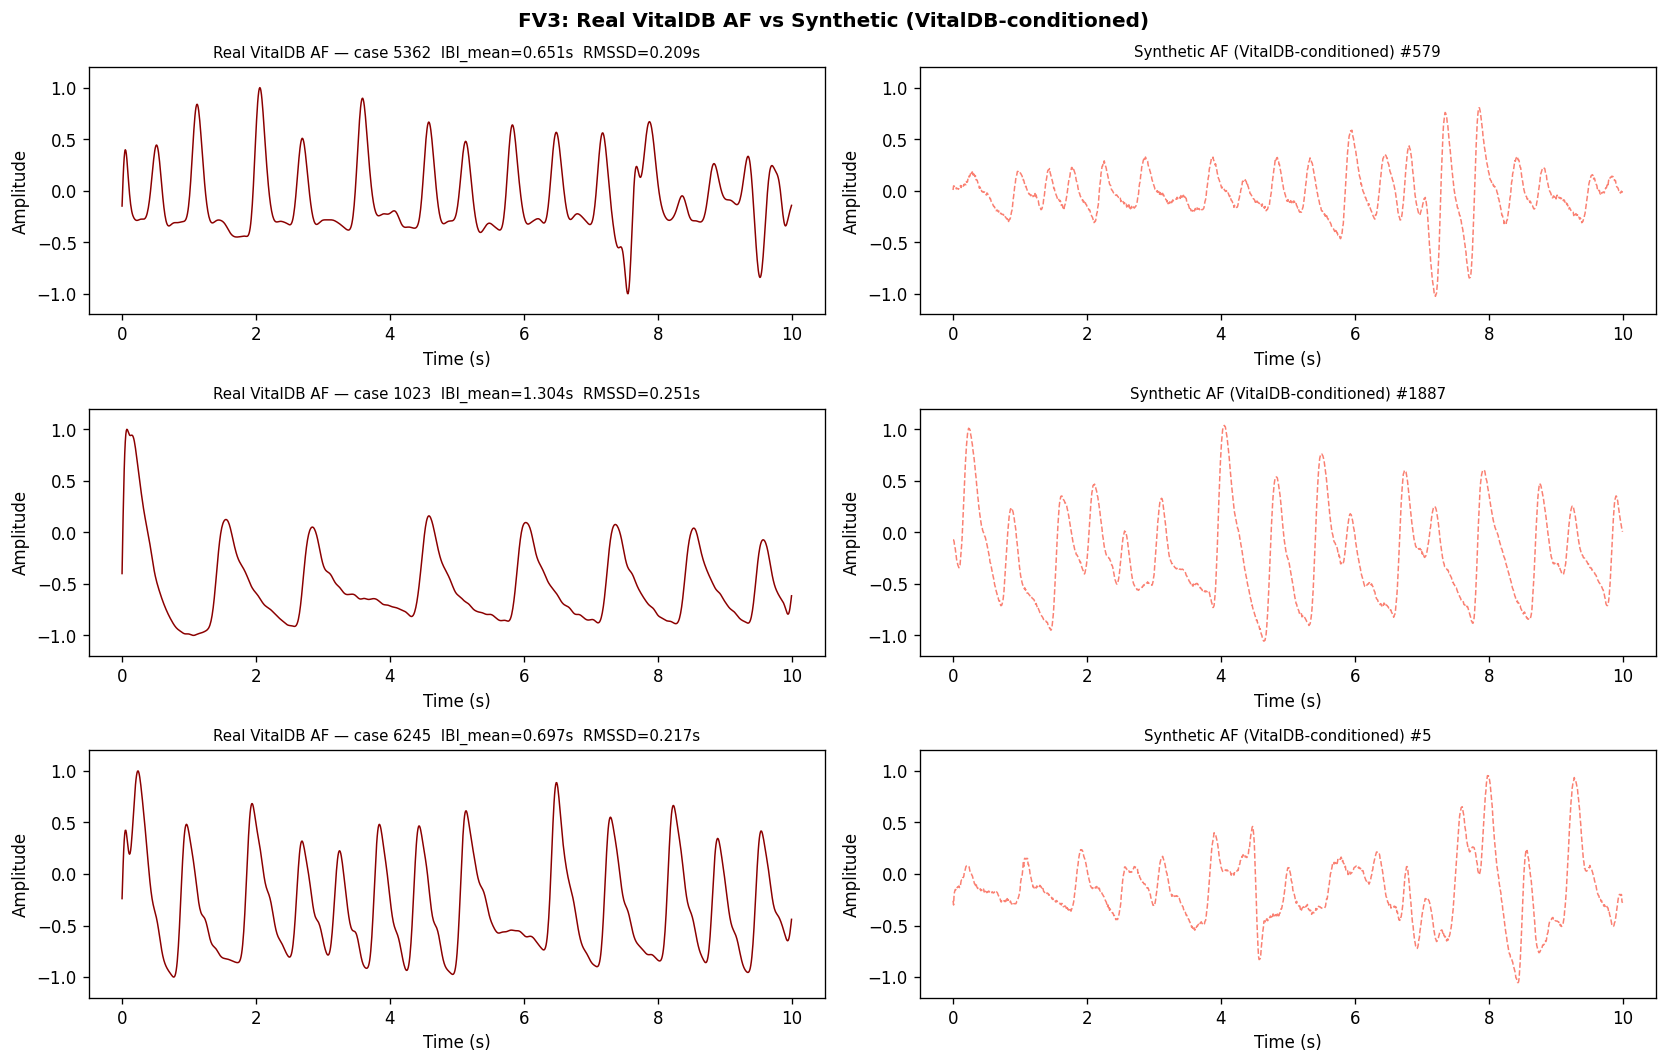

In [82]:
# ── Visual comparison: real VitalDB AF vs generated ─────────────────────────
rng_vis = np.random.default_rng(SEED + 99)
n_vis   = 3
idx_r   = rng_vis.choice(len(ppg_vdb_real_subset), n_vis, replace=False)
idx_s   = rng_vis.choice(len(ppg_vdb_synth),       n_vis, replace=False)

t_ax = np.linspace(0, WIN_SEC, WIN_LEN)
fig, axes = plt.subplots(n_vis, 2, figsize=(14, 3*n_vis))

for row_i, (ir, is_) in enumerate(zip(idx_r, idx_s)):
    case_id = meta_vdb.iloc[idx_gen[ir] if ir < len(idx_gen) else ir]['case_id']
    ibi_m   = meta_vdb.iloc[idx_gen[ir] if ir < len(idx_gen) else ir]['ibi_mean']
    rmssd_v = meta_vdb.iloc[idx_gen[ir] if ir < len(idx_gen) else ir]['rmssd']

    axes[row_i, 0].plot(t_ax, ppg_vdb_real_subset[ir],
                        color='darkred', lw=0.9)
    axes[row_i, 0].set_title(
        f'Real VitalDB AF — case {int(case_id)}  '
        f'IBI_mean={ibi_m:.3f}s  RMSSD={rmssd_v:.3f}s', fontsize=9)
    axes[row_i, 0].set_ylim(-1.2, 1.2)

    axes[row_i, 1].plot(t_ax, ppg_vdb_synth[is_],
                        color='salmon', lw=0.9, ls='--')
    axes[row_i, 1].set_title(
        f'Synthetic AF (VitalDB-conditioned) #{is_}', fontsize=9)
    axes[row_i, 1].set_ylim(-1.2, 1.2)

    for ax in axes[row_i]:
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')

plt.suptitle('FV3: Real VitalDB AF vs Synthetic (VitalDB-conditioned)',
             fontweight='bold')
plt.tight_layout(); plt.show()


---
## Part B — Cross-Domain: MIMIC-III-Ext-PPG

Uses the MIMIC-AF trained model to generate synthetic AF PPG conditioned on
IBI features from the MIMIC-III-Ext-PPG dataset (fingertip PPG, 125 Hz, WFDB format).
Evaluates how well the MIMIC-AF model generalises to a different hospital cohort.

**Prerequisites:**
- `ibi_session.csv` from the MIMIC-III-Ext-PPG CFM notebook  
  (`/kaggle/working/ibi_session.csv` by default)
- MIMIC-III WFDB files accessible at paths stored in that session CSV

**Part B.1** Fidelity: LSD · Wasserstein · MMD · DTW · t-SNE  
**Part B.2** Classifier: ClfUNetGAN with DB1/DB2/DBref on two test sets

In [83]:
# ── B0: Install wfdb (if not already available) ─────────────────────────────
import subprocess, sys
try:
    import wfdb
    print(f'wfdb {wfdb.__version__} already available')
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','wfdb','-q'])
    import wfdb
    print(f'wfdb installed: {wfdb.__version__}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.6 MB/s eta 0:00:00
wfdb installed: 4.3.1


In [84]:
# ── B1: Load MIMIC-III IBI session + PPG loader ─────────────────────────────
# Adjust IBI_SESSION_M3 to match the path in your MIMIC-III-Ext-PPG notebook.
IBI_SESSION_M3 = '/kaggle/input/datasets/simaosoares4/ibi-values-b2/ibi_session_3_380.csv'
N_B_MAX  = 2000   # max conditioning windows for generation
N_B_EVAL = 200    # windows used for fidelity metrics

if not os.path.exists(IBI_SESSION_M3):
    print(f'WARNING: {IBI_SESSION_M3} not found.')
    print('Run the MIMIC-III-Ext-PPG CFM notebook first and check the path.')
    df_m3 = pd.DataFrame()
else:
    df_m3 = pd.read_csv(IBI_SESSION_M3)
    df_m3 = df_m3.dropna(subset=['IBI_mean','IBI_std','RMSSD'])
    df_m3 = df_m3[(df_m3.IBI_mean>=IBI_MIN)&(df_m3.IBI_mean<=IBI_MAX)&
                   (df_m3.IBI_std>=0)&(df_m3.IBI_std<=0.5)].copy()
    print(f'MIMIC-III session loaded: {len(df_m3):,} windows')
    for r in ['AF','SR']:
        s = df_m3[df_m3.event_rhythm==r]
        print(f'  {r}: {len(s):,} windows  {s.subject_id.nunique()} subjects')


def load_ppg_m3(wfdb_path, sub_win, fs=FS, win_len=WIN_LEN):
    """Load, filter and normalise a 10s sub-window from MIMIC-III WFDB file."""
    start = int(sub_win) * win_len
    end   = start + win_len
    try:
        rec = wfdb.rdrecord(wfdb_path)
        if 'PLETH' not in rec.sig_name:
            return None
        sig = rec.p_signal[start:end, rec.sig_name.index('PLETH')].copy()
        if len(sig)<win_len or np.isnan(sig).any() or np.all(sig==sig[0]):
            return None
        nyq=fs/2; b,a=butter(4,[0.5/nyq,8./nyq],btype='band')
        sig=filtfilt(b,a,sig)
        mn,mx=sig.min(),sig.max()
        if mx-mn<1e-8: return None
        return (2*(sig-mn)/(mx-mn)-1).astype(np.float32)
    except: return None


# ── Load real MIMIC-III AF PPG + generate conditioning ───────────────────────
real_m3 = []; cond_m3_rows = []
if len(df_m3) > 0:
    df_m3_af = df_m3[df_m3.event_rhythm=='AF'].sample(
        min(N_B_MAX, len(df_m3[df_m3.event_rhythm=='AF'])), random_state=SEED)
    print(f'Loading real MIMIC-III AF PPG ({len(df_m3_af)} windows)...')
    for _, row in df_m3_af.iterrows():
        sig = load_ppg_m3(row['wfdb_path'], int(row['sub_win']))
        if sig is not None:
            real_m3.append(sig); cond_m3_rows.append(row)
    real_m3 = np.array(real_m3, dtype=np.float32)
    print(f'Loaded: {len(real_m3)} valid windows  '
          f'({100*len(real_m3)/len(df_m3_af):.1f}% yield)')


MIMIC-III session loaded: 194,836 windows
  AF: 98,725 windows  272 subjects
  SR: 96,111 windows  225 subjects
Loading real MIMIC-III AF PPG (2000 windows)...
Loaded: 2000 valid windows  (100.0% yield)


In [85]:
# ── B2: Generate synthetics from MIMIC-III conditioning ──────────────────────
synth_m3 = np.zeros((0, WIN_LEN), dtype=np.float32)
if len(cond_m3_rows) > 0:
    df_cond_m3 = pd.DataFrame(cond_m3_rows).reset_index(drop=True)
    nm, ns, nr = norm_ibi(df_cond_m3.IBI_mean.values,
                           df_cond_m3.IBI_std.values,
                           df_cond_m3.RMSSD.values)
    cond_t = torch.tensor(build_cond(nm, ns, nr, 'AF'),
                          dtype=torch.float32).to(DEVICE)
    print(f'Generating {len(cond_t)} MIMIC-III-conditioned synthetics...')
    chunks = []
    for i in range(0, len(cond_t), 64):
        chunks.append(
            heun_sample(ema_model, cond_t[i:i+64], ODE_STEPS, BEST_GS)
            .cpu().numpy().squeeze(1))
    synth_m3 = np.concatenate(chunks).astype(np.float32)
    print(f'Generated: {synth_m3.shape}  '
          f'range=[{synth_m3.min():.2f},{synth_m3.max():.2f}]')
else:
    print('No MIMIC-III data available — Part B skipped.')


Generating 2000 MIMIC-III-conditioned synthetics...
Generated: (2000, 1250)  range=[-1.77,1.63]


LSD — MIMIC-III real AF vs MIMIC-AF-generated (MIMIC-III cond.):
  Band 0.5–8 Hz : 6.60 dB
  Full spectrum  : 33.41 dB  (inflated by out-of-band)

In-domain reference (MIMIC-AF §8):
  LSD AF=5.56 dB  SR=8.57 dB  mean=7.07 dB
  MIMIC-III Δ vs in-domain mean: -0.47 dB


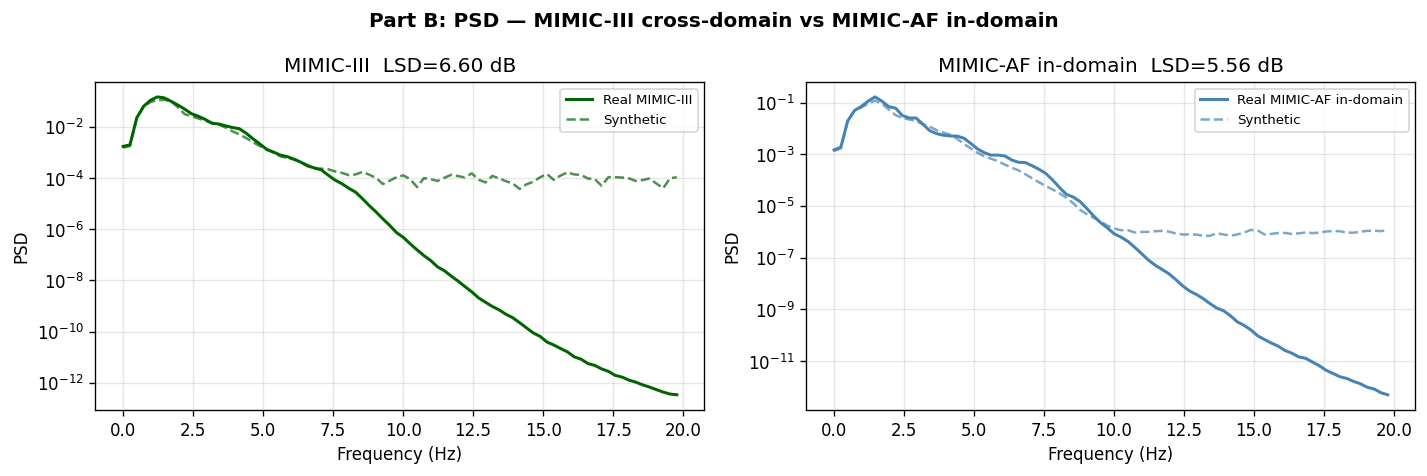

In [86]:
# ── B3: Fidelity — LSD + PSD ─────────────────────────────────────────────────
if len(real_m3) >= 20 and len(synth_m3) >= 20:
    N_FID = min(N_B_EVAL, len(real_m3), len(synth_m3))
    rng_b = np.random.default_rng(SEED)
    ir = rng_b.choice(len(real_m3),  N_FID, replace=False)
    is_= rng_b.choice(len(synth_m3), N_FID, replace=False)
    real_b_ev  = real_m3[ir]
    synth_b_ev = synth_m3[is_]

    lsd_m3_band = lsd(real_b_ev, synth_b_ev, band=(0.5, 8.0))
    lsd_m3_full = lsd(real_b_ev, synth_b_ev)
    print(f'LSD — MIMIC-III real AF vs MIMIC-AF-generated (MIMIC-III cond.):')
    print(f'  Band 0.5–8 Hz : {lsd_m3_band:.2f} dB')
    print(f'  Full spectrum  : {lsd_m3_full:.2f} dB  (inflated by out-of-band)')
    print()
    print(f'In-domain reference (MIMIC-AF §8):')
    lsd_af_ref = lsd(eval_real['AF'], eval_synth['AF'], band=(0.5, 8.0))
    lsd_sr_ref = lsd(eval_real['SR'], eval_synth['SR'], band=(0.5, 8.0))
    print(f'  LSD AF={lsd_af_ref:.2f} dB  SR={lsd_sr_ref:.2f} dB  '
          f'mean={(lsd_af_ref+lsd_sr_ref)/2:.2f} dB')
    print(f'  MIMIC-III Δ vs in-domain mean: '
          f'{lsd_m3_band-(lsd_af_ref+lsd_sr_ref)/2:+.2f} dB')

    fig, axes = plt.subplots(1,2,figsize=(12,4))
    for ax,(r,s,lbl,col) in zip(axes,[
            (real_b_ev,synth_b_ev,'MIMIC-III','darkgreen'),
            (eval_real['AF'],eval_synth['AF'],'MIMIC-AF in-domain','steelblue')]):
        pr,ps=[],[]
        for i in range(min(200,len(r),len(s))):
            _,p=welch(r[i],fs=FS,nperseg=512); pr.append(p)
            _,p=welch(s[i],fs=FS,nperseg=512); ps.append(p)
        freq=np.linspace(0,FS/2,len(pr[0]))
        msk=freq<=20
        ax.semilogy(freq[msk],np.mean(pr,0)[msk],color=col,lw=1.8,label=f'Real {lbl}')
        ax.semilogy(freq[msk],np.mean(ps,0)[msk],color=col,lw=1.5,
                    ls='--',alpha=0.7,label='Synthetic')
        ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD'); ax.legend(fontsize=8)
        ax.set_title(f'{lbl}  LSD={lsd(r,s,band=(0.5,8.)):.2f} dB'); ax.grid(alpha=0.3)
    plt.suptitle('Part B: PSD — MIMIC-III cross-domain vs MIMIC-AF in-domain',
                 fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Not enough data for B3.')


In [87]:
# ── B4: Wasserstein · MMD · DTW ──────────────────────────────────────────────
if len(real_m3) >= 20 and len(synth_m3) >= 20:
    feat_m3_real  = feature_vec(real_b_ev)
    feat_m3_synth = feature_vec(synth_b_ev)

    feat_names_b = ['HR_mean','HR_std','Power_0-4Hz','Power_4-8Hz','RMS']
    print('Wasserstein — MIMIC-III real vs MIMIC-AF-generated:')
    print(f"{'Feature':<15}  {'M3 cross-dom':>14}  {'AF in-dom':>12}  {'ratio':>7}")
    print('─'*52)
    for i,fn in enumerate(feat_names_b):
        wm3 = wasserstein_distance(feat_m3_real[:,i], feat_m3_synth[:,i])
        waf = wasserstein_distance(feats['real_AF'][:,i], feats['synth_AF'][:,i])
        print(f'  {fn:<13}  {wm3:>14.4f}  {waf:>12.4f}  {wm3/(waf+1e-8):>6.2f}x')

    # MMD
    mmd_m3  = rbf_mmd2(feat_m3_real,         feat_m3_synth)
    mmd_gap = rbf_mmd2(feat_m3_real,         feats['real_AF'])
    mmd_ref = rbf_mmd2(feats['real_AF'],      feats['synth_AF'])
    print(f'\nMMD²:')
    print(f'  MIMIC-III real vs Synth (MIMIC-III cond.) : {mmd_m3:.5f}  [cross-domain]')
    print(f'  MIMIC-AF real AF  vs Synth (MIMIC-AF cond.): {mmd_ref:.5f}  [in-domain]')
    print(f'  MIMIC-III real vs MIMIC-AF real AF          : {mmd_gap:.5f}  [domain gap]')
    if mmd_gap > 1e-6:
        print(f'  Gap closed: {100*(1-mmd_m3/mmd_gap):.1f}%')

    # DTW (using batch_dtw from FV3)
    dtw_m3_fid,dtw_m3_cov   = dtw_nn_summary(real_b_ev,    synth_b_ev)
    dtw_ref_fid,dtw_ref_cov = dtw_nn_summary(eval_real['AF'], eval_synth['AF'])
    dtw_gap_fid,dtw_gap_cov = dtw_nn_summary(real_b_ev,    eval_real['AF'])
    print(f'\nDTW (fidelidade, cobertura):')
    print(f'  MIMIC-III real vs Synth : fid={dtw_m3_fid:.3f} cov={dtw_m3_cov:.3f}  [cross-domain]')
    print(f'  MIMIC-AF  real vs Synth : fid={dtw_ref_fid:.3f} cov={dtw_ref_cov:.3f}  [in-domain]')
    print(f'  MIMIC-III vs MIMIC-AF   : fid={dtw_gap_fid:.3f} cov={dtw_gap_cov:.3f}  [domain gap]')


Wasserstein — MIMIC-III real vs MIMIC-AF-generated:
Feature            M3 cross-dom     AF in-dom    ratio
────────────────────────────────────────────────────
  HR_mean                3.3304        8.5561    0.39x
  HR_std                 5.1377        2.5988    1.98x
  Power_0-4Hz            0.0308        0.0343    0.90x
  Power_4-8Hz            0.0012        0.0015    0.79x
  RMS                    0.0298        0.0340    0.88x

MMD²:
  MIMIC-III real vs Synth (MIMIC-III cond.) : 0.02776  [cross-domain]
  MIMIC-AF real AF  vs Synth (MIMIC-AF cond.): 0.04637  [in-domain]
  MIMIC-III real vs MIMIC-AF real AF          : 0.07576  [domain gap]
  Gap closed: 63.4%

DTW (N=30, ×10 subsampled):
  MIMIC-III real vs Synth : 3.304  [cross-domain]
  MIMIC-AF  real vs Synth : 3.091  [in-domain]
  MIMIC-III vs MIMIC-AF   : 3.177  [domain gap]


Computing t-SNE (Part B, 4-way)...


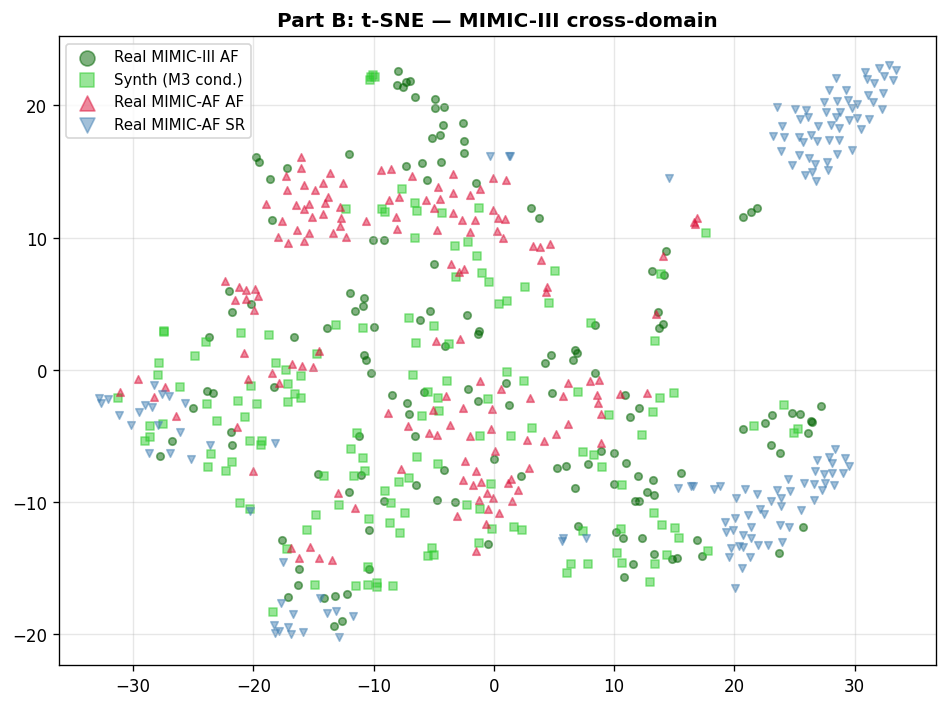


Fidelity summary (MIMIC-III cross-domain):
  LSD (0.5–8 Hz) : 6.60 dB  (in-domain: 7.07 dB)
  MMD²           : 0.02776  (domain gap: 0.07576  → 63.4% closed)
  DTW            : 3.304  (domain gap: 3.177)


In [88]:
# ── B5: t-SNE (4-way) ────────────────────────────────────────────────────────
if len(real_m3) >= 40:
    N_TT = min(150, len(feat_m3_real), len(feat_m3_synth),
               len(feats['real_AF']), len(feats['real_SR']))
    all_f_b = np.concatenate([
        feat_m3_real[:N_TT],  feat_m3_synth[:N_TT],
        feats['real_AF'][:N_TT], feats['real_SR'][:N_TT]])
    all_l_b = (['Real MIMIC-III AF']*N_TT + ['Synth (M3 cond.)']*N_TT +
               ['Real MIMIC-AF AF']*N_TT  + ['Real MIMIC-AF SR']*N_TT)
    sc_b = StandardScaler().fit(all_f_b)
    print('Computing t-SNE (Part B, 4-way)...')
    emb_b = TSNE(n_components=2,perplexity=30,random_state=SEED,n_iter=1000
                 ).fit_transform(sc_b.transform(all_f_b))
    style_b = {'Real MIMIC-III AF':('darkgreen','o'),
               'Synth (M3 cond.)':('limegreen','s'),
               'Real MIMIC-AF AF':('crimson','^'),
               'Real MIMIC-AF SR':('steelblue','v')}
    fig,ax=plt.subplots(figsize=(8,6))
    for lbl,(col,mrk) in style_b.items():
        msk=[l==lbl for l in all_l_b]
        ax.scatter(emb_b[msk,0],emb_b[msk,1],c=col,marker=mrk,
                   alpha=0.5,s=20,label=lbl)
    ax.set_title('Part B: t-SNE — MIMIC-III cross-domain',fontweight='bold')
    ax.legend(markerscale=2,fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'\nFidelity summary (MIMIC-III cross-domain):')
    print(f'  LSD (0.5–8 Hz) : {lsd_m3_band:.2f} dB  (in-domain: {(lsd_af_ref+lsd_sr_ref)/2:.2f} dB)')
    print(f'  MMD²           : {mmd_m3:.5f}  (domain gap: {mmd_gap:.5f}  → {100*(1-mmd_m3/mmd_gap):.1f}% closed)')
    print(f'  DTW            : {dtw_m3:.3f}  (domain gap: {dtw_gap:.3f})')


### Part B.2 — Classifier Evaluation (ClfUNetGAN, MIMIC-III-conditioned synthetics)

| Dataset | Training data | Rationale |
|---------|---------------|-----------|
| DB1 | 100% MIMIC-III-synth AF + 100% real MIMIC-AF SR | Pure cross-domain TSTR |
| DB2 | 50% MIMIC-III-synth AF + 50% real MIMIC-AF AF + 100% real MIMIC-AF SR | Hybrid |
| DBref | 100% real MIMIC-AF AF + 100% real MIMIC-AF SR | Baseline (same as FV2 D4) |

Two test sets:
1. **MIMIC-AF real test** (direct comparability with FV2)
2. **Cross-domain test**: real MIMIC-III AF + real MIMIC-AF SR test

In [89]:
# ── B6: Generate larger MIMIC-III synth pool for classifier ──────────────────
synth_pool_m3_clf = synth_m3   # use what we already generated

if len(synth_pool_m3_clf) < 50:
    print('Not enough MIMIC-III synthetics for classifier experiment.')
    _run_b2 = False
else:
    _run_b2 = True
    N_DB_UNIT = min(len(synth_pool_m3_clf),
                    int((y_tr==1).sum()), int((y_tr==0).sum()))
    print(f'Balancing unit N_DB_UNIT = {N_DB_UNIT}')

    rng_db = np.random.default_rng(SEED + 300)
    def samp(arr, n, rng):
        return arr[rng.choice(len(arr), min(n,len(arr)), replace=False)]

    real_af_tr = X_tr[y_tr==1]; real_sr_tr = X_tr[y_tr==0]

    # DB1: 100% MIMIC-III-synth AF + 100% real MIMIC-AF SR
    db1_X = np.vstack([samp(synth_pool_m3_clf,N_DB_UNIT,rng_db),
                       samp(real_sr_tr,N_DB_UNIT,rng_db)])
    db1_y = np.array([1]*N_DB_UNIT+[0]*N_DB_UNIT)
    # DB2: 50% M3-synth AF + 50% real MIMIC-AF AF + 100% real SR
    NHB = N_DB_UNIT//2
    db2_X = np.vstack([samp(synth_pool_m3_clf,NHB,rng_db),
                       samp(real_af_tr,NHB,rng_db),
                       samp(real_sr_tr,N_DB_UNIT,rng_db)])
    db2_y = np.array([1]*NHB+[1]*NHB+[0]*N_DB_UNIT)
    # DBref: 100% real MIMIC-AF AF + SR
    dbr_X = np.vstack([samp(real_af_tr,N_DB_UNIT,rng_db),
                       samp(real_sr_tr,N_DB_UNIT,rng_db)])
    dbr_y = np.array([1]*N_DB_UNIT+[0]*N_DB_UNIT)

    datasets_b = [
        ('DB1 — MIMIC-III-synth AF + MIMIC-AF SR (TSTR)', db1_X, db1_y),
        ('DB2 — MIMIC-III-synth AF + MIMIC-AF AF+SR (hybrid)', db2_X, db2_y),
        ('DBref — Real MIMIC-AF AF+SR (baseline)', dbr_X, dbr_y),
    ]
    print('Dataset sizes:')
    for n,X,y in datasets_b:
        print(f'  {n}: {len(X)} segs (AF={int((y==1).sum())} SR={int((y==0).sum())})')

    # ── Cross-domain test set: real MIMIC-III AF + real MIMIC-AF SR ─────────
    N_XD_B = min(len(real_m3), int((y_te==0).sum()))
    rng_xd_b = np.random.default_rng(SEED+301)
    idx_m3_xd = rng_xd_b.choice(len(real_m3), N_XD_B, replace=False)
    idx_sr_xd = rng_xd_b.choice(np.where(y_te==0)[0], N_XD_B, replace=False)
    X_xdom_b = np.vstack([real_m3[idx_m3_xd], X_te[idx_sr_xd]])
    y_xdom_b = np.array([1]*N_XD_B+[0]*N_XD_B)
    print(f'\nCross-domain test set (MIMIC-III AF + MIMIC-AF SR): '
          f'{len(X_xdom_b)} segs ({N_XD_B} per class)')


Balancing unit N_DB_UNIT = 989
Dataset sizes:
  DB1 — MIMIC-III-synth AF + MIMIC-AF SR (TSTR): 1978 segs (AF=989 SR=989)
  DB2 — MIMIC-III-synth AF + MIMIC-AF AF+SR (hybrid): 1977 segs (AF=988 SR=989)
  DBref — Real MIMIC-AF AF+SR (baseline): 1978 segs (AF=989 SR=989)

Cross-domain test set (MIMIC-III AF + MIMIC-AF SR): 1152 segs (576 per class)


In [90]:
# ── Garantir que ClfUNetGAN e helpers estão definidos (necessário se FV2 não correu) ─
from sklearn.metrics import (roc_auc_score, precision_score, f1_score,
                              recall_score, accuracy_score, confusion_matrix)

class ClfUNetGAN(nn.Module):
    def __init__(self):
        super().__init__()
        filters = [1, 4, 8, 16, 32, 64, 128]; layers = []
        for i in range(len(filters) - 1):
            layers += [nn.Conv1d(filters[i], filters[i+1], kernel_size=3, padding=1),
                       nn.LeakyReLU(0.15)]
        layers += [nn.AdaptiveAvgPool1d(1), nn.Flatten()]
        self.features    = nn.Sequential(*layers)
        self.classifier  = nn.Linear(128, 2)
    def forward(self, x): return self.classifier(self.features(x))


def find_best_threshold(y_true, probs):
    ths = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y_true, (probs > t).astype(int), zero_division=0) for t in ths]
    return float(ths[np.argmax(f1s)]), float(np.max(f1s))


def train_clf_ug(Xtr, ytr, Xvl, yvl, epochs=30, lr=1e-3, batch=128):
    clf = ClfUNetGAN().to(DEVICE)
    opt = torch.optim.Adam(clf.parameters(), lr=lr)
    Xt  = torch.tensor(Xtr[:, None, :], dtype=torch.float32)
    yt  = torch.tensor(ytr, dtype=torch.long)
    Xv  = torch.tensor(Xvl[:, None, :], dtype=torch.float32)
    dl  = torch.utils.data.DataLoader(list(zip(Xt, yt)), batch_size=batch, shuffle=True)
    best_auc, best_st = 0., None
    for ep in range(epochs):
        clf.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); nn.CrossEntropyLoss()(clf(xb), yb).backward(); opt.step()
        clf.eval()
        with torch.no_grad():
            pr = torch.softmax(clf(Xv.to(DEVICE)), dim=1).cpu().numpy()[:, 1]
        auc = roc_auc_score(yvl, pr)
        if auc > best_auc:
            best_auc = auc
            best_st  = {k: v.clone() for k, v in clf.state_dict().items()}
    clf.load_state_dict(best_st); clf.eval()
    with torch.no_grad():
        pr_v = torch.softmax(clf(Xv.to(DEVICE)), dim=1).cpu().numpy()[:, 1]
    thr, _ = find_best_threshold(yvl, pr_v)
    return clf, thr


def eval_clf_ug(clf, Xte, yte, threshold=0.5):
    clf.eval()
    with torch.no_grad():
        pr = torch.softmax(clf(torch.tensor(
            Xte[:, None, :], dtype=torch.float32).to(DEVICE)), dim=1).cpu().numpy()[:, 1]
    preds = (pr > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte, preds).ravel()
    return {'auroc':      roc_auc_score(yte, pr),
            'f1':         f1_score(yte, preds, zero_division=0),
            'precision':  precision_score(yte, preds, zero_division=0),
            'recall':     tp / (tp + fn) if (tp + fn) > 0 else 0.,
            'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.}

print('ClfUNetGAN, train_clf_ug, eval_clf_ug definidos.')

ClfUNetGAN, train_clf_ug, eval_clf_ug definidos.


In [91]:
# ── B7: Run ClfUNetGAN on Part B datasets ────────────────────────────────────
if _run_b2:
    N_SEEDS_B = 5
    res_b_mimic, res_b_xdom = {}, {}
    print(f'Training ClfUNetGAN ({N_SEEDS_B} seeds, 2 test sets)...')
    print('='*70)
    for ds_name, Xtr_d, ytr_d in datasets_b:
        print(f'\n{ds_name}')
        ml_m,ml_x = {k:[] for k in ['auroc','f1','precision','recall','specificity']},\
                    {k:[] for k in ['auroc','f1','precision','recall','specificity']}
        for s in range(N_SEEDS_B):
            torch.manual_seed(s); np.random.seed(s)
            clf, thr = train_clf_ug(Xtr_d, ytr_d, X_vl, y_vl)
            # Test 1: MIMIC-AF real
            clf.eval()
            with torch.no_grad():
                pr=torch.softmax(clf(torch.tensor(
                    X_te[:,None,:],dtype=torch.float32).to(DEVICE)),
                    dim=1).cpu().numpy()[:,1]
            preds=(pr>thr).astype(int)
            from sklearn.metrics import confusion_matrix as _cm
            tn,fp,fn,tp=_cm(y_te,preds).ravel()
            for k,v in [('auroc',roc_auc_score(y_te,pr)),
                         ('f1',f1_score(y_te,preds,zero_division=0)),
                         ('precision',precision_score(y_te,preds,zero_division=0)),
                         ('recall',tp/(tp+fn) if tp+fn>0 else 0.),
                         ('specificity',tn/(tn+fp) if tn+fp>0 else 0.)]:
                ml_m[k].append(v)
            # Test 2: cross-domain
            with torch.no_grad():
                pr2=torch.softmax(clf(torch.tensor(
                    X_xdom_b[:,None,:],dtype=torch.float32).to(DEVICE)),
                    dim=1).cpu().numpy()[:,1]
            preds2=(pr2>thr).astype(int)
            tn2,fp2,fn2,tp2=_cm(y_xdom_b,preds2).ravel()
            for k,v in [('auroc',roc_auc_score(y_xdom_b,pr2)),
                         ('f1',f1_score(y_xdom_b,preds2,zero_division=0)),
                         ('precision',precision_score(y_xdom_b,preds2,zero_division=0)),
                         ('recall',tp2/(tp2+fn2) if tp2+fn2>0 else 0.),
                         ('specificity',tn2/(tn2+fp2) if tn2+fp2>0 else 0.)]:
                ml_x[k].append(v)
            print(f'  seed {s}  [MIMIC-AF] AUROC={ml_m["auroc"][-1]:.4f}  '
                  f'F1={ml_m["f1"][-1]:.4f}  '
                  f'[XDom] AUROC={ml_x["auroc"][-1]:.4f}  '
                  f'F1={ml_x["f1"][-1]:.4f}  thr={thr:.2f}')
        res_b_mimic[ds_name]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_m.items()}
        res_b_xdom[ds_name] ={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_x.items()}

    for tname,rdict in [('[MIMIC-AF real test]',res_b_mimic),
                         ('[Cross-domain: M3 AF + MIMIC-AF SR]',res_b_xdom)]:
        print(f'\n{"="*100}')
        print(f'  Part B — ClfUNetGAN  {tname}')
        print(f'{"="*100}')
        print(f"  {'Dataset':<46}  {'AUROC':>13}  {'Prec':>10}  "
              f"{'Recall':>10}  {'Spec':>10}  {'F1':>10}")
        print('  '+'─'*95)
        for ds_name,m in rdict.items():
            print(f"  {ds_name:<46}  "
                  f"{m['auroc'][0]:.4f}\u00b1{m['auroc'][1]:.3f}  "
                  f"{m['precision'][0]:.4f}\u00b1{m['precision'][1]:.3f}  "
                  f"{m['recall'][0]:.4f}\u00b1{m['recall'][1]:.3f}  "
                  f"{m['specificity'][0]:.4f}\u00b1{m['specificity'][1]:.3f}  "
                  f"{m['f1'][0]:.4f}\u00b1{m['f1'][1]:.3f}")


Training ClfUNetGAN (5 seeds, 2 test sets)...

DB1 — MIMIC-III-synth AF + MIMIC-AF SR (TSTR)
  seed 0  [MIMIC-AF] AUROC=0.6152  F1=0.7333  [XDom] AUROC=0.6464  F1=0.7219  thr=0.16
  seed 1  [MIMIC-AF] AUROC=0.5200  F1=0.6374  [XDom] AUROC=0.6246  F1=0.6868  thr=0.47
  seed 2  [MIMIC-AF] AUROC=0.6380  F1=0.7545  [XDom] AUROC=0.6575  F1=0.7264  thr=0.15
  seed 3  [MIMIC-AF] AUROC=0.6456  F1=0.7573  [XDom] AUROC=0.6598  F1=0.7241  thr=0.22
  seed 4  [MIMIC-AF] AUROC=0.6419  F1=0.7495  [XDom] AUROC=0.6580  F1=0.7194  thr=0.28

DB2 — MIMIC-III-synth AF + MIMIC-AF AF+SR (hybrid)
  seed 0  [MIMIC-AF] AUROC=0.6428  F1=0.7588  [XDom] AUROC=0.6563  F1=0.7325  thr=0.20
  seed 1  [MIMIC-AF] AUROC=0.5110  F1=0.6130  [XDom] AUROC=0.6206  F1=0.6841  thr=0.50
  seed 2  [MIMIC-AF] AUROC=0.6495  F1=0.7603  [XDom] AUROC=0.6616  F1=0.7362  thr=0.19
  seed 3  [MIMIC-AF] AUROC=0.6463  F1=0.7384  [XDom] AUROC=0.6609  F1=0.7106  thr=0.24
  seed 4  [MIMIC-AF] AUROC=0.6486  F1=0.7603  [XDom] AUROC=0.6601  F1=0.

---
## Part C — Cross-Domain: ZenodoV2

Uses the MIMIC-AF trained model to generate synthetic AF PPG conditioned on
IBI features from the ZenodoV2 dataset (wrist PPG, 100 Hz → 125 Hz, HDF5 format).

**Prerequisites:**
- `ibi_session_zenodov2.csv` from the ZenodoV2 CFM notebook  
  (columns: `IBI_mean`, `IBI_std`, `RMSSD`, `event_rhythm`, `subject_id`, + path info)
- Pre-extracted PPG arrays saved as `ppg_zenodov2.npy` (shape: N×1250, float32)  
  and matching `ppg_zenodov2_labels.npy` (0=SR, 1=AF)

> **Note on ZenodoV2 PPG loading:** The HDF5 object-reference format is complex.
> Save PPG arrays from your ZenodoV2 notebook with:
> `np.save('/kaggle/working/ppg_zenodov2.npy', ppg_array)` (N×1250, already normalised)
> `np.save('/kaggle/working/ppg_zenodov2_labels.npy', labels)` (0/1)

**Part C.1** Fidelity: LSD · Wasserstein · MMD · DTW · t-SNE  
**Part C.2** Classifier: ClfUNetGAN with DC1/DC2/DCref on two test sets

In [101]:
# ── C1: Extracção ZenodoV2 AF — PPG + IBI features ───────────────────────────
# Adapta o pipeline do notebook ZenodoV2 directamente aqui.
# Na primeira execução demora ~30–60 min e guarda cache em WORK_DIR.
# Execuções seguintes carregam a cache em segundos.

import h5py
from pathlib import Path as _Path
from scipy.signal import resample_poly as _resample_poly

ZENODO_DATA_DIR  = _Path('/kaggle/input/datasets/vegatronxz/zenodo-v2/zenodo_v2')
ZENODO_IBI_CACHE = _Path(WORK_DIR) / 'zenodo_af_ibi_for_mimic_af.csv'
ZENODO_NPZ_CACHE = _Path(WORK_DIR) / 'zenodo_af_ppg_for_mimic_af.npz'

_ZENODO_CAT_A  = [1,2,4,6,8,11,12,17,18,19,20,21,23,27,32,34,37,41,43,44,45]
_ZENODO_ECG_FS = 500
_ZENODO_PPG_FS = 100
_ZENODO_WIN_RAW = WIN_SEC * _ZENODO_PPG_FS   # 1000 samples @ 100 Hz
_ZENODO_EXCL   = {28, 29, 42}

def _decode_z(arr):
    try:
        return ''.join(chr(int(c)) for c in np.array(arr).flatten()
                       if int(c) != 0).strip()
    except: return ''

def _ts_to_s(day_str, time_str):
    try:
        day   = int(day_str.strip()) if day_str.strip().isdigit() else 1
        parts = time_str.strip().split(':')
        h, m, s = int(parts[0]), int(parts[1]), int(parts[2])
        return (day - 1)*86400 + h*3600 + m*60 + s
    except: return None

def _load_zen_ecg(sid):
    fpath = ZENODO_DATA_DIR / f'{sid:03d}_ECG.mat'
    with h5py.File(fpath, 'r') as f:
        qrs = np.array(f['QRSindex']).squeeze().astype(int)
        af  = np.array(f['AF_annotation']).squeeze().astype(int)
        rr  = np.array(f['rr']).squeeze().astype(np.float64)
        t0  = _ts_to_s(_decode_z(f['recording_startday']),
                        _decode_z(f['recording_starttime']))
    return dict(qrs=qrs[:len(af)], af=af, rr=rr, t0_sec=t0)

def _load_zen_ppg_segs(sid):
    fpath = ZENODO_DATA_DIR / f'{sid:03d}_PPG.mat'
    segs  = []
    with h5py.File(fpath, 'r') as f:
        ppg_refs  = f['PPG_GREEN']
        day_refs  = f['recording_startday']
        time_refs = f['recording_starttime']
        for i in range(ppg_refs.shape[0]):
            sig      = np.array(f[ppg_refs[i, 0]]).squeeze().astype(np.float32)
            day_str  = _decode_z(f[day_refs[i, 0]])
            time_str = _decode_z(f[time_refs[i, 0]])
            t0       = _ts_to_s(day_str, time_str)
            if t0 is not None:
                segs.append(dict(sig=sig, t0_sec=t0))
    return segs

_b4z, _a4z = butter(4, [0.5/(_ZENODO_PPG_FS/2), 8./(_ZENODO_PPG_FS/2)], btype='band')

def _preproc_zen_ppg(win_raw):
    if not np.all(np.isfinite(win_raw)) or np.all(win_raw == win_raw[0]):
        return None
    filt = filtfilt(_b4z, _a4z, win_raw.astype(float))
    if np.std(filt) < 1e-4: return None
    sig125 = _resample_poly(filt, FS, _ZENODO_PPG_FS)[:WIN_LEN]
    if len(sig125) < WIN_LEN: return None
    mn, mx = sig125.min(), sig125.max()
    if mx - mn < 1e-8: return None
    return (2*(sig125 - mn)/(mx - mn) - 1).astype(np.float32)

def _zen_ecg_features(rr_window):
    rr = rr_window[(rr_window >= IBI_MIN) & (rr_window <= IBI_MAX)]
    if len(rr) < 2: return None, None, None
    ibi_m = float(np.mean(rr))
    if not (30 < 60./ibi_m < 200): return None, None, None
    ibi_s  = float(np.std(rr))
    rmssd  = float(np.sqrt(np.mean(np.diff(rr)**2))) if len(rr) >= 3 else 0.05
    return ibi_m, ibi_s, rmssd

# ── Invalidar cache corrompida (0 janelas) ────────────────────────────────────
if ZENODO_NPZ_CACHE.exists():
    _peek = np.load(ZENODO_NPZ_CACHE)
    if _peek['signals'].shape[0] == 0:
        print('Cache vazia (run anterior falhou) — a reconstruir.')
        ZENODO_NPZ_CACHE.unlink()
        ZENODO_IBI_CACHE.unlink(missing_ok=True)

# ── Carregar cache ou extrair ─────────────────────────────────────────────────
if ZENODO_NPZ_CACHE.exists() and ZENODO_IBI_CACHE.exists():
    print('A carregar cache ZenodoV2 AF...')
    _dz          = np.load(ZENODO_NPZ_CACHE)
    ppg_zen_real = _dz['signals']
    meta_zen     = pd.read_csv(ZENODO_IBI_CACHE)
    print(f'  PPG windows  : {ppg_zen_real.shape}')
    print(f'  IBI metadata : {len(meta_zen)} linhas')
else:
    print('A extrair ZenodoV2 AF (primeira vez — ~30–60 min)...')
    rows_z, sigs_z = [], []
    CAP_ZEN = 600

    for sid in sorted(_ZENODO_CAT_A):
        if sid in _ZENODO_EXCL: continue
        try:
            ecg_d = _load_zen_ecg(sid)
            segs  = _load_zen_ppg_segs(sid)
        except Exception as e:
            print(f'  S{sid:03d}: erro ao carregar — {e}'); continue
        if ecg_d['t0_sec'] is None:
            print(f'  S{sid:03d}: timestamp ECG inválido — skip'); continue

        qrs_t_abs = ecg_d['qrs'] / _ZENODO_ECG_FS + ecg_d['t0_sec']
        af_wins   = []

        for seg in segs:
            if len(af_wins) >= CAP_ZEN: break
            sig = seg['sig'].astype(float); t0 = seg['t0_sec']
            for wi in range(len(sig) // _ZENODO_WIN_RAW):
                if len(af_wins) >= CAP_ZEN: break
                s0 = wi * _ZENODO_WIN_RAW
                t_start = t0 + s0 / _ZENODO_PPG_FS
                t_end   = t_start + WIN_SEC
                beat_m  = (qrs_t_abs >= t_start) & (qrs_t_abs < t_end)
                beat_i  = np.where(beat_m)[0]
                if len(beat_i) < 4: continue
                if ecg_d['af'][beat_i].mean() <= 0.5: continue
                im, is_, irm = _zen_ecg_features(ecg_d['rr'][beat_i])
                if im is None: continue
                ppg = _preproc_zen_ppg(seg['sig'][s0:s0 + _ZENODO_WIN_RAW])
                if ppg is None: continue
                af_wins.append((ppg, im, is_, irm))

        for ppg, im, is_, irm in af_wins:
            sigs_z.append(ppg)
            rows_z.append({'subject_id':sid,'ibi_mean':im,'ibi_std':is_,'rmssd':irm})
        print(f'  S{sid:03d}: {len(af_wins)} janelas AF')

    ppg_zen_real = (np.array(sigs_z, dtype=np.float32) if sigs_z
                    else np.zeros((0,WIN_LEN), dtype=np.float32))
    meta_zen     = (pd.DataFrame(rows_z) if rows_z
                    else pd.DataFrame(columns=['subject_id','ibi_mean','ibi_std','rmssd']))
    np.savez_compressed(ZENODO_NPZ_CACHE, signals=ppg_zen_real)
    meta_zen.to_csv(ZENODO_IBI_CACHE, index=False)
    print(f'Cache guardada: {ppg_zen_real.shape[0]} janelas → {ZENODO_NPZ_CACHE}')

# ── Adaptar para o formato esperado pelas células C2–C4 ──────────────────────
# real_zen: array PPG real ZenodoV2 AF (N, 1250)
# df_zen:   DataFrame com IBI features no formato que norm_ibi() espera
real_zen = ppg_zen_real

df_zen = meta_zen.rename(columns={
    'ibi_mean': 'IBI_mean',
    'ibi_std':  'IBI_std',
    'rmssd':    'RMSSD',
}).copy()
df_zen['event_rhythm'] = 'AF'   # toda a extracção acima é AF

N_C_MAX  = 2000
N_C_EVAL = 200

print(f'\nZenodoV2 AF disponível: {real_zen.shape}')
if len(df_zen) > 0:
    print('IBI stats (segundos):')
    print(df_zen[['IBI_mean','IBI_std','RMSSD']].describe().round(4).to_string())

A carregar cache ZenodoV2 AF...
  PPG windows  : (11907, 1250)
  IBI metadata : 11907 linhas

ZenodoV2 AF disponível: (11907, 1250)
IBI stats (segundos):
         IBI_mean     IBI_std       RMSSD
count  11907.0000  11907.0000  11907.0000
mean       0.6529      0.1529      0.2171
std        0.1836      0.0633      0.0954
min        0.3498      0.0222      0.0375
25%        0.5107      0.1098      0.1520
50%        0.6193      0.1418      0.1992
75%        0.7600      0.1835      0.2627
max        1.9520      0.6458      1.0406


In [102]:
# ── C2: Generate synthetics from ZenodoV2 conditioning ───────────────────────
synth_zen = np.zeros((0,WIN_LEN),dtype=np.float32)
cond_zen_used = None

if len(df_zen) > 0 and len(real_zen) > 0:
    df_zen_af = df_zen[df_zen.event_rhythm=='AF'].sample(
        min(N_C_MAX, len(df_zen[df_zen.event_rhythm=='AF'])),
        random_state=SEED).reset_index(drop=True)
    nm_z,ns_z,nr_z = norm_ibi(df_zen_af.IBI_mean.values,
                               df_zen_af.IBI_std.values,
                               df_zen_af.RMSSD.values)
    cond_zen_used = df_zen_af
    cond_t_z = torch.tensor(build_cond(nm_z,ns_z,nr_z,'AF'),
                             dtype=torch.float32).to(DEVICE)
    print(f'Generating {len(cond_t_z)} ZenodoV2-conditioned synthetics...')
    chunks=[]
    for i in range(0,len(cond_t_z),64):
        chunks.append(
            heun_sample(ema_model,cond_t_z[i:i+64],ODE_STEPS,BEST_GS)
            .cpu().numpy().squeeze(1))
    synth_zen=np.concatenate(chunks).astype(np.float32)
    print(f'Generated: {synth_zen.shape}')
    print(f'ZenodoV2 IBI stats:')
    print(f'  IBI_mean: {df_zen_af.IBI_mean.mean():.4f}  '
          f'IBI_std: {df_zen_af.IBI_std.mean():.4f}  '
          f'RMSSD: {df_zen_af.RMSSD.mean():.4f}')
else:
    print('ZenodoV2 data not available — Part C skipped.')


Generating 2000 ZenodoV2-conditioned synthetics...
Generated: (2000, 1250)
ZenodoV2 IBI stats:
  IBI_mean: 0.6427  IBI_std: 0.1505  RMSSD: 0.2140


LSD (0.5–8 Hz): 7.35 dB  (MIMIC-AF in-domain: 7.07 dB)

Wasserstein — ZenodoV2 real vs MIMIC-AF-generated:
  HR_mean          Zen=7.3088  MIMIC-AF=8.5561  ratio=0.85x
  HR_std           Zen=9.4068  MIMIC-AF=2.5988  ratio=3.62x
  Power_0-4Hz      Zen=0.0293  MIMIC-AF=0.0343  ratio=0.85x
  Power_4-8Hz      Zen=0.0016  MIMIC-AF=0.0015  ratio=1.08x
  RMS              Zen=0.0584  MIMIC-AF=0.0340  ratio=1.72x

MMD²:
  ZenodoV2 real vs Synth (Zen cond.)    : 0.10943
  MIMIC-AF real vs Synth (MIMIC-AF cond.): 0.04637
  ZenodoV2 real vs MIMIC-AF real         : 0.27913  [domain gap]
  Gap closed: 60.8%

DTW  Zen=3.547  gap=3.577
Computing t-SNE (Part C)...


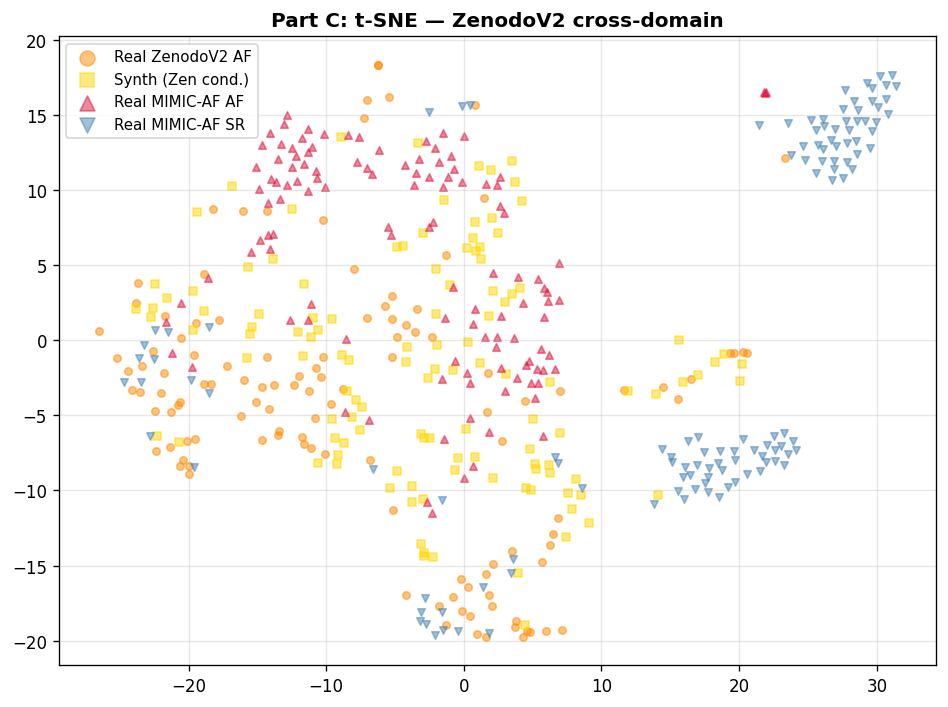

In [103]:
# ── C3: Fidelity — LSD · Wasserstein · MMD · DTW + t-SNE ────────────────────
if len(real_zen) >= 20 and len(synth_zen) >= 20:
    N_FID_C = min(N_C_EVAL, len(real_zen), len(synth_zen))
    rng_fc = np.random.default_rng(SEED+10)
    real_c_ev  = real_zen[rng_fc.choice(len(real_zen),  N_FID_C, replace=False)]
    synth_c_ev = synth_zen[rng_fc.choice(len(synth_zen),N_FID_C, replace=False)]

    lsd_zen_band = lsd(real_c_ev,synth_c_ev,band=(0.5,8.0))
    print(f'LSD (0.5–8 Hz): {lsd_zen_band:.2f} dB  (MIMIC-AF in-domain: {(lsd_af_ref+lsd_sr_ref)/2:.2f} dB)')

    feat_zen_real  = feature_vec(real_c_ev)
    feat_zen_synth = feature_vec(synth_c_ev)

    print('\nWasserstein — ZenodoV2 real vs MIMIC-AF-generated:')
    for i,fn in enumerate(['HR_mean','HR_std','Power_0-4Hz','Power_4-8Hz','RMS']):
        wz = wasserstein_distance(feat_zen_real[:,i], feat_zen_synth[:,i])
        waf= wasserstein_distance(feats['real_AF'][:,i],feats['synth_AF'][:,i])
        print(f'  {fn:<15}  Zen={wz:.4f}  MIMIC-AF={waf:.4f}  ratio={wz/(waf+1e-8):.2f}x')

    mmd_zen  = rbf_mmd2(feat_zen_real,  feat_zen_synth)
    mmd_gapz = rbf_mmd2(feat_zen_real,  feats['real_AF'])
    mmd_refz = rbf_mmd2(feats['real_AF'],feats['synth_AF'])
    print(f'\nMMD²:')
    print(f'  ZenodoV2 real vs Synth (Zen cond.)    : {mmd_zen:.5f}')
    print(f'  MIMIC-AF real vs Synth (MIMIC-AF cond.): {mmd_refz:.5f}')
    print(f'  ZenodoV2 real vs MIMIC-AF real         : {mmd_gapz:.5f}  [domain gap]')
    if mmd_gapz > 1e-6:
        print(f'  Gap closed: {100*(1-mmd_zen/mmd_gapz):.1f}%')

    dtw_zen_fid,dtw_zen_cov = dtw_nn_summary(real_c_ev, synth_c_ev)
    dtw_gapz_fid,dtw_gapz_cov = dtw_nn_summary(real_c_ev, eval_real['AF'])
    print(f'\nDTW  Zen fid={dtw_zen_fid:.3f} cov={dtw_zen_cov:.3f}   gap fid={dtw_gapz_fid:.3f} cov={dtw_gapz_cov:.3f}')

    # t-SNE
    N_TT_C = min(120,len(feat_zen_real),len(feat_zen_synth),
                 len(feats['real_AF']),len(feats['real_SR']))
    all_f_c = np.concatenate([feat_zen_real[:N_TT_C],feat_zen_synth[:N_TT_C],
                               feats['real_AF'][:N_TT_C],feats['real_SR'][:N_TT_C]])
    all_l_c = (['Real ZenodoV2 AF']*N_TT_C+['Synth (Zen cond.)']*N_TT_C+
               ['Real MIMIC-AF AF']*N_TT_C+['Real MIMIC-AF SR']*N_TT_C)
    sc_c = StandardScaler().fit(all_f_c)
    print('Computing t-SNE (Part C)...')
    emb_c = TSNE(n_components=2,perplexity=30,random_state=SEED,n_iter=1000
                 ).fit_transform(sc_c.transform(all_f_c))
    style_c={'Real ZenodoV2 AF':('darkorange','o'),'Synth (Zen cond.)':('gold','s'),
             'Real MIMIC-AF AF':('crimson','^'),'Real MIMIC-AF SR':('steelblue','v')}
    fig,ax=plt.subplots(figsize=(8,6))
    for lbl,(col,mrk) in style_c.items():
        msk=[l==lbl for l in all_l_c]
        ax.scatter(emb_c[msk,0],emb_c[msk,1],c=col,marker=mrk,alpha=0.5,s=20,label=lbl)
    ax.set_title('Part C: t-SNE — ZenodoV2 cross-domain',fontweight='bold')
    ax.legend(markerscale=2,fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('Not enough ZenodoV2 data for C3.')


### Part C.2 — Classifier Evaluation (ClfUNetGAN, ZenodoV2-conditioned synthetics)

| Dataset | Training data |
|---------|---------------|
| DC1 | 100% ZenodoV2-synth AF + 100% real MIMIC-AF SR |
| DC2 | 50% ZenodoV2-synth AF + 50% real MIMIC-AF AF + 100% real MIMIC-AF SR |
| DCref | 100% real MIMIC-AF AF + 100% real MIMIC-AF SR |

In [104]:
# Certifique-se de ter importado no topo do notebook:
# from sklearn.metrics import roc_auc_score, f1_score, precision_score

# ── C4: ClfUNetGAN — ZenodoV2 conditioned synthetics ────────────────────────
if len(synth_zen) < 50:
    print('Not enough ZenodoV2 synthetics for classifier experiment.')
    _run_c2 = False
else:
    _run_c2 = True
    N_DC_UNIT = min(len(synth_zen), int((y_tr == 1).sum()), int((y_tr == 0).sum()))
    rng_dc = np.random.default_rng(SEED + 400)
    dc1_X = np.vstack([samp(synth_zen, N_DC_UNIT, rng_dc), samp(real_sr_tr, N_DC_UNIT, rng_dc)])
    dc1_y = np.array([1] * N_DC_UNIT + [0] * N_DC_UNIT)
    NHC = N_DC_UNIT // 2
    dc2_X = np.vstack([samp(synth_zen, NHC, rng_dc), samp(real_af_tr, NHC, rng_dc),
                         samp(real_sr_tr, N_DC_UNIT, rng_dc)])
    dc2_y = np.array([1] * NHC + [1] * NHC + [0] * N_DC_UNIT)
    dcr_X = np.vstack([samp(real_af_tr, N_DC_UNIT, rng_dc), samp(real_sr_tr, N_DC_UNIT, rng_dc)])
    dcr_y = np.array([1] * N_DC_UNIT + [0] * N_DC_UNIT)

    # Cross-domain test: real ZenodoV2 AF + real MIMIC-AF SR
    N_XD_C = min(len(real_zen), int((y_te == 0).sum()))
    rng_xdc = np.random.default_rng(SEED + 401)
    X_xdom_c = np.vstack([real_zen[rng_xdc.choice(len(real_zen), N_XD_C, replace=False)],
                           X_te[rng_xdc.choice(np.where(y_te == 0)[0], N_XD_C, replace=False)]])
    y_xdom_c = np.array([1] * N_XD_C + [0] * N_XD_C)

    datasets_c = [('DC1 — Zen-synth AF + MIMIC-AF SR (TSTR)', dc1_X, dc1_y),
                  ('DC2 — Zen-synth AF + MIMIC-AF AF+SR (hybrid)', dc2_X, dc2_y),
                  ('DCref — Real MIMIC-AF AF+SR (baseline)', dcr_X, dcr_y)]
    print('Dataset sizes:')
    for n, X, y in datasets_c:
        print(f'  {n}: {len(X)} segs')
    print(f'Cross-domain test set: {len(X_xdom_c)} segs ({N_XD_C} per class)')

    N_SEEDS_C = 5; res_c_mimic, res_c_xdom = {}, {}
    print(f'\nTraining ClfUNetGAN ({N_SEEDS_C} seeds)...')
    for ds_name, Xtr_d, ytr_d in datasets_c:
        print(f'\n{ds_name}')
        # Adicionada a chave 'precision' na inicialização
        ml_m, ml_x = {k: [] for k in ['auroc', 'precision', 'f1']}, {k: [] for k in ['auroc', 'precision', 'f1']}
        
        for s in range(N_SEEDS_C):
            torch.manual_seed(s); np.random.seed(s)
            clf, thr = train_clf_ug(Xtr_d, ytr_d, X_vl, y_vl)
            clf.eval()
            for ml, (Xte_, yte_) in [(ml_m, (X_te, y_te)), (ml_x, (X_xdom_c, y_xdom_c))]:
                with torch.no_grad():
                    pr = torch.softmax(clf(torch.tensor(
                        Xte_[:, None, :], dtype=torch.float32).to(DEVICE)),
                        dim=1).cpu().numpy()[:, 1]
                preds = (pr > thr).astype(int)
                
                # Cálculo das métricas
                ml['auroc'].append(roc_auc_score(yte_, pr))
                ml['precision'].append(precision_score(yte_, preds, zero_division=0))
                ml['f1'].append(f1_score(yte_, preds, zero_division=0))
                
            print(f'  seed {s}  [MIMIC-AF] AUROC={ml_m["auroc"][-1]:.4f}  Prec={ml_m["precision"][-1]:.4f}  F1={ml_m["f1"][-1]:.4f}  '
                  f'[XDom] AUROC={ml_x["auroc"][-1]:.4f}  Prec={ml_x["precision"][-1]:.4f}  F1={ml_x["f1"][-1]:.4f}')
            
        res_c_mimic[ds_name] = {k: (float(np.mean(v)), float(np.std(v))) for k, v in ml_m.items()}
        res_c_xdom[ds_name]  = {k: (float(np.mean(v)), float(np.std(v))) for k, v in ml_x.items()}

    # Imprimir tabelas com Precision incluída
    for tname, rdict in [('[MIMIC-AF real test]', res_c_mimic),
                         ('[Cross-domain: Zen AF + MIMIC-AF SR]', res_c_xdom)]:
        print(f'\n{"="*90}')
        print(f'  Part C — ClfUNetGAN  {tname}')
        print(f'{"="*90}')
        print(f"  {'Dataset':<44}  {'AUROC':>14}  {'Precision':>14}  {'F1':>12}")
        print('  ' + '─' * 88)
        for n, m in rdict.items():
            print(f"  {n:<44}  "
                  f"{m['auroc'][0]:.4f}\u00b1{m['auroc'][1]:.3f}  "
                  f"{m['precision'][0]:.4f}\u00b1{m['precision'][1]:.3f}  "
                  f"{m['f1'][0]:.4f}\u00b1{m['f1'][1]:.3f}")

Dataset sizes:
  DC1 — Zen-synth AF + MIMIC-AF SR (TSTR): 1978 segs
  DC2 — Zen-synth AF + MIMIC-AF AF+SR (hybrid): 1977 segs
  DCref — Real MIMIC-AF AF+SR (baseline): 1978 segs
Cross-domain test set: 1152 segs (576 per class)

Training ClfUNetGAN (5 seeds)...

DC1 — Zen-synth AF + MIMIC-AF SR (TSTR)
  seed 0  [MIMIC-AF] AUROC=0.6002  Prec=0.6421  F1=0.6931  [XDom] AUROC=0.7532  Prec=0.6457  F1=0.7547
  seed 1  [MIMIC-AF] AUROC=0.5151  Prec=0.5848  F1=0.6066  [XDom] AUROC=0.6311  Prec=0.5882  F1=0.6626
  seed 2  [MIMIC-AF] AUROC=0.6034  Prec=0.6470  F1=0.7094  [XDom] AUROC=0.7558  Prec=0.6436  F1=0.7568
  seed 3  [MIMIC-AF] AUROC=0.6140  Prec=0.6478  F1=0.7175  [XDom] AUROC=0.7626  Prec=0.6411  F1=0.7580
  seed 4  [MIMIC-AF] AUROC=0.6116  Prec=0.6464  F1=0.7126  [XDom] AUROC=0.7623  Prec=0.6417  F1=0.7573

DC2 — Zen-synth AF + MIMIC-AF AF+SR (hybrid)
  seed 0  [MIMIC-AF] AUROC=0.6162  Prec=0.6509  F1=0.7436  [XDom] AUROC=0.7646  Prec=0.6328  F1=0.7601
  seed 1  [MIMIC-AF] AUROC=0.5031 

---
## Part D — Data Scarcity Experiment

Tests the hypothesis: *synthetic data is most valuable when real labelled data is scarce.*

**Setup:** vary N = number of AF-positive subjects used for training (keeping all SR subjects).
At each N, compare:
- `TRTR_N`: classifier trained on N×AF real + all SR real
- `ClfB_N`: classifier trained on (N×AF real + N×AF synthetic) + all SR real

**Two classifiers:** ClfUNetGAN (from FV2 paper) and Clf1D (primary §11 classifier).  
**5 subject-sampling seeds** at each N to account for which subjects are selected.  
**Gap closed** = Δ AUROC / (TRTR_full − TRTR_N): fraction of performance gap recovered by synthetics.

> **MIMIC-AF specificity:** AF and SR subjects are disjoint, so selecting N AF subjects
> gives zero SR windows. Fix: always include all SR training windows regardless of N.

In [97]:
# ── D0: Setup — load_fold + references ──────────────────────────────────────
def load_fold(df_fold, max_per_class=None):
    """Load PPG from MIMIC-AF CSV format (used for data scarcity)."""
    signals, labels = [], []
    for rh, lbl in [('AF',1),('SR',0)]:
        sub = df_fold[df_fold.event_rhythm==rh]
        if max_per_class:
            sub = sub.sample(min(max_per_class,len(sub)),random_state=SEED)
        for _,row in sub.iterrows():
            sig = load_ppg(row['csv_path'],int(row['start_sample']))
            if sig is not None: signals.append(sig); labels.append(lbl)
    return np.array(signals), np.array(labels)


# ── Scarcity-specific variables ───────────────────────────────────────────────
_scar_af_subj = list(df_train[df_train.event_rhythm=='AF']['subject_id'].unique())
_scar_sr_df   = df_train[df_train.event_rhythm=='SR']   # all SR — always included
print(f'AF-positive train subjects: {len(_scar_af_subj)}')
print(f'SR train windows (always included): {len(_scar_sr_df):,}')

# ── Synthetic pool (re-use or generate) ──────────────────────────────────────
# Use eval_synth already in memory; generate a larger pool if needed
N_SCAR_POOL = 2000
_synth_pool_scar = {}
for rh in ['AF','SR']:
    df_cls=df_train[df_train.event_rhythm==rh].sample(
        min(N_SCAR_POOL,len(df_train[df_train.event_rhythm==rh])),random_state=SEED+50)
    nm,ns,nr=norm_ibi(df_cls.IBI_mean.values,df_cls.IBI_std.values,df_cls.RMSSD.values)
    ct=torch.tensor(build_cond(nm,ns,nr,rh),dtype=torch.float32).to(DEVICE)
    ch=[]
    for i in range(0,len(ct),64):
        ch.append(heun_sample(ema_model,ct[i:i+64],ODE_STEPS,BEST_GS)
                  .cpu().numpy().squeeze(1))
    _synth_pool_scar[rh]=np.concatenate(ch).astype(np.float32)
    print(f'  {rh}: {_synth_pool_scar[rh].shape[0]} windows in pool')

# ── Full-data TRTR reference (uncapped — consistent with scarcity methodology) ─
print('\nComputing full-data TRTR references (uncapped)...')
X_tr_full, y_tr_full = load_fold(df_train, max_per_class=50_000)
print(f'  Full train: {X_tr_full.shape} '
      f'(AF={int((y_tr_full==1).sum())} SR={int((y_tr_full==0).sum())})')

_ref_auroc_ug, _ref_auroc_clf1d = [], []
for s in range(5):
    torch.manual_seed(s); np.random.seed(s)
    c1,t1=train_clf_ug(X_tr_full,y_tr_full,X_vl,y_vl)
    _ref_auroc_ug.append(eval_clf_ug(c1,X_te,y_te,threshold=t1)['auroc'])
    torch.manual_seed(s); np.random.seed(s)
    c2,t2=train_clf(X_tr_full,y_tr_full,X_vl,y_vl)
    _ref_auroc_clf1d.append(eval_clf(c2,X_te,y_te,threshold=t2)['auroc'])

REF_TRTR_UG    = float(np.mean(_ref_auroc_ug))
REF_TRTR_CLF1D = float(np.mean(_ref_auroc_clf1d))
print(f'  ClfUNetGAN TRTR (full, uncapped): {REF_TRTR_UG:.4f}±{np.std(_ref_auroc_ug):.4f}')
print(f'  Clf1D      TRTR (full, uncapped): {REF_TRTR_CLF1D:.4f}±{np.std(_ref_auroc_clf1d):.4f}')


AF-positive train subjects: 13
SR train windows (always included): 2,384
  AF: 2000 windows in pool
  SR: 2000 windows in pool

Computing full-data TRTR references (uncapped)...
  Full train: (5438, 1250) (AF=3064 SR=2374)
  ClfUNetGAN TRTR (full, uncapped): 0.6157±0.0385
  Clf1D      TRTR (full, uncapped): 0.5996±0.1220


In [98]:
# ── D1: Data Scarcity — ClfUNetGAN ───────────────────────────────────────────
N_VALUES_SCAR = [3, 5, 8, 12, 15]
N_SEEDS_SCAR  = 5

print(f'Data Scarcity — ClfUNetGAN  |  N: {N_VALUES_SCAR}  |  {N_SEEDS_SCAR} seeds')
print(f'Full-data ref TRTR={REF_TRTR_UG:.4f}  '
      f'[SR always included: {len(_scar_sr_df):,} windows]\n')

res_scar_ug = {}
for N in N_VALUES_SCAR:
    n_sel=min(N,len(_scar_af_subj)); auroc_tr,auroc_cb=[],[]
    print(f'── N={N} ──'+'─'*55)
    for seed in range(N_SEEDS_SCAR):
        rng_sc=np.random.default_rng(seed*1000+N)
        sel=rng_sc.choice(_scar_af_subj,n_sel,replace=False)
        df_af_sc=df_train[df_train.subject_id.isin(sel)&(df_train.event_rhythm=='AF')]
        df_sc=pd.concat([df_af_sc,_scar_sr_df])
        Xr,yr=load_fold(df_sc,max_per_class=50_000)
        n_af_r,n_sr_r=int((yr==1).sum()),int((yr==0).sum())
        if n_af_r<4 or n_sr_r<4:
            print(f'  seed {seed}: skip (AF={n_af_r} SR={n_sr_r})'); continue
        torch.manual_seed(seed); np.random.seed(seed)
        c_t,th=train_clf_ug(Xr,yr,X_vl,y_vl)
        mt=eval_clf_ug(c_t,X_te,y_te,threshold=th); auroc_tr.append(mt['auroc'])
        rng_b=np.random.default_rng(seed*1000+N+500)
        af_s=_synth_pool_scar['AF'][rng_b.choice(
            len(_synth_pool_scar['AF']),min(n_af_r,len(_synth_pool_scar['AF'])),replace=False)]
        sr_s=_synth_pool_scar['SR'][rng_b.choice(
            len(_synth_pool_scar['SR']),min(n_sr_r,len(_synth_pool_scar['SR'])),replace=False)]
        Xa=np.vstack([Xr[yr==1],af_s,Xr[yr==0],sr_s])
        ya=np.array([1]*(n_af_r+len(af_s))+[0]*(n_sr_r+len(sr_s)))
        torch.manual_seed(seed+9999); np.random.seed(seed+9999)
        c_b,thb=train_clf_ug(Xa,ya,X_vl,y_vl)
        mb=eval_clf_ug(c_b,X_te,y_te,threshold=thb); auroc_cb.append(mb['auroc'])
        print(f'  seed {seed}: real={len(Xr)} (AF={n_af_r} SR={n_sr_r})  '
              f'aug={len(Xa)}  TRTR={mt["auroc"]:.4f}  ClfB={mb["auroc"]:.4f}  '
              f'\u0394={mb["auroc"]-mt["auroc"]:+.4f}')
    if auroc_tr:
        res_scar_ug[N]={'TRTR':(float(np.mean(auroc_tr)),float(np.std(auroc_tr))),
                        'ClfB':(float(np.mean(auroc_cb)),float(np.std(auroc_cb)))}

print()
print('='*90)
print('  Data Scarcity — ClfUNetGAN  [SR always full, 5 seeds]')
print('='*90)
print(f"  {'N':>6}  {'TRTR_N':>20}  {'ClfB_N':>20}  {'\u0394 AUROC':>9}  {'Gap closed':>12}")
print('  '+'─'*70)
for N,r in sorted(res_scar_ug.items()):
    delta=r['ClfB'][0]-r['TRTR'][0]
    gap=REF_TRTR_UG-r['TRTR'][0]
    closed=delta/gap if gap>1e-4 else float('nan')
    print(f"  {N:>6}  {r['TRTR'][0]:.4f}\u00b1{r['TRTR'][1]:.4f}        "
          f"{r['ClfB'][0]:.4f}\u00b1{r['ClfB'][1]:.4f}        "
          f"{delta:>+9.4f}  {closed:>11.1%}")
print(f"  {'Full':>6}  {REF_TRTR_UG:.4f} (ClfUNetGAN ref., uncapped)")
print('='*90)
print('Gap closed = fraction of (TRTR_full \u2212 TRTR_N) recovered by adding synthetics.')


Data Scarcity — ClfUNetGAN  |  N: [3, 5, 8, 12, 15]  |  5 seeds
Full-data ref TRTR=0.6157  [SR always included: 2,384 windows]

── N=3 ─────────────────────────────────────────────────────────
  seed 0: real=3063 (AF=689 SR=2374)  aug=5752  TRTR=0.6262  ClfB=0.6194  Δ=-0.0068
  seed 1: real=3050 (AF=676 SR=2374)  aug=5726  TRTR=0.4817  ClfB=0.5143  Δ=+0.0326
  seed 2: real=3078 (AF=704 SR=2374)  aug=5782  TRTR=0.4924  ClfB=0.6097  Δ=+0.1172
  seed 3: real=3091 (AF=717 SR=2374)  aug=5808  TRTR=0.6249  ClfB=0.6151  Δ=-0.0098
  seed 4: real=3091 (AF=717 SR=2374)  aug=5808  TRTR=0.6187  ClfB=0.4533  Δ=-0.1654
── N=5 ─────────────────────────────────────────────────────────
  seed 0: real=3567 (AF=1193 SR=2374)  aug=6760  TRTR=0.6040  ClfB=0.6107  Δ=+0.0067
  seed 1: real=3554 (AF=1180 SR=2374)  aug=6734  TRTR=0.4823  ClfB=0.5734  Δ=+0.0911
  seed 2: real=3539 (AF=1165 SR=2374)  aug=6704  TRTR=0.6070  ClfB=0.6158  Δ=+0.0088
  seed 3: real=3569 (AF=1195 SR=2374)  aug=6764  TRTR=0.6181  ClfB=

In [99]:
# ── D2: Data Scarcity — Clf1D ────────────────────────────────────────────────
print(f'Data Scarcity — Clf1D  |  N: {N_VALUES_SCAR}  |  {N_SEEDS_SCAR} seeds')
print(f'Full-data ref TRTR={REF_TRTR_CLF1D:.4f}\n')

res_scar_clf1d = {}
for N in N_VALUES_SCAR:
    n_sel=min(N,len(_scar_af_subj)); auroc_tr,auroc_cb=[],[]
    print(f'── N={N} ──'+'─'*55)
    for seed in range(N_SEEDS_SCAR):
        rng_sc=np.random.default_rng(seed*1000+N)
        sel=rng_sc.choice(_scar_af_subj,n_sel,replace=False)
        df_af_sc=df_train[df_train.subject_id.isin(sel)&(df_train.event_rhythm=='AF')]
        df_sc=pd.concat([df_af_sc,_scar_sr_df])
        Xr,yr=load_fold(df_sc,max_per_class=50_000)
        n_af_r,n_sr_r=int((yr==1).sum()),int((yr==0).sum())
        if n_af_r<4 or n_sr_r<4:
            print(f'  seed {seed}: skip (AF={n_af_r} SR={n_sr_r})'); continue
        torch.manual_seed(seed); np.random.seed(seed)
        c_t,th=train_clf(Xr,yr,X_vl,y_vl)
        mt=eval_clf(c_t,X_te,y_te,threshold=th); auroc_tr.append(mt['auroc'])
        rng_b=np.random.default_rng(seed*1000+N+500)
        af_s=_synth_pool_scar['AF'][rng_b.choice(
            len(_synth_pool_scar['AF']),min(n_af_r,len(_synth_pool_scar['AF'])),replace=False)]
        sr_s=_synth_pool_scar['SR'][rng_b.choice(
            len(_synth_pool_scar['SR']),min(n_sr_r,len(_synth_pool_scar['SR'])),replace=False)]
        Xa=np.vstack([Xr[yr==1],af_s,Xr[yr==0],sr_s])
        ya=np.array([1]*(n_af_r+len(af_s))+[0]*(n_sr_r+len(sr_s)))
        torch.manual_seed(seed+9999); np.random.seed(seed+9999)
        c_b,thb=train_clf(Xa,ya,X_vl,y_vl)
        mb=eval_clf(c_b,X_te,y_te,threshold=thb); auroc_cb.append(mb['auroc'])
        print(f'  seed {seed}: real={len(Xr)} (AF={n_af_r} SR={n_sr_r})  '
              f'TRTR={mt["auroc"]:.4f}  ClfB={mb["auroc"]:.4f}  '
              f'\u0394={mb["auroc"]-mt["auroc"]:+.4f}')
    if auroc_tr:
        res_scar_clf1d[N]={'TRTR':(float(np.mean(auroc_tr)),float(np.std(auroc_tr))),
                           'ClfB':(float(np.mean(auroc_cb)),float(np.std(auroc_cb)))}

print()
print('='*90)
print('  Data Scarcity — Clf1D  [SR always full, 5 seeds]')
print('='*90)
print(f"  {'N':>6}  {'TRTR_N':>20}  {'ClfB_N':>20}  {'\u0394 AUROC':>9}  {'Gap closed':>12}")
print('  '+'─'*70)
for N,r in sorted(res_scar_clf1d.items()):
    delta=r['ClfB'][0]-r['TRTR'][0]
    gap=REF_TRTR_CLF1D-r['TRTR'][0]
    closed=delta/gap if gap>1e-4 else float('nan')
    print(f"  {N:>6}  {r['TRTR'][0]:.4f}\u00b1{r['TRTR'][1]:.4f}        "
          f"{r['ClfB'][0]:.4f}\u00b1{r['ClfB'][1]:.4f}        "
          f"{delta:>+9.4f}  {closed:>11.1%}")
print(f"  {'Full':>6}  {REF_TRTR_CLF1D:.4f} (Clf1D ref., uncapped)")
print('='*90)

# ── Joint summary across classifiers ─────────────────────────────────────────
print('\n── Joint Summary: ClfB improvement by N ──────────────────────────────')
print(f"  {'N':>6}  {'ClfUNetGAN \u0394':>16}  {'Clf1D \u0394':>14}")
print('  '+'─'*40)
for N in N_VALUES_SCAR:
    d_ug  = res_scar_ug.get(N,{}).get('ClfB',(float('nan'),0))[0] - \
            res_scar_ug.get(N,{}).get('TRTR',(float('nan'),0))[0]
    d_c   = res_scar_clf1d.get(N,{}).get('ClfB',(float('nan'),0))[0] - \
            res_scar_clf1d.get(N,{}).get('TRTR',(float('nan'),0))[0]
    print(f"  {N:>6}  {d_ug:>+16.4f}  {d_c:>+14.4f}")
print('\n\u0394 > 0 \u2192 synthetic augmentation improves at this N.')


Data Scarcity — Clf1D  |  N: [3, 5, 8, 12, 15]  |  5 seeds
Full-data ref TRTR=0.5996

── N=3 ─────────────────────────────────────────────────────────
  seed 0: real=3063 (AF=689 SR=2374)  TRTR=0.7026  ClfB=0.2390  Δ=-0.4637
  seed 1: real=3050 (AF=676 SR=2374)  TRTR=0.5875  ClfB=0.3656  Δ=-0.2219
  seed 2: real=3078 (AF=704 SR=2374)  TRTR=0.3690  ClfB=0.3464  Δ=-0.0226
  seed 3: real=3091 (AF=717 SR=2374)  TRTR=0.4914  ClfB=0.6490  Δ=+0.1575
  seed 4: real=3091 (AF=717 SR=2374)  TRTR=0.4705  ClfB=0.3931  Δ=-0.0774
── N=5 ─────────────────────────────────────────────────────────
  seed 0: real=3567 (AF=1193 SR=2374)  TRTR=0.6426  ClfB=0.7540  Δ=+0.1114
  seed 1: real=3554 (AF=1180 SR=2374)  TRTR=0.5374  ClfB=0.3370  Δ=-0.2004
  seed 2: real=3539 (AF=1165 SR=2374)  TRTR=0.5716  ClfB=0.3956  Δ=-0.1760
  seed 3: real=3569 (AF=1195 SR=2374)  TRTR=0.6215  ClfB=0.5528  Δ=-0.0687
  seed 4: real=3556 (AF=1182 SR=2374)  TRTR=0.3728  ClfB=0.3965  Δ=+0.0237
── N=8 ────────────────────────────────